# Estudo de Caso — Sistema de Vendas e Distribuição (Northwind)
###Cenário

A empresa Global Commerce Distribution atua na comercialização e distribuição de produtos para diversos clientes ao redor do mundo.
O sistema utiliza um banco de dados relacional para controlar:

* Clientes
* Funcionários
* Pedidos
* Produtos
* Categorias
* Fornecedores
* Transportadoras
* Regiões e territórios

A diretoria deseja gerar relatórios inteligentes e automatizar cálculos utilizando FUNCTIONS no MySQL.

## Estrutura do Banco de Dados

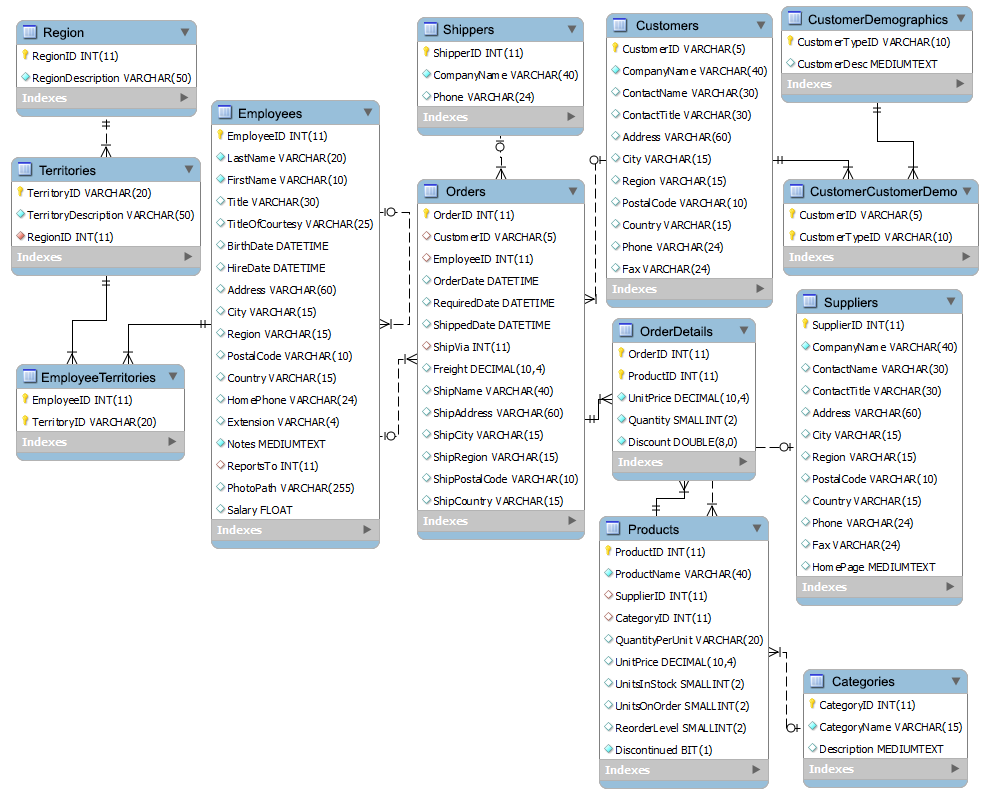

# Objetivos da Atividade


* Interpretar o DER
* Criar consultas SQL
* Desenvolver FUNCTIONS no MySQL
* Aplicar regras de negócio
* Trabalhar com cálculos e manipulação de dados
* Integrar múltiplas tabelas

# Script Banco de Dados

```sql
/*
** Copyright Microsoft, Inc. 1994 - 2000
** All Rights Reserved.
*/

-- This script does not create a database.
-- Run this script in the database you want the objects to be created.
-- Default schema is dbo.

SET NOCOUNT ON
GO

set quoted_identifier on
GO

/* Set DATEFORMAT so that the date strings are interpreted correctly regardless of
   the default DATEFORMAT on the server.
*/
SET DATEFORMAT mdy
GO

go
if exists (select * from sysobjects where id = object_id('dbo.Employee Sales by Country') and sysstat & 0xf = 4)
	drop procedure "dbo"."Employee Sales by Country"
GO
if exists (select * from sysobjects where id = object_id('dbo.Sales by Year') and sysstat & 0xf = 4)
	drop procedure "dbo"."Sales by Year"
GO
if exists (select * from sysobjects where id = object_id('dbo.Ten Most Expensive Products') and sysstat & 0xf = 4)
	drop procedure "dbo"."Ten Most Expensive Products"
GO
if exists (select * from sysobjects where id = object_id('dbo.CustOrderHist') and sysstat & 0xf = 4)
	drop procedure "dbo"."CustOrderHist"
GO
if exists (select * from sysobjects where id = object_id('dbo.CustOrdersDetail') and sysstat & 0xf = 4)
	drop procedure "dbo"."CustOrdersDetail"
GO
if exists (select * from sysobjects where id = object_id('dbo.CustOrdersOrders') and sysstat & 0xf = 4)
	drop procedure "dbo"."CustOrdersOrders"
GO
if exists (select * from sysobjects where id = object_id('dbo.SalesByCategory') and sysstat & 0xf = 4)
	drop procedure "dbo"."SalesByCategory"
GO
if exists (select * from sysobjects where id = object_id('dbo.Category Sales for 1997') and sysstat & 0xf = 2)
	drop view "dbo"."Category Sales for 1997"
GO
if exists (select * from sysobjects where id = object_id('dbo.Sales by Category') and sysstat & 0xf = 2)
	drop view "dbo"."Sales by Category"
GO
if exists (select * from sysobjects where id = object_id('dbo.Sales Totals by Amount') and sysstat & 0xf = 2)
	drop view "dbo"."Sales Totals by Amount"
GO
if exists (select * from sysobjects where id = object_id('dbo.Summary of Sales by Quarter') and sysstat & 0xf = 2)
	drop view "dbo"."Summary of Sales by Quarter"
GO
if exists (select * from sysobjects where id = object_id('dbo.Summary of Sales by Year') and sysstat & 0xf = 2)
	drop view "dbo"."Summary of Sales by Year"
GO
if exists (select * from sysobjects where id = object_id('dbo.Invoices') and sysstat & 0xf = 2)
	drop view "dbo"."Invoices"
GO
if exists (select * from sysobjects where id = object_id('dbo.Order Details Extended') and sysstat & 0xf = 2)
	drop view "dbo"."Order Details Extended"
GO
if exists (select * from sysobjects where id = object_id('dbo.Order Subtotals') and sysstat & 0xf = 2)
	drop view "dbo"."Order Subtotals"
GO
if exists (select * from sysobjects where id = object_id('dbo.Product Sales for 1997') and sysstat & 0xf = 2)
	drop view "dbo"."Product Sales for 1997"
GO
if exists (select * from sysobjects where id = object_id('dbo.Alphabetical list of products') and sysstat & 0xf = 2)
	drop view "dbo"."Alphabetical list of products"
GO
if exists (select * from sysobjects where id = object_id('dbo.Current Product List') and sysstat & 0xf = 2)
	drop view "dbo"."Current Product List"
GO
if exists (select * from sysobjects where id = object_id('dbo.Orders Qry') and sysstat & 0xf = 2)
	drop view "dbo"."Orders Qry"
GO
if exists (select * from sysobjects where id = object_id('dbo.Products Above Average Price') and sysstat & 0xf = 2)
	drop view "dbo"."Products Above Average Price"
GO
if exists (select * from sysobjects where id = object_id('dbo.Products by Category') and sysstat & 0xf = 2)
	drop view "dbo"."Products by Category"
GO
if exists (select * from sysobjects where id = object_id('dbo.Quarterly Orders') and sysstat & 0xf = 2)
	drop view "dbo"."Quarterly Orders"
GO
if exists (select * from sysobjects where id = object_id('dbo.Customer and Suppliers by City') and sysstat & 0xf = 2)
	drop view "dbo"."Customer and Suppliers by City"
GO
if exists (select * from sysobjects where id = object_id('dbo.Order Details') and sysstat & 0xf = 3)
	drop table "dbo"."Order Details"
GO
if exists (select * from sysobjects where id = object_id('dbo.Orders') and sysstat & 0xf = 3)
	drop table "dbo"."Orders"
GO
if exists (select * from sysobjects where id = object_id('dbo.Products') and sysstat & 0xf = 3)
	drop table "dbo"."Products"
GO
if exists (select * from sysobjects where id = object_id('dbo.Categories') and sysstat & 0xf = 3)
	drop table "dbo"."Categories"
GO
if exists (select * from sysobjects where id = object_id('dbo.CustomerCustomerDemo') and sysstat & 0xf = 3)
	drop table "dbo"."CustomerCustomerDemo"
GO
if exists (select * from sysobjects where id = object_id('dbo.CustomerDemographics') and sysstat & 0xf = 3)
	drop table "dbo"."CustomerDemographics"
GO
if exists (select * from sysobjects where id = object_id('dbo.Customers') and sysstat & 0xf = 3)
	drop table "dbo"."Customers"
GO
if exists (select * from sysobjects where id = object_id('dbo.Shippers') and sysstat & 0xf = 3)
	drop table "dbo"."Shippers"
GO
if exists (select * from sysobjects where id = object_id('dbo.Suppliers') and sysstat & 0xf = 3)
	drop table "dbo"."Suppliers"
GO
if exists (select * from sysobjects where id = object_id('dbo.EmployeeTerritories') and sysstat & 0xf = 3)
	drop table "dbo"."EmployeeTerritories"
GO
if exists (select * from sysobjects where id = object_id('dbo.Territories') and sysstat & 0xf = 3)
	drop table "dbo".Territories
GO
if exists (select * from sysobjects where id = object_id('dbo.Region') and sysstat & 0xf = 3)
	drop table "dbo".Region
GO
if exists (select * from sysobjects where id = object_id('dbo.Employees') and sysstat & 0xf = 3)
	drop table "dbo"."Employees"
GO

CREATE TABLE "Employees" (
	"EmployeeID" "int" IDENTITY (1, 1) NOT NULL ,
	"LastName" nvarchar (20) NOT NULL ,
	"FirstName" nvarchar (10) NOT NULL ,
	"Title" nvarchar (30) NULL ,
	"TitleOfCourtesy" nvarchar (25) NULL ,
	"BirthDate" "datetime" NULL ,
	"HireDate" "datetime" NULL ,
	"Address" nvarchar (60) NULL ,
	"City" nvarchar (15) NULL ,
	"Region" nvarchar (15) NULL ,
	"PostalCode" nvarchar (10) NULL ,
	"Country" nvarchar (15) NULL ,
	"HomePhone" nvarchar (24) NULL ,
	"Extension" nvarchar (4) NULL ,
	"Photo" "image" NULL ,
	"Notes" "ntext" NULL ,
	"ReportsTo" "int" NULL ,
	"PhotoPath" nvarchar (255) NULL ,
	CONSTRAINT "PK_Employees" PRIMARY KEY  CLUSTERED
	(
		"EmployeeID"
	),
	CONSTRAINT "FK_Employees_Employees" FOREIGN KEY
	(
		"ReportsTo"
	) REFERENCES "dbo"."Employees" (
		"EmployeeID"
	),
	CONSTRAINT "CK_Birthdate" CHECK (BirthDate < getdate())
)
GO
 CREATE  INDEX "LastName" ON "dbo"."Employees"("LastName")
GO
 CREATE  INDEX "PostalCode" ON "dbo"."Employees"("PostalCode")
GO

CREATE TABLE "Categories" (
	"CategoryID" "int" IDENTITY (1, 1) NOT NULL ,
	"CategoryName" nvarchar (15) NOT NULL ,
	"Description" "ntext" NULL ,
	"Picture" "image" NULL ,
	CONSTRAINT "PK_Categories" PRIMARY KEY  CLUSTERED
	(
		"CategoryID"
	)
)
GO
 CREATE  INDEX "CategoryName" ON "dbo"."Categories"("CategoryName")
GO

CREATE TABLE "Customers" (
	"CustomerID" nchar (5) NOT NULL ,
	"CompanyName" nvarchar (40) NOT NULL ,
	"ContactName" nvarchar (30) NULL ,
	"ContactTitle" nvarchar (30) NULL ,
	"Address" nvarchar (60) NULL ,
	"City" nvarchar (15) NULL ,
	"Region" nvarchar (15) NULL ,
	"PostalCode" nvarchar (10) NULL ,
	"Country" nvarchar (15) NULL ,
	"Phone" nvarchar (24) NULL ,
	"Fax" nvarchar (24) NULL ,
	CONSTRAINT "PK_Customers" PRIMARY KEY  CLUSTERED
	(
		"CustomerID"
	)
)
GO
 CREATE  INDEX "City" ON "dbo"."Customers"("City")
GO
 CREATE  INDEX "CompanyName" ON "dbo"."Customers"("CompanyName")
GO
 CREATE  INDEX "PostalCode" ON "dbo"."Customers"("PostalCode")
GO
 CREATE  INDEX "Region" ON "dbo"."Customers"("Region")
GO

CREATE TABLE "Shippers" (
	"ShipperID" "int" IDENTITY (1, 1) NOT NULL ,
	"CompanyName" nvarchar (40) NOT NULL ,
	"Phone" nvarchar (24) NULL ,
	CONSTRAINT "PK_Shippers" PRIMARY KEY  CLUSTERED
	(
		"ShipperID"
	)
)
GO
CREATE TABLE "Suppliers" (
	"SupplierID" "int" IDENTITY (1, 1) NOT NULL ,
	"CompanyName" nvarchar (40) NOT NULL ,
	"ContactName" nvarchar (30) NULL ,
	"ContactTitle" nvarchar (30) NULL ,
	"Address" nvarchar (60) NULL ,
	"City" nvarchar (15) NULL ,
	"Region" nvarchar (15) NULL ,
	"PostalCode" nvarchar (10) NULL ,
	"Country" nvarchar (15) NULL ,
	"Phone" nvarchar (24) NULL ,
	"Fax" nvarchar (24) NULL ,
	"HomePage" "ntext" NULL ,
	CONSTRAINT "PK_Suppliers" PRIMARY KEY  CLUSTERED
	(
		"SupplierID"
	)
)
GO
 CREATE  INDEX "CompanyName" ON "dbo"."Suppliers"("CompanyName")
GO
 CREATE  INDEX "PostalCode" ON "dbo"."Suppliers"("PostalCode")
GO

CREATE TABLE "Orders" (
	"OrderID" "int" IDENTITY (1, 1) NOT NULL ,
	"CustomerID" nchar (5) NULL ,
	"EmployeeID" "int" NULL ,
	"OrderDate" "datetime" NULL ,
	"RequiredDate" "datetime" NULL ,
	"ShippedDate" "datetime" NULL ,
	"ShipVia" "int" NULL ,
	"Freight" "money" NULL CONSTRAINT "DF_Orders_Freight" DEFAULT (0),
	"ShipName" nvarchar (40) NULL ,
	"ShipAddress" nvarchar (60) NULL ,
	"ShipCity" nvarchar (15) NULL ,
	"ShipRegion" nvarchar (15) NULL ,
	"ShipPostalCode" nvarchar (10) NULL ,
	"ShipCountry" nvarchar (15) NULL ,
	CONSTRAINT "PK_Orders" PRIMARY KEY  CLUSTERED
	(
		"OrderID"
	),
	CONSTRAINT "FK_Orders_Customers" FOREIGN KEY
	(
		"CustomerID"
	) REFERENCES "dbo"."Customers" (
		"CustomerID"
	),
	CONSTRAINT "FK_Orders_Employees" FOREIGN KEY
	(
		"EmployeeID"
	) REFERENCES "dbo"."Employees" (
		"EmployeeID"
	),
	CONSTRAINT "FK_Orders_Shippers" FOREIGN KEY
	(
		"ShipVia"
	) REFERENCES "dbo"."Shippers" (
		"ShipperID"
	)
)
GO
 CREATE  INDEX "CustomerID" ON "dbo"."Orders"("CustomerID")
GO
 CREATE  INDEX "CustomersOrders" ON "dbo"."Orders"("CustomerID")
GO
 CREATE  INDEX "EmployeeID" ON "dbo"."Orders"("EmployeeID")
GO
 CREATE  INDEX "EmployeesOrders" ON "dbo"."Orders"("EmployeeID")
GO
 CREATE  INDEX "OrderDate" ON "dbo"."Orders"("OrderDate")
GO
 CREATE  INDEX "ShippedDate" ON "dbo"."Orders"("ShippedDate")
GO
 CREATE  INDEX "ShippersOrders" ON "dbo"."Orders"("ShipVia")
GO
 CREATE  INDEX "ShipPostalCode" ON "dbo"."Orders"("ShipPostalCode")
GO

CREATE TABLE "Products" (
	"ProductID" "int" IDENTITY (1, 1) NOT NULL ,
	"ProductName" nvarchar (40) NOT NULL ,
	"SupplierID" "int" NULL ,
	"CategoryID" "int" NULL ,
	"QuantityPerUnit" nvarchar (20) NULL ,
	"UnitPrice" "money" NULL CONSTRAINT "DF_Products_UnitPrice" DEFAULT (0),
	"UnitsInStock" "smallint" NULL CONSTRAINT "DF_Products_UnitsInStock" DEFAULT (0),
	"UnitsOnOrder" "smallint" NULL CONSTRAINT "DF_Products_UnitsOnOrder" DEFAULT (0),
	"ReorderLevel" "smallint" NULL CONSTRAINT "DF_Products_ReorderLevel" DEFAULT (0),
	"Discontinued" "bit" NOT NULL CONSTRAINT "DF_Products_Discontinued" DEFAULT (0),
	CONSTRAINT "PK_Products" PRIMARY KEY  CLUSTERED
	(
		"ProductID"
	),
	CONSTRAINT "FK_Products_Categories" FOREIGN KEY
	(
		"CategoryID"
	) REFERENCES "dbo"."Categories" (
		"CategoryID"
	),
	CONSTRAINT "FK_Products_Suppliers" FOREIGN KEY
	(
		"SupplierID"
	) REFERENCES "dbo"."Suppliers" (
		"SupplierID"
	),
	CONSTRAINT "CK_Products_UnitPrice" CHECK (UnitPrice >= 0),
	CONSTRAINT "CK_ReorderLevel" CHECK (ReorderLevel >= 0),
	CONSTRAINT "CK_UnitsInStock" CHECK (UnitsInStock >= 0),
	CONSTRAINT "CK_UnitsOnOrder" CHECK (UnitsOnOrder >= 0)
)
GO
 CREATE  INDEX "CategoriesProducts" ON "dbo"."Products"("CategoryID")
GO
 CREATE  INDEX "CategoryID" ON "dbo"."Products"("CategoryID")
GO
 CREATE  INDEX "ProductName" ON "dbo"."Products"("ProductName")
GO
 CREATE  INDEX "SupplierID" ON "dbo"."Products"("SupplierID")
GO
 CREATE  INDEX "SuppliersProducts" ON "dbo"."Products"("SupplierID")
GO

CREATE TABLE "Order Details" (
	"OrderID" "int" NOT NULL ,
	"ProductID" "int" NOT NULL ,
	"UnitPrice" "money" NOT NULL CONSTRAINT "DF_Order_Details_UnitPrice" DEFAULT (0),
	"Quantity" "smallint" NOT NULL CONSTRAINT "DF_Order_Details_Quantity" DEFAULT (1),
	"Discount" "real" NOT NULL CONSTRAINT "DF_Order_Details_Discount" DEFAULT (0),
	CONSTRAINT "PK_Order_Details" PRIMARY KEY  CLUSTERED
	(
		"OrderID",
		"ProductID"
	),
	CONSTRAINT "FK_Order_Details_Orders" FOREIGN KEY
	(
		"OrderID"
	) REFERENCES "dbo"."Orders" (
		"OrderID"
	),
	CONSTRAINT "FK_Order_Details_Products" FOREIGN KEY
	(
		"ProductID"
	) REFERENCES "dbo"."Products" (
		"ProductID"
	),
	CONSTRAINT "CK_Discount" CHECK (Discount >= 0 and (Discount <= 1)),
	CONSTRAINT "CK_Quantity" CHECK (Quantity > 0),
	CONSTRAINT "CK_UnitPrice" CHECK (UnitPrice >= 0)
)
GO
 CREATE  INDEX "OrderID" ON "dbo"."Order Details"("OrderID")
GO
 CREATE  INDEX "OrdersOrder_Details" ON "dbo"."Order Details"("OrderID")
GO
 CREATE  INDEX "ProductID" ON "dbo"."Order Details"("ProductID")
GO
 CREATE  INDEX "ProductsOrder_Details" ON "dbo"."Order Details"("ProductID")
GO


create view "Customer and Suppliers by City" AS
SELECT City, CompanyName, ContactName, 'Customers' AS Relationship
FROM Customers
UNION SELECT City, CompanyName, ContactName, 'Suppliers'
FROM Suppliers
--ORDER BY City, CompanyName
GO

create view "Alphabetical list of products" AS
SELECT Products.*, Categories.CategoryName
FROM Categories INNER JOIN Products ON Categories.CategoryID = Products.CategoryID
WHERE (((Products.Discontinued)=0))
GO

create view "Current Product List" AS
SELECT Product_List.ProductID, Product_List.ProductName
FROM Products AS Product_List
WHERE (((Product_List.Discontinued)=0))
--ORDER BY Product_List.ProductName
GO

create view "Orders Qry" AS
SELECT Orders.OrderID, Orders.CustomerID, Orders.EmployeeID, Orders.OrderDate, Orders.RequiredDate,
	Orders.ShippedDate, Orders.ShipVia, Orders.Freight, Orders.ShipName, Orders.ShipAddress, Orders.ShipCity,
	Orders.ShipRegion, Orders.ShipPostalCode, Orders.ShipCountry,
	Customers.CompanyName, Customers.Address, Customers.City, Customers.Region, Customers.PostalCode, Customers.Country
FROM Customers INNER JOIN Orders ON Customers.CustomerID = Orders.CustomerID
GO

create view "Products Above Average Price" AS
SELECT Products.ProductName, Products.UnitPrice
FROM Products
WHERE Products.UnitPrice>(SELECT AVG(UnitPrice) From Products)
--ORDER BY Products.UnitPrice DESC
GO

create view "Products by Category" AS
SELECT Categories.CategoryName, Products.ProductName, Products.QuantityPerUnit, Products.UnitsInStock, Products.Discontinued
FROM Categories INNER JOIN Products ON Categories.CategoryID = Products.CategoryID
WHERE Products.Discontinued <> 1
--ORDER BY Categories.CategoryName, Products.ProductName
GO

create view "Quarterly Orders" AS
SELECT DISTINCT Customers.CustomerID, Customers.CompanyName, Customers.City, Customers.Country
FROM Customers RIGHT JOIN Orders ON Customers.CustomerID = Orders.CustomerID
WHERE Orders.OrderDate BETWEEN '19970101' And '19971231'
GO

create view Invoices AS
SELECT Orders.ShipName, Orders.ShipAddress, Orders.ShipCity, Orders.ShipRegion, Orders.ShipPostalCode,
	Orders.ShipCountry, Orders.CustomerID, Customers.CompanyName AS CustomerName, Customers.Address, Customers.City,
	Customers.Region, Customers.PostalCode, Customers.Country,
	(FirstName + ' ' + LastName) AS Salesperson,
	Orders.OrderID, Orders.OrderDate, Orders.RequiredDate, Orders.ShippedDate, Shippers.CompanyName As ShipperName,
	"Order Details".ProductID, Products.ProductName, "Order Details".UnitPrice, "Order Details".Quantity,
	"Order Details".Discount,
	(CONVERT(money,("Order Details".UnitPrice*Quantity*(1-Discount)/100))*100) AS ExtendedPrice, Orders.Freight
FROM 	Shippers INNER JOIN
		(Products INNER JOIN
			(
				(Employees INNER JOIN
					(Customers INNER JOIN Orders ON Customers.CustomerID = Orders.CustomerID)
				ON Employees.EmployeeID = Orders.EmployeeID)
			INNER JOIN "Order Details" ON Orders.OrderID = "Order Details".OrderID)
		ON Products.ProductID = "Order Details".ProductID)
	ON Shippers.ShipperID = Orders.ShipVia
GO

create view "Order Details Extended" AS
SELECT "Order Details".OrderID, "Order Details".ProductID, Products.ProductName,
	"Order Details".UnitPrice, "Order Details".Quantity, "Order Details".Discount,
	(CONVERT(money,("Order Details".UnitPrice*Quantity*(1-Discount)/100))*100) AS ExtendedPrice
FROM Products INNER JOIN "Order Details" ON Products.ProductID = "Order Details".ProductID
--ORDER BY "Order Details".OrderID
GO

create view "Order Subtotals" AS
SELECT "Order Details".OrderID, Sum(CONVERT(money,("Order Details".UnitPrice*Quantity*(1-Discount)/100))*100) AS Subtotal
FROM "Order Details"
GROUP BY "Order Details".OrderID
GO

create view "Product Sales for 1997" AS
SELECT Categories.CategoryName, Products.ProductName,
Sum(CONVERT(money,("Order Details".UnitPrice*Quantity*(1-Discount)/100))*100) AS ProductSales
FROM (Categories INNER JOIN Products ON Categories.CategoryID = Products.CategoryID)
	INNER JOIN (Orders
		INNER JOIN "Order Details" ON Orders.OrderID = "Order Details".OrderID)
	ON Products.ProductID = "Order Details".ProductID
WHERE (((Orders.ShippedDate) Between '19970101' And '19971231'))
GROUP BY Categories.CategoryName, Products.ProductName
GO

create view "Category Sales for 1997" AS
SELECT "Product Sales for 1997".CategoryName, Sum("Product Sales for 1997".ProductSales) AS CategorySales
FROM "Product Sales for 1997"
GROUP BY "Product Sales for 1997".CategoryName
GO

create view "Sales by Category" AS
SELECT Categories.CategoryID, Categories.CategoryName, Products.ProductName,
	Sum("Order Details Extended".ExtendedPrice) AS ProductSales
FROM 	Categories INNER JOIN
		(Products INNER JOIN
			(Orders INNER JOIN "Order Details Extended" ON Orders.OrderID = "Order Details Extended".OrderID)
		ON Products.ProductID = "Order Details Extended".ProductID)
	ON Categories.CategoryID = Products.CategoryID
WHERE Orders.OrderDate BETWEEN '19970101' And '19971231'
GROUP BY Categories.CategoryID, Categories.CategoryName, Products.ProductName
--ORDER BY Products.ProductName
GO

create view "Sales Totals by Amount" AS
SELECT "Order Subtotals".Subtotal AS SaleAmount, Orders.OrderID, Customers.CompanyName, Orders.ShippedDate
FROM 	Customers INNER JOIN
		(Orders INNER JOIN "Order Subtotals" ON Orders.OrderID = "Order Subtotals".OrderID)
	ON Customers.CustomerID = Orders.CustomerID
WHERE ("Order Subtotals".Subtotal >2500) AND (Orders.ShippedDate BETWEEN '19970101' And '19971231')
GO

create view "Summary of Sales by Quarter" AS
SELECT Orders.ShippedDate, Orders.OrderID, "Order Subtotals".Subtotal
FROM Orders INNER JOIN "Order Subtotals" ON Orders.OrderID = "Order Subtotals".OrderID
WHERE Orders.ShippedDate IS NOT NULL
--ORDER BY Orders.ShippedDate
GO

create view "Summary of Sales by Year" AS
SELECT Orders.ShippedDate, Orders.OrderID, "Order Subtotals".Subtotal
FROM Orders INNER JOIN "Order Subtotals" ON Orders.OrderID = "Order Subtotals".OrderID
WHERE Orders.ShippedDate IS NOT NULL
--ORDER BY Orders.ShippedDate
GO

create procedure "Ten Most Expensive Products" AS
SET ROWCOUNT 10
SELECT Products.ProductName AS TenMostExpensiveProducts, Products.UnitPrice
FROM Products
ORDER BY Products.UnitPrice DESC
GO

create procedure "Employee Sales by Country"
@Beginning_Date DateTime, @Ending_Date DateTime AS
SELECT Employees.Country, Employees.LastName, Employees.FirstName, Orders.ShippedDate, Orders.OrderID, "Order Subtotals".Subtotal AS SaleAmount
FROM Employees INNER JOIN
	(Orders INNER JOIN "Order Subtotals" ON Orders.OrderID = "Order Subtotals".OrderID)
	ON Employees.EmployeeID = Orders.EmployeeID
WHERE Orders.ShippedDate Between @Beginning_Date And @Ending_Date
GO

create procedure "Sales by Year"
	@Beginning_Date DateTime, @Ending_Date DateTime AS
SELECT Orders.ShippedDate, Orders.OrderID, "Order Subtotals".Subtotal, DATENAME(yy,ShippedDate) AS Year
FROM Orders INNER JOIN "Order Subtotals" ON Orders.OrderID = "Order Subtotals".OrderID
WHERE Orders.ShippedDate Between @Beginning_Date And @Ending_Date
GO

set quoted_identifier on
go
set identity_insert "Categories" on
go
ALTER TABLE "Categories" NOCHECK CONSTRAINT ALL
go
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(1,'Beverages','Soft drinks, coffees, teas, beers, and ales',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(2,'Condiments','Sweet and savory sauces, relishes, spreads, and seasonings',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(3,'Confections','Desserts, candies, and sweet breads',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(4,'Dairy Products','Cheeses',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(5,'Grains/Cereals','Breads, crackers, pasta, and cereal',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(6,'Meat/Poultry','Prepared meats',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(7,'Produce','Dried fruit and bean curd',...)
INSERT "Categories"("CategoryID","CategoryName","Description","Picture") VALUES(8,'Seafood','Seaweed and fish',...)
go
set identity_insert "Categories" off
go
ALTER TABLE "Categories" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go
ALTER TABLE "Customers" NOCHECK CONSTRAINT ALL
go
INSERT "Customers" VALUES('ALFKI','Alfreds Futterkiste','Maria Anders','Sales Representative','Obere Str. 57','Berlin',NULL,'12209','Germany','030-0074321','030-0076545')
INSERT "Customers" VALUES('ANATR','Ana Trujillo Emparedados y helados','Ana Trujillo','Owner','Avda. de la Constitución 2222','México D.F.',NULL,'05021','Mexico','(5) 555-4729','(5) 555-3745')
INSERT "Customers" VALUES('ANTON','Antonio Moreno Taquería','Antonio Moreno','Owner','Mataderos  2312','México D.F.',NULL,'05023','Mexico','(5) 555-3932',NULL)
INSERT "Customers" VALUES('AROUT','Around the Horn','Thomas Hardy','Sales Representative','120 Hanover Sq.','London',NULL,'WA1 1DP','UK','(171) 555-7788','(171) 555-6750')
INSERT "Customers" VALUES('BERGS','Berglunds snabbköp','Christina Berglund','Order Administrator','Berguvsvägen  8','Luleå',NULL,'S-958 22','Sweden','0921-12 34 65','0921-12 34 67')
INSERT "Customers" VALUES('BLAUS','Blauer See Delikatessen','Hanna Moos','Sales Representative','Forsterstr. 57','Mannheim',NULL,'68306','Germany','0621-08460','0621-08924')
INSERT "Customers" VALUES('BLONP','Blondesddsl père et fils','Frédérique Citeaux','Marketing Manager','24, place Kléber','Strasbourg',NULL,'67000','France','88.60.15.31','88.60.15.32')
INSERT "Customers" VALUES('BOLID','Bólido Comidas preparadas','Martín Sommer','Owner','C/ Araquil, 67','Madrid',NULL,'28023','Spain','(91) 555 22 82','(91) 555 91 99')
INSERT "Customers" VALUES('BONAP','Bon app''','Laurence Lebihan','Owner','12, rue des Bouchers','Marseille',NULL,'13008','France','91.24.45.40','91.24.45.41')
INSERT "Customers" VALUES('BOTTM','Bottom-Dollar Markets','Elizabeth Lincoln','Accounting Manager','23 Tsawassen Blvd.','Tsawassen','BC','T2F 8M4','Canada','(604) 555-4729','(604) 555-3745')
go
INSERT "Customers" VALUES('BSBEV','B''s Beverages','Victoria Ashworth','Sales Representative','Fauntleroy Circus','London',NULL,'EC2 5NT','UK','(171) 555-1212',NULL)
INSERT "Customers" VALUES('CACTU','Cactus Comidas para llevar','Patricio Simpson','Sales Agent','Cerrito 333','Buenos Aires',NULL,'1010','Argentina','(1) 135-5555','(1) 135-4892')
INSERT "Customers" VALUES('CENTC','Centro comercial Moctezuma','Francisco Chang','Marketing Manager','Sierras de Granada 9993','México D.F.',NULL,'05022','Mexico','(5) 555-3392','(5) 555-7293')
INSERT "Customers" VALUES('CHOPS','Chop-suey Chinese','Yang Wang','Owner','Hauptstr. 29','Bern',NULL,'3012','Switzerland','0452-076545',NULL)
INSERT "Customers" VALUES('COMMI','Comércio Mineiro','Pedro Afonso','Sales Associate','Av. dos Lusíadas, 23','Sao Paulo','SP','05432-043','Brazil','(11) 555-7647',NULL)
INSERT "Customers" VALUES('CONSH','Consolidated Holdings','Elizabeth Brown','Sales Representative','Berkeley Gardens 12  Brewery','London',NULL,'WX1 6LT','UK','(171) 555-2282','(171) 555-9199')
INSERT "Customers" VALUES('DRACD','Drachenblut Delikatessen','Sven Ottlieb','Order Administrator','Walserweg 21','Aachen',NULL,'52066','Germany','0241-039123','0241-059428')
INSERT "Customers" VALUES('DUMON','Du monde entier','Janine Labrune','Owner','67, rue des Cinquante Otages','Nantes',NULL,'44000','France','40.67.88.88','40.67.89.89')
INSERT "Customers" VALUES('EASTC','Eastern Connection','Ann Devon','Sales Agent','35 King George','London',NULL,'WX3 6FW','UK','(171) 555-0297','(171) 555-3373')
INSERT "Customers" VALUES('ERNSH','Ernst Handel','Roland Mendel','Sales Manager','Kirchgasse 6','Graz',NULL,'8010','Austria','7675-3425','7675-3426')
go
INSERT "Customers" VALUES('FAMIA','Familia Arquibaldo','Aria Cruz','Marketing Assistant','Rua Orós, 92','Sao Paulo','SP','05442-030','Brazil','(11) 555-9857',NULL)
INSERT "Customers" VALUES('FISSA','FISSA Fabrica Inter. Salchichas S.A.','Diego Roel','Accounting Manager','C/ Moralzarzal, 86','Madrid',NULL,'28034','Spain','(91) 555 94 44','(91) 555 55 93')
INSERT "Customers" VALUES('FOLIG','Folies gourmandes','Martine Rancé','Assistant Sales Agent','184, chaussée de Tournai','Lille',NULL,'59000','France','20.16.10.16','20.16.10.17')
INSERT "Customers" VALUES('FOLKO','Folk och fä HB','Maria Larsson','Owner','Åkergatan 24','Bräcke',NULL,'S-844 67','Sweden','0695-34 67 21',NULL)
INSERT "Customers" VALUES('FRANK','Frankenversand','Peter Franken','Marketing Manager','Berliner Platz 43','München',NULL,'80805','Germany','089-0877310','089-0877451')
INSERT "Customers" VALUES('FRANR','France restauration','Carine Schmitt','Marketing Manager','54, rue Royale','Nantes',NULL,'44000','France','40.32.21.21','40.32.21.20')
INSERT "Customers" VALUES('FRANS','Franchi S.p.A.','Paolo Accorti','Sales Representative','Via Monte Bianco 34','Torino',NULL,'10100','Italy','011-4988260','011-4988261')
INSERT "Customers" VALUES('FURIB','Furia Bacalhau e Frutos do Mar','Lino Rodriguez','Sales Manager','Jardim das rosas n. 32','Lisboa',NULL,'1675','Portugal','(1) 354-2534','(1) 354-2535')
INSERT "Customers" VALUES('GALED','Galería del gastrónomo','Eduardo Saavedra','Marketing Manager','Rambla de Cataluña, 23','Barcelona',NULL,'08022','Spain','(93) 203 4560','(93) 203 4561')
INSERT "Customers" VALUES('GODOS','Godos Cocina Típica','José Pedro Freyre','Sales Manager','C/ Romero, 33','Sevilla',NULL,'41101','Spain','(95) 555 82 82',NULL)
go
INSERT "Customers" VALUES('GOURL','Gourmet Lanchonetes','André Fonseca','Sales Associate','Av. Brasil, 442','Campinas','SP','04876-786','Brazil','(11) 555-9482',NULL)
INSERT "Customers" VALUES('GREAL','Great Lakes Food Market','Howard Snyder','Marketing Manager','2732 Baker Blvd.','Eugene','OR','97403','USA','(503) 555-7555',NULL)
INSERT "Customers" VALUES('GROSR','GROSELLA-Restaurante','Manuel Pereira','Owner','5ª Ave. Los Palos Grandes','Caracas','DF','1081','Venezuela','(2) 283-2951','(2) 283-3397')
INSERT "Customers" VALUES('HANAR','Hanari Carnes','Mario Pontes','Accounting Manager','Rua do Paço, 67','Rio de Janeiro','RJ','05454-876','Brazil','(21) 555-0091','(21) 555-8765')
INSERT "Customers" VALUES('HILAA','HILARION-Abastos','Carlos Hernández','Sales Representative','Carrera 22 con Ave. Carlos Soublette #8-35','San Cristóbal','Táchira','5022','Venezuela','(5) 555-1340','(5) 555-1948')
INSERT "Customers" VALUES('HUNGC','Hungry Coyote Import Store','Yoshi Latimer','Sales Representative','City Center Plaza 516 Main St.','Elgin','OR','97827','USA','(503) 555-6874','(503) 555-2376')
INSERT "Customers" VALUES('HUNGO','Hungry Owl All-Night Grocers','Patricia McKenna','Sales Associate','8 Johnstown Road','Cork','Co. Cork',NULL,'Ireland','2967 542','2967 3333')
INSERT "Customers" VALUES('ISLAT','Island Trading','Helen Bennett','Marketing Manager','Garden House Crowther Way','Cowes','Isle of Wight','PO31 7PJ','UK','(198) 555-8888',NULL)
INSERT "Customers" VALUES('KOENE','Königlich Essen','Philip Cramer','Sales Associate','Maubelstr. 90','Brandenburg',NULL,'14776','Germany','0555-09876',NULL)
INSERT "Customers" VALUES('LACOR','La corne d''abondance','Daniel Tonini','Sales Representative','67, avenue de l''Europe','Versailles',NULL,'78000','France','30.59.84.10','30.59.85.11')
go
INSERT "Customers" VALUES('LAMAI','La maison d''Asie','Annette Roulet','Sales Manager','1 rue Alsace-Lorraine','Toulouse',NULL,'31000','France','61.77.61.10','61.77.61.11')
INSERT "Customers" VALUES('LAUGB','Laughing Bacchus Wine Cellars','Yoshi Tannamuri','Marketing Assistant','1900 Oak St.','Vancouver','BC','V3F 2K1','Canada','(604) 555-3392','(604) 555-7293')
INSERT "Customers" VALUES('LAZYK','Lazy K Kountry Store','John Steel','Marketing Manager','12 Orchestra Terrace','Walla Walla','WA','99362','USA','(509) 555-7969','(509) 555-6221')
INSERT "Customers" VALUES('LEHMS','Lehmanns Marktstand','Renate Messner','Sales Representative','Magazinweg 7','Frankfurt a.M.',NULL,'60528','Germany','069-0245984','069-0245874')
INSERT "Customers" VALUES('LETSS','Let''s Stop N Shop','Jaime Yorres','Owner','87 Polk St. Suite 5','San Francisco','CA','94117','USA','(415) 555-5938',NULL)
INSERT "Customers" VALUES('LILAS','LILA-Supermercado','Carlos González','Accounting Manager','Carrera 52 con Ave. Bolívar #65-98 Llano Largo','Barquisimeto','Lara','3508','Venezuela','(9) 331-6954','(9) 331-7256')
INSERT "Customers" VALUES('LINOD','LINO-Delicateses','Felipe Izquierdo','Owner','Ave. 5 de Mayo Porlamar','I. de Margarita','Nueva Esparta','4980','Venezuela','(8) 34-56-12','(8) 34-93-93')
INSERT "Customers" VALUES('LONEP','Lonesome Pine Restaurant','Fran Wilson','Sales Manager','89 Chiaroscuro Rd.','Portland','OR','97219','USA','(503) 555-9573','(503) 555-9646')
INSERT "Customers" VALUES('MAGAA','Magazzini Alimentari Riuniti','Giovanni Rovelli','Marketing Manager','Via Ludovico il Moro 22','Bergamo',NULL,'24100','Italy','035-640230','035-640231')
INSERT "Customers" VALUES('MAISD','Maison Dewey','Catherine Dewey','Sales Agent','Rue Joseph-Bens 532','Bruxelles',NULL,'B-1180','Belgium','(02) 201 24 67','(02) 201 24 68')
go
INSERT "Customers" VALUES('MEREP','Mère Paillarde','Jean Fresnière','Marketing Assistant','43 rue St. Laurent','Montréal','Québec','H1J 1C3','Canada','(514) 555-8054','(514) 555-8055')
INSERT "Customers" VALUES('MORGK','Morgenstern Gesundkost','Alexander Feuer','Marketing Assistant','Heerstr. 22','Leipzig',NULL,'04179','Germany','0342-023176',NULL)
INSERT "Customers" VALUES('NORTS','North/South','Simon Crowther','Sales Associate','South House 300 Queensbridge','London',NULL,'SW7 1RZ','UK','(171) 555-7733','(171) 555-2530')
INSERT "Customers" VALUES('OCEAN','Océano Atlántico Ltda.','Yvonne Moncada','Sales Agent','Ing. Gustavo Moncada 8585 Piso 20-A','Buenos Aires',NULL,'1010','Argentina','(1) 135-5333','(1) 135-5535')
INSERT "Customers" VALUES('OLDWO','Old World Delicatessen','Rene Phillips','Sales Representative','2743 Bering St.','Anchorage','AK','99508','USA','(907) 555-7584','(907) 555-2880')
INSERT "Customers" VALUES('OTTIK','Ottilies Käseladen','Henriette Pfalzheim','Owner','Mehrheimerstr. 369','Köln',NULL,'50739','Germany','0221-0644327','0221-0765721')
INSERT "Customers" VALUES('PARIS','Paris spécialités','Marie Bertrand','Owner','265, boulevard Charonne','Paris',NULL,'75012','France','(1) 42.34.22.66','(1) 42.34.22.77')
INSERT "Customers" VALUES('PERIC','Pericles Comidas clásicas','Guillermo Fernández','Sales Representative','Calle Dr. Jorge Cash 321','México D.F.',NULL,'05033','Mexico','(5) 552-3745','(5) 545-3745')
INSERT "Customers" VALUES('PICCO','Piccolo und mehr','Georg Pipps','Sales Manager','Geislweg 14','Salzburg',NULL,'5020','Austria','6562-9722','6562-9723')
INSERT "Customers" VALUES('PRINI','Princesa Isabel Vinhos','Isabel de Castro','Sales Representative','Estrada da saúde n. 58','Lisboa',NULL,'1756','Portugal','(1) 356-5634',NULL)
go
INSERT "Customers" VALUES('QUEDE','Que Delícia','Bernardo Batista','Accounting Manager','Rua da Panificadora, 12','Rio de Janeiro','RJ','02389-673','Brazil','(21) 555-4252','(21) 555-4545')
INSERT "Customers" VALUES('QUEEN','Queen Cozinha','Lúcia Carvalho','Marketing Assistant','Alameda dos Canàrios, 891','Sao Paulo','SP','05487-020','Brazil','(11) 555-1189',NULL)
INSERT "Customers" VALUES('QUICK','QUICK-Stop','Horst Kloss','Accounting Manager','Taucherstraße 10','Cunewalde',NULL,'01307','Germany','0372-035188',NULL)
INSERT "Customers" VALUES('RANCH','Rancho grande','Sergio Gutiérrez','Sales Representative','Av. del Libertador 900','Buenos Aires',NULL,'1010','Argentina','(1) 123-5555','(1) 123-5556')
INSERT "Customers" VALUES('RATTC','Rattlesnake Canyon Grocery','Paula Wilson','Assistant Sales Representative','2817 Milton Dr.','Albuquerque','NM','87110','USA','(505) 555-5939','(505) 555-3620')
INSERT "Customers" VALUES('REGGC','Reggiani Caseifici','Maurizio Moroni','Sales Associate','Strada Provinciale 124','Reggio Emilia',NULL,'42100','Italy','0522-556721','0522-556722')
INSERT "Customers" VALUES('RICAR','Ricardo Adocicados','Janete Limeira','Assistant Sales Agent','Av. Copacabana, 267','Rio de Janeiro','RJ','02389-890','Brazil','(21) 555-3412',NULL)
INSERT "Customers" VALUES('RICSU','Richter Supermarkt','Michael Holz','Sales Manager','Grenzacherweg 237','Genève',NULL,'1203','Switzerland','0897-034214',NULL)
INSERT "Customers" VALUES('ROMEY','Romero y tomillo','Alejandra Camino','Accounting Manager','Gran Vía, 1','Madrid',NULL,'28001','Spain','(91) 745 6200','(91) 745 6210')
INSERT "Customers" VALUES('SANTG','Santé Gourmet','Jonas Bergulfsen','Owner','Erling Skakkes gate 78','Stavern',NULL,'4110','Norway','07-98 92 35','07-98 92 47')
go
INSERT "Customers" VALUES('SAVEA','Save-a-lot Markets','Jose Pavarotti','Sales Representative','187 Suffolk Ln.','Boise','ID','83720','USA','(208) 555-8097',NULL)
INSERT "Customers" VALUES('SEVES','Seven Seas Imports','Hari Kumar','Sales Manager','90 Wadhurst Rd.','London',NULL,'OX15 4NB','UK','(171) 555-1717','(171) 555-5646')
INSERT "Customers" VALUES('SIMOB','Simons bistro','Jytte Petersen','Owner','Vinbæltet 34','Kobenhavn',NULL,'1734','Denmark','31 12 34 56','31 13 35 57')
INSERT "Customers" VALUES('SPECD','Spécialités du monde','Dominique Perrier','Marketing Manager','25, rue Lauriston','Paris',NULL,'75016','France','(1) 47.55.60.10','(1) 47.55.60.20')
INSERT "Customers" VALUES('SPLIR','Split Rail Beer & Ale','Art Braunschweiger','Sales Manager','P.O. Box 555','Lander','WY','82520','USA','(307) 555-4680','(307) 555-6525')
INSERT "Customers" VALUES('SUPRD','Suprêmes délices','Pascale Cartrain','Accounting Manager','Boulevard Tirou, 255','Charleroi',NULL,'B-6000','Belgium','(071) 23 67 22 20','(071) 23 67 22 21')
INSERT "Customers" VALUES('THEBI','The Big Cheese','Liz Nixon','Marketing Manager','89 Jefferson Way Suite 2','Portland','OR','97201','USA','(503) 555-3612',NULL)
INSERT "Customers" VALUES('THECR','The Cracker Box','Liu Wong','Marketing Assistant','55 Grizzly Peak Rd.','Butte','MT','59801','USA','(406) 555-5834','(406) 555-8083')
INSERT "Customers" VALUES('TOMSP','Toms Spezialitäten','Karin Josephs','Marketing Manager','Luisenstr. 48','Münster',NULL,'44087','Germany','0251-031259','0251-035695')
INSERT "Customers" VALUES('TORTU','Tortuga Restaurante','Miguel Angel Paolino','Owner','Avda. Azteca 123','México D.F.',NULL,'05033','Mexico','(5) 555-2933',NULL)
go
INSERT "Customers" VALUES('TRADH','Tradição Hipermercados','Anabela Domingues','Sales Representative','Av. Inês de Castro, 414','Sao Paulo','SP','05634-030','Brazil','(11) 555-2167','(11) 555-2168')
INSERT "Customers" VALUES('TRAIH','Trail''s Head Gourmet Provisioners','Helvetius Nagy','Sales Associate','722 DaVinci Blvd.','Kirkland','WA','98034','USA','(206) 555-8257','(206) 555-2174')
INSERT "Customers" VALUES('VAFFE','Vaffeljernet','Palle Ibsen','Sales Manager','Smagsloget 45','Århus',NULL,'8200','Denmark','86 21 32 43','86 22 33 44')
INSERT "Customers" VALUES('VICTE','Victuailles en stock','Mary Saveley','Sales Agent','2, rue du Commerce','Lyon',NULL,'69004','France','78.32.54.86','78.32.54.87')
INSERT "Customers" VALUES('VINET','Vins et alcools Chevalier','Paul Henriot','Accounting Manager','59 rue de l''Abbaye','Reims',NULL,'51100','France','26.47.15.10','26.47.15.11')
INSERT "Customers" VALUES('WANDK','Die Wandernde Kuh','Rita Müller','Sales Representative','Adenauerallee 900','Stuttgart',NULL,'70563','Germany','0711-020361','0711-035428')
INSERT "Customers" VALUES('WARTH','Wartian Herkku','Pirkko Koskitalo','Accounting Manager','Torikatu 38','Oulu',NULL,'90110','Finland','981-443655','981-443655')
INSERT "Customers" VALUES('WELLI','Wellington Importadora','Paula Parente','Sales Manager','Rua do Mercado, 12','Resende','SP','08737-363','Brazil','(14) 555-8122',NULL)
INSERT "Customers" VALUES('WHITC','White Clover Markets','Karl Jablonski','Owner','305 - 14th Ave. S. Suite 3B','Seattle','WA','98128','USA','(206) 555-4112','(206) 555-4115')
INSERT "Customers" VALUES('WILMK','Wilman Kala','Matti Karttunen','Owner/Marketing Assistant','Keskuskatu 45','Helsinki',NULL,'21240','Finland','90-224 8858','90-224 8858')
go
INSERT "Customers" VALUES('WOLZA','Wolski  Zajazd','Zbyszek Piestrzeniewicz','Owner','ul. Filtrowa 68','Warszawa',NULL,'01-012','Poland','(26) 642-7012','(26) 642-7012')
go
ALTER TABLE "Customers" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go
set identity_insert "Employees" on
go
ALTER TABLE "Employees" NOCHECK CONSTRAINT ALL
go
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(1,'Davolio','Nancy','Sales Representative','Ms.','12/08/1948','05/01/1992','507 - 20th Ave. E.Apt. 2A','Seattle','WA','98122','USA','(206) 555-9857','5467',...,'Education includes a BA in psychology from Colorado State University in 1970.  She also completed "The Art of the Cold Call."  Nancy is a member of Toastmasters International.',2,'http://accweb/emmployees/davolio.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(2,'Fuller','Andrew','Vice President, Sales','Dr.','02/19/1952','08/14/1992','908 W. Capital Way','Tacoma','WA','98401','USA','(206) 555-9482','3457',...,'Andrew received his BTS commercial in 1974 and a Ph.D. in international marketing from the University of Dallas in 1981.  He is fluent in French and Italian and reads German.  He joined the company as a sales representative, was promoted to sales manager in January 1992 and to vice president of sales in March 1993.  Andrew is a member of the Sales Management Roundtable, the Seattle Chamber of Commerce, and the Pacific Rim Importers Association.',NULL,'http://accweb/emmployees/fuller.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(3,'Leverling','Janet','Sales Representative','Ms.','08/30/1963','04/01/1992','722 Moss Bay Blvd.','Kirkland','WA','98033','USA','(206) 555-3412','3355',...,'Janet has a BS degree in chemistry from Boston College (1984).  She has also completed a certificate program in food retailing management.  Janet was hired as a sales associate in 1991 and promoted to sales representative in February 1992.',2,'http://accweb/emmployees/leverling.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(4,'Peacock','Margaret','Sales Representative','Mrs.','09/19/1937','05/03/1993','4110 Old Redmond Rd.','Redmond','WA','98052','USA','(206) 555-8122','5176',...,'Margaret holds a BA in English literature from Concordia College (1958) and an MA from the American Institute of Culinary Arts (1966).  She was assigned to the London office temporarily from July through November 1992.',2,'http://accweb/emmployees/peacock.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(5,'Buchanan','Steven','Sales Manager','Mr.','03/04/1955','10/17/1993','14 Garrett Hill','London',NULL,'SW1 8JR','UK','(71) 555-4848','3453',...,'Steven Buchanan graduated from St. Andrews University, Scotland, with a BSC degree in 1976.  Upon joining the company as a sales representative in 1992, he spent 6 months in an orientation program at the Seattle office and then returned to his permanent post in London.  He was promoted to sales manager in March 1993.  Mr. Buchanan has completed the courses "Successful Telemarketing" and "International Sales Management."  He is fluent in French.',2,'http://accweb/emmployees/buchanan.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(6,'Suyama','Michael','Sales Representative','Mr.','07/02/1963','10/17/1993','Coventry House
Miner Rd.','London',NULL,'EC2 7JR','UK','(71) 555-7773','428',...,'Michael is a graduate of Sussex University (MA, economics, 1983) and the University of California at Los Angeles (MBA, marketing, 1986).  He has also taken the courses "Multi-Cultural Selling" and "Time Management for the Sales Professional."  He is fluent in Japanese and can read and write French, Portuguese, and Spanish.',5,'http://accweb/emmployees/davolio.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(7,'King','Robert','Sales Representative','Mr.','05/29/1960','01/02/1994','Edgeham Hollow
Winchester Way','London',NULL,'RG1 9SP','UK','(71) 555-5598','465',...,'Robert King served in the Peace Corps and traveled extensively before completing his degree in English at the University of Michigan in 1992, the year he joined the company.  After completing a course entitled "Selling in Europe," he was transferred to the London office in March 1993.',5,'http://accweb/emmployees/davolio.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(8,'Callahan','Laura','Inside Sales Coordinator','Ms.','01/09/1958','03/05/1994','4726 - 11th Ave. N.E.','Seattle','WA','98105','USA','(206) 555-1189','2344',...,'Laura received a BA in psychology from the University of Washington.  She has also completed a course in business French.  She reads and writes French.',2,'http://accweb/emmployees/davolio.bmp')
GO
INSERT "Employees"("EmployeeID","LastName","FirstName","Title","TitleOfCourtesy","BirthDate","HireDate","Address","City","Region","PostalCode","Country","HomePhone","Extension","Photo","Notes","ReportsTo","PhotoPath") VALUES(9,'Dodsworth','Anne','Sales Representative','Ms.','01/27/1966','11/15/1994','7 Houndstooth Rd.','London',NULL,'WG2 7LT','UK','(71) 555-4444','452',...,'Anne has a BA degree in English from St. Lawrence College.  She is fluent in French and German.',5,'http://accweb/emmployees/davolio.bmp')
go
set identity_insert "Employees" off
go
ALTER TABLE "Employees" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go

ALTER TABLE "Order Details" NOCHECK CONSTRAINT ALL
go
INSERT "Order Details" VALUES(10248,11,14,12,0)
INSERT "Order Details" VALUES(10248,42,9.8,10,0)
INSERT "Order Details" VALUES(10248,72,34.8,5,0)
INSERT "Order Details" VALUES(10249,14,18.6,9,0)
INSERT "Order Details" VALUES(10249,51,42.4,40,0)
INSERT "Order Details" VALUES(10250,41,7.7,10,0)
INSERT "Order Details" VALUES(10250,51,42.4,35,0.15)
INSERT "Order Details" VALUES(10250,65,16.8,15,0.15)
INSERT "Order Details" VALUES(10251,22,16.8,6,0.05)
INSERT "Order Details" VALUES(10251,57,15.6,15,0.05)
go
INSERT "Order Details" VALUES(10251,65,16.8,20,0)
INSERT "Order Details" VALUES(10252,20,64.8,40,0.05)
INSERT "Order Details" VALUES(10252,33,2,25,0.05)
INSERT "Order Details" VALUES(10252,60,27.2,40,0)
INSERT "Order Details" VALUES(10253,31,10,20,0)
INSERT "Order Details" VALUES(10253,39,14.4,42,0)
INSERT "Order Details" VALUES(10253,49,16,40,0)
INSERT "Order Details" VALUES(10254,24,3.6,15,0.15)
INSERT "Order Details" VALUES(10254,55,19.2,21,0.15)
INSERT "Order Details" VALUES(10254,74,8,21,0)
go
INSERT "Order Details" VALUES(10255,2,15.2,20,0)
INSERT "Order Details" VALUES(10255,16,13.9,35,0)
INSERT "Order Details" VALUES(10255,36,15.2,25,0)
INSERT "Order Details" VALUES(10255,59,44,30,0)
INSERT "Order Details" VALUES(10256,53,26.2,15,0)
INSERT "Order Details" VALUES(10256,77,10.4,12,0)
INSERT "Order Details" VALUES(10257,27,35.1,25,0)
INSERT "Order Details" VALUES(10257,39,14.4,6,0)
INSERT "Order Details" VALUES(10257,77,10.4,15,0)
INSERT "Order Details" VALUES(10258,2,15.2,50,0.2)
go
INSERT "Order Details" VALUES(10258,5,17,65,0.2)
INSERT "Order Details" VALUES(10258,32,25.6,6,0.2)
INSERT "Order Details" VALUES(10259,21,8,10,0)
INSERT "Order Details" VALUES(10259,37,20.8,1,0)
INSERT "Order Details" VALUES(10260,41,7.7,16,0.25)
INSERT "Order Details" VALUES(10260,57,15.6,50,0)
INSERT "Order Details" VALUES(10260,62,39.4,15,0.25)
INSERT "Order Details" VALUES(10260,70,12,21,0.25)
INSERT "Order Details" VALUES(10261,21,8,20,0)
INSERT "Order Details" VALUES(10261,35,14.4,20,0)
go
INSERT "Order Details" VALUES(10262,5,17,12,0.2)
INSERT "Order Details" VALUES(10262,7,24,15,0)
INSERT "Order Details" VALUES(10262,56,30.4,2,0)
INSERT "Order Details" VALUES(10263,16,13.9,60,0.25)
INSERT "Order Details" VALUES(10263,24,3.6,28,0)
INSERT "Order Details" VALUES(10263,30,20.7,60,0.25)
INSERT "Order Details" VALUES(10263,74,8,36,0.25)
INSERT "Order Details" VALUES(10264,2,15.2,35,0)
INSERT "Order Details" VALUES(10264,41,7.7,25,0.15)
INSERT "Order Details" VALUES(10265,17,31.2,30,0)
go
INSERT "Order Details" VALUES(10265,70,12,20,0)
INSERT "Order Details" VALUES(10266,12,30.4,12,0.05)
INSERT "Order Details" VALUES(10267,40,14.7,50,0)
INSERT "Order Details" VALUES(10267,59,44,70,0.15)
INSERT "Order Details" VALUES(10267,76,14.4,15,0.15)
INSERT "Order Details" VALUES(10268,29,99,10,0)
INSERT "Order Details" VALUES(10268,72,27.8,4,0)
INSERT "Order Details" VALUES(10269,33,2,60,0.05)
INSERT "Order Details" VALUES(10269,72,27.8,20,0.05)
INSERT "Order Details" VALUES(10270,36,15.2,30,0)
go
INSERT "Order Details" VALUES(10270,43,36.8,25,0)
INSERT "Order Details" VALUES(10271,33,2,24,0)
INSERT "Order Details" VALUES(10272,20,64.8,6,0)
INSERT "Order Details" VALUES(10272,31,10,40,0)
INSERT "Order Details" VALUES(10272,72,27.8,24,0)
INSERT "Order Details" VALUES(10273,10,24.8,24,0.05)
INSERT "Order Details" VALUES(10273,31,10,15,0.05)
INSERT "Order Details" VALUES(10273,33,2,20,0)
INSERT "Order Details" VALUES(10273,40,14.7,60,0.05)
INSERT "Order Details" VALUES(10273,76,14.4,33,0.05)
go
INSERT "Order Details" VALUES(10274,71,17.2,20,0)
INSERT "Order Details" VALUES(10274,72,27.8,7,0)
INSERT "Order Details" VALUES(10275,24,3.6,12,0.05)
INSERT "Order Details" VALUES(10275,59,44,6,0.05)
INSERT "Order Details" VALUES(10276,10,24.8,15,0)
INSERT "Order Details" VALUES(10276,13,4.8,10,0)
INSERT "Order Details" VALUES(10277,28,36.4,20,0)
INSERT "Order Details" VALUES(10277,62,39.4,12,0)
INSERT "Order Details" VALUES(10278,44,15.5,16,0)
INSERT "Order Details" VALUES(10278,59,44,15,0)
go
INSERT "Order Details" VALUES(10278,63,35.1,8,0)
INSERT "Order Details" VALUES(10278,73,12,25,0)
INSERT "Order Details" VALUES(10279,17,31.2,15,0.25)
INSERT "Order Details" VALUES(10280,24,3.6,12,0)
INSERT "Order Details" VALUES(10280,55,19.2,20,0)
INSERT "Order Details" VALUES(10280,75,6.2,30,0)
INSERT "Order Details" VALUES(10281,19,7.3,1,0)
INSERT "Order Details" VALUES(10281,24,3.6,6,0)
INSERT "Order Details" VALUES(10281,35,14.4,4,0)
INSERT "Order Details" VALUES(10282,30,20.7,6,0)
go
INSERT "Order Details" VALUES(10282,57,15.6,2,0)
INSERT "Order Details" VALUES(10283,15,12.4,20,0)
INSERT "Order Details" VALUES(10283,19,7.3,18,0)
INSERT "Order Details" VALUES(10283,60,27.2,35,0)
INSERT "Order Details" VALUES(10283,72,27.8,3,0)
INSERT "Order Details" VALUES(10284,27,35.1,15,0.25)
INSERT "Order Details" VALUES(10284,44,15.5,21,0)
INSERT "Order Details" VALUES(10284,60,27.2,20,0.25)
INSERT "Order Details" VALUES(10284,67,11.2,5,0.25)
INSERT "Order Details" VALUES(10285,1,14.4,45,0.2)
go
INSERT "Order Details" VALUES(10285,40,14.7,40,0.2)
INSERT "Order Details" VALUES(10285,53,26.2,36,0.2)
INSERT "Order Details" VALUES(10286,35,14.4,100,0)
INSERT "Order Details" VALUES(10286,62,39.4,40,0)
INSERT "Order Details" VALUES(10287,16,13.9,40,0.15)
INSERT "Order Details" VALUES(10287,34,11.2,20,0)
INSERT "Order Details" VALUES(10287,46,9.6,15,0.15)
INSERT "Order Details" VALUES(10288,54,5.9,10,0.1)
INSERT "Order Details" VALUES(10288,68,10,3,0.1)
INSERT "Order Details" VALUES(10289,3,8,30,0)
go
INSERT "Order Details" VALUES(10289,64,26.6,9,0)
INSERT "Order Details" VALUES(10290,5,17,20,0)
INSERT "Order Details" VALUES(10290,29,99,15,0)
INSERT "Order Details" VALUES(10290,49,16,15,0)
INSERT "Order Details" VALUES(10290,77,10.4,10,0)
INSERT "Order Details" VALUES(10291,13,4.8,20,0.1)
INSERT "Order Details" VALUES(10291,44,15.5,24,0.1)
INSERT "Order Details" VALUES(10291,51,42.4,2,0.1)
INSERT "Order Details" VALUES(10292,20,64.8,20,0)
INSERT "Order Details" VALUES(10293,18,50,12,0)
go
INSERT "Order Details" VALUES(10293,24,3.6,10,0)
INSERT "Order Details" VALUES(10293,63,35.1,5,0)
INSERT "Order Details" VALUES(10293,75,6.2,6,0)
INSERT "Order Details" VALUES(10294,1,14.4,18,0)
INSERT "Order Details" VALUES(10294,17,31.2,15,0)
INSERT "Order Details" VALUES(10294,43,36.8,15,0)
INSERT "Order Details" VALUES(10294,60,27.2,21,0)
INSERT "Order Details" VALUES(10294,75,6.2,6,0)
INSERT "Order Details" VALUES(10295,56,30.4,4,0)
INSERT "Order Details" VALUES(10296,11,16.8,12,0)
go
INSERT "Order Details" VALUES(10296,16,13.9,30,0)
INSERT "Order Details" VALUES(10296,69,28.8,15,0)
INSERT "Order Details" VALUES(10297,39,14.4,60,0)
INSERT "Order Details" VALUES(10297,72,27.8,20,0)
INSERT "Order Details" VALUES(10298,2,15.2,40,0)
INSERT "Order Details" VALUES(10298,36,15.2,40,0.25)
INSERT "Order Details" VALUES(10298,59,44,30,0.25)
INSERT "Order Details" VALUES(10298,62,39.4,15,0)
INSERT "Order Details" VALUES(10299,19,7.3,15,0)
INSERT "Order Details" VALUES(10299,70,12,20,0)
go
INSERT "Order Details" VALUES(10300,66,13.6,30,0)
INSERT "Order Details" VALUES(10300,68,10,20,0)
INSERT "Order Details" VALUES(10301,40,14.7,10,0)
INSERT "Order Details" VALUES(10301,56,30.4,20,0)
INSERT "Order Details" VALUES(10302,17,31.2,40,0)
INSERT "Order Details" VALUES(10302,28,36.4,28,0)
INSERT "Order Details" VALUES(10302,43,36.8,12,0)
INSERT "Order Details" VALUES(10303,40,14.7,40,0.1)
INSERT "Order Details" VALUES(10303,65,16.8,30,0.1)
INSERT "Order Details" VALUES(10303,68,10,15,0.1)
go
INSERT "Order Details" VALUES(10304,49,16,30,0)
INSERT "Order Details" VALUES(10304,59,44,10,0)
INSERT "Order Details" VALUES(10304,71,17.2,2,0)
INSERT "Order Details" VALUES(10305,18,50,25,0.1)
INSERT "Order Details" VALUES(10305,29,99,25,0.1)
INSERT "Order Details" VALUES(10305,39,14.4,30,0.1)
INSERT "Order Details" VALUES(10306,30,20.7,10,0)
INSERT "Order Details" VALUES(10306,53,26.2,10,0)
INSERT "Order Details" VALUES(10306,54,5.9,5,0)
INSERT "Order Details" VALUES(10307,62,39.4,10,0)
go
INSERT "Order Details" VALUES(10307,68,10,3,0)
INSERT "Order Details" VALUES(10308,69,28.8,1,0)
INSERT "Order Details" VALUES(10308,70,12,5,0)
INSERT "Order Details" VALUES(10309,4,17.6,20,0)
INSERT "Order Details" VALUES(10309,6,20,30,0)
INSERT "Order Details" VALUES(10309,42,11.2,2,0)
INSERT "Order Details" VALUES(10309,43,36.8,20,0)
INSERT "Order Details" VALUES(10309,71,17.2,3,0)
INSERT "Order Details" VALUES(10310,16,13.9,10,0)
INSERT "Order Details" VALUES(10310,62,39.4,5,0)
go
INSERT "Order Details" VALUES(10311,42,11.2,6,0)
INSERT "Order Details" VALUES(10311,69,28.8,7,0)
INSERT "Order Details" VALUES(10312,28,36.4,4,0)
INSERT "Order Details" VALUES(10312,43,36.8,24,0)
INSERT "Order Details" VALUES(10312,53,26.2,20,0)
INSERT "Order Details" VALUES(10312,75,6.2,10,0)
INSERT "Order Details" VALUES(10313,36,15.2,12,0)
INSERT "Order Details" VALUES(10314,32,25.6,40,0.1)
INSERT "Order Details" VALUES(10314,58,10.6,30,0.1)
INSERT "Order Details" VALUES(10314,62,39.4,25,0.1)
go
INSERT "Order Details" VALUES(10315,34,11.2,14,0)
INSERT "Order Details" VALUES(10315,70,12,30,0)
INSERT "Order Details" VALUES(10316,41,7.7,10,0)
INSERT "Order Details" VALUES(10316,62,39.4,70,0)
INSERT "Order Details" VALUES(10317,1,14.4,20,0)
INSERT "Order Details" VALUES(10318,41,7.7,20,0)
INSERT "Order Details" VALUES(10318,76,14.4,6,0)
INSERT "Order Details" VALUES(10319,17,31.2,8,0)
INSERT "Order Details" VALUES(10319,28,36.4,14,0)
INSERT "Order Details" VALUES(10319,76,14.4,30,0)
go
INSERT "Order Details" VALUES(10320,71,17.2,30,0)
INSERT "Order Details" VALUES(10321,35,14.4,10,0)
INSERT "Order Details" VALUES(10322,52,5.6,20,0)
INSERT "Order Details" VALUES(10323,15,12.4,5,0)
INSERT "Order Details" VALUES(10323,25,11.2,4,0)
INSERT "Order Details" VALUES(10323,39,14.4,4,0)
INSERT "Order Details" VALUES(10324,16,13.9,21,0.15)
INSERT "Order Details" VALUES(10324,35,14.4,70,0.15)
INSERT "Order Details" VALUES(10324,46,9.6,30,0)
INSERT "Order Details" VALUES(10324,59,44,40,0.15)
go
INSERT "Order Details" VALUES(10324,63,35.1,80,0.15)
INSERT "Order Details" VALUES(10325,6,20,6,0)
INSERT "Order Details" VALUES(10325,13,4.8,12,0)
INSERT "Order Details" VALUES(10325,14,18.6,9,0)
INSERT "Order Details" VALUES(10325,31,10,4,0)
INSERT "Order Details" VALUES(10325,72,27.8,40,0)
INSERT "Order Details" VALUES(10326,4,17.6,24,0)
INSERT "Order Details" VALUES(10326,57,15.6,16,0)
INSERT "Order Details" VALUES(10326,75,6.2,50,0)
INSERT "Order Details" VALUES(10327,2,15.2,25,0.2)
go
INSERT "Order Details" VALUES(10327,11,16.8,50,0.2)
INSERT "Order Details" VALUES(10327,30,20.7,35,0.2)
INSERT "Order Details" VALUES(10327,58,10.6,30,0.2)
INSERT "Order Details" VALUES(10328,59,44,9,0)
INSERT "Order Details" VALUES(10328,65,16.8,40,0)
INSERT "Order Details" VALUES(10328,68,10,10,0)
INSERT "Order Details" VALUES(10329,19,7.3,10,0.05)
INSERT "Order Details" VALUES(10329,30,20.7,8,0.05)
INSERT "Order Details" VALUES(10329,38,210.8,20,0.05)
INSERT "Order Details" VALUES(10329,56,30.4,12,0.05)
go
INSERT "Order Details" VALUES(10330,26,24.9,50,0.15)
INSERT "Order Details" VALUES(10330,72,27.8,25,0.15)
INSERT "Order Details" VALUES(10331,54,5.9,15,0)
INSERT "Order Details" VALUES(10332,18,50,40,0.2)
INSERT "Order Details" VALUES(10332,42,11.2,10,0.2)
INSERT "Order Details" VALUES(10332,47,7.6,16,0.2)
INSERT "Order Details" VALUES(10333,14,18.6,10,0)
INSERT "Order Details" VALUES(10333,21,8,10,0.1)
INSERT "Order Details" VALUES(10333,71,17.2,40,0.1)
INSERT "Order Details" VALUES(10334,52,5.6,8,0)
go
INSERT "Order Details" VALUES(10334,68,10,10,0)
INSERT "Order Details" VALUES(10335,2,15.2,7,0.2)
INSERT "Order Details" VALUES(10335,31,10,25,0.2)
INSERT "Order Details" VALUES(10335,32,25.6,6,0.2)
INSERT "Order Details" VALUES(10335,51,42.4,48,0.2)
INSERT "Order Details" VALUES(10336,4,17.6,18,0.1)
INSERT "Order Details" VALUES(10337,23,7.2,40,0)
INSERT "Order Details" VALUES(10337,26,24.9,24,0)
INSERT "Order Details" VALUES(10337,36,15.2,20,0)
INSERT "Order Details" VALUES(10337,37,20.8,28,0)
go
INSERT "Order Details" VALUES(10337,72,27.8,25,0)
INSERT "Order Details" VALUES(10338,17,31.2,20,0)
INSERT "Order Details" VALUES(10338,30,20.7,15,0)
INSERT "Order Details" VALUES(10339,4,17.6,10,0)
INSERT "Order Details" VALUES(10339,17,31.2,70,0.05)
INSERT "Order Details" VALUES(10339,62,39.4,28,0)
INSERT "Order Details" VALUES(10340,18,50,20,0.05)
INSERT "Order Details" VALUES(10340,41,7.7,12,0.05)
INSERT "Order Details" VALUES(10340,43,36.8,40,0.05)
INSERT "Order Details" VALUES(10341,33,2,8,0)
go
INSERT "Order Details" VALUES(10341,59,44,9,0.15)
INSERT "Order Details" VALUES(10342,2,15.2,24,0.2)
INSERT "Order Details" VALUES(10342,31,10,56,0.2)
INSERT "Order Details" VALUES(10342,36,15.2,40,0.2)
INSERT "Order Details" VALUES(10342,55,19.2,40,0.2)
INSERT "Order Details" VALUES(10343,64,26.6,50,0)
INSERT "Order Details" VALUES(10343,68,10,4,0.05)
INSERT "Order Details" VALUES(10343,76,14.4,15,0)
INSERT "Order Details" VALUES(10344,4,17.6,35,0)
INSERT "Order Details" VALUES(10344,8,32,70,0.25)
go
INSERT "Order Details" VALUES(10345,8,32,70,0)
INSERT "Order Details" VALUES(10345,19,7.3,80,0)
INSERT "Order Details" VALUES(10345,42,11.2,9,0)
INSERT "Order Details" VALUES(10346,17,31.2,36,0.1)
INSERT "Order Details" VALUES(10346,56,30.4,20,0)
INSERT "Order Details" VALUES(10347,25,11.2,10,0)
INSERT "Order Details" VALUES(10347,39,14.4,50,0.15)
INSERT "Order Details" VALUES(10347,40,14.7,4,0)
INSERT "Order Details" VALUES(10347,75,6.2,6,0.15)
INSERT "Order Details" VALUES(10348,1,14.4,15,0.15)
go
INSERT "Order Details" VALUES(10348,23,7.2,25,0)
INSERT "Order Details" VALUES(10349,54,5.9,24,0)
INSERT "Order Details" VALUES(10350,50,13,15,0.1)
INSERT "Order Details" VALUES(10350,69,28.8,18,0.1)
INSERT "Order Details" VALUES(10351,38,210.8,20,0.05)
INSERT "Order Details" VALUES(10351,41,7.7,13,0)
INSERT "Order Details" VALUES(10351,44,15.5,77,0.05)
INSERT "Order Details" VALUES(10351,65,16.8,10,0.05)
INSERT "Order Details" VALUES(10352,24,3.6,10,0)
INSERT "Order Details" VALUES(10352,54,5.9,20,0.15)
go
INSERT "Order Details" VALUES(10353,11,16.8,12,0.2)
INSERT "Order Details" VALUES(10353,38,210.8,50,0.2)
INSERT "Order Details" VALUES(10354,1,14.4,12,0)
INSERT "Order Details" VALUES(10354,29,99,4,0)
INSERT "Order Details" VALUES(10355,24,3.6,25,0)
INSERT "Order Details" VALUES(10355,57,15.6,25,0)
INSERT "Order Details" VALUES(10356,31,10,30,0)
INSERT "Order Details" VALUES(10356,55,19.2,12,0)
INSERT "Order Details" VALUES(10356,69,28.8,20,0)
INSERT "Order Details" VALUES(10357,10,24.8,30,0.2)
go
INSERT "Order Details" VALUES(10357,26,24.9,16,0)
INSERT "Order Details" VALUES(10357,60,27.2,8,0.2)
INSERT "Order Details" VALUES(10358,24,3.6,10,0.05)
INSERT "Order Details" VALUES(10358,34,11.2,10,0.05)
INSERT "Order Details" VALUES(10358,36,15.2,20,0.05)
INSERT "Order Details" VALUES(10359,16,13.9,56,0.05)
INSERT "Order Details" VALUES(10359,31,10,70,0.05)
INSERT "Order Details" VALUES(10359,60,27.2,80,0.05)
INSERT "Order Details" VALUES(10360,28,36.4,30,0)
INSERT "Order Details" VALUES(10360,29,99,35,0)
go
INSERT "Order Details" VALUES(10360,38,210.8,10,0)
INSERT "Order Details" VALUES(10360,49,16,35,0)
INSERT "Order Details" VALUES(10360,54,5.9,28,0)
INSERT "Order Details" VALUES(10361,39,14.4,54,0.1)
INSERT "Order Details" VALUES(10361,60,27.2,55,0.1)
INSERT "Order Details" VALUES(10362,25,11.2,50,0)
INSERT "Order Details" VALUES(10362,51,42.4,20,0)
INSERT "Order Details" VALUES(10362,54,5.9,24,0)
INSERT "Order Details" VALUES(10363,31,10,20,0)
INSERT "Order Details" VALUES(10363,75,6.2,12,0)
go
INSERT "Order Details" VALUES(10363,76,14.4,12,0)
INSERT "Order Details" VALUES(10364,69,28.8,30,0)
INSERT "Order Details" VALUES(10364,71,17.2,5,0)
INSERT "Order Details" VALUES(10365,11,16.8,24,0)
INSERT "Order Details" VALUES(10366,65,16.8,5,0)
INSERT "Order Details" VALUES(10366,77,10.4,5,0)
INSERT "Order Details" VALUES(10367,34,11.2,36,0)
INSERT "Order Details" VALUES(10367,54,5.9,18,0)
INSERT "Order Details" VALUES(10367,65,16.8,15,0)
INSERT "Order Details" VALUES(10367,77,10.4,7,0)
go
INSERT "Order Details" VALUES(10368,21,8,5,0.1)
INSERT "Order Details" VALUES(10368,28,36.4,13,0.1)
INSERT "Order Details" VALUES(10368,57,15.6,25,0)
INSERT "Order Details" VALUES(10368,64,26.6,35,0.1)
INSERT "Order Details" VALUES(10369,29,99,20,0)
INSERT "Order Details" VALUES(10369,56,30.4,18,0.25)
INSERT "Order Details" VALUES(10370,1,14.4,15,0.15)
INSERT "Order Details" VALUES(10370,64,26.6,30,0)
INSERT "Order Details" VALUES(10370,74,8,20,0.15)
INSERT "Order Details" VALUES(10371,36,15.2,6,0.2)
go
INSERT "Order Details" VALUES(10372,20,64.8,12,0.25)
INSERT "Order Details" VALUES(10372,38,210.8,40,0.25)
INSERT "Order Details" VALUES(10372,60,27.2,70,0.25)
INSERT "Order Details" VALUES(10372,72,27.8,42,0.25)
INSERT "Order Details" VALUES(10373,58,10.6,80,0.2)
INSERT "Order Details" VALUES(10373,71,17.2,50,0.2)
INSERT "Order Details" VALUES(10374,31,10,30,0)
INSERT "Order Details" VALUES(10374,58,10.6,15,0)
INSERT "Order Details" VALUES(10375,14,18.6,15,0)
INSERT "Order Details" VALUES(10375,54,5.9,10,0)
go
INSERT "Order Details" VALUES(10376,31,10,42,0.05)
INSERT "Order Details" VALUES(10377,28,36.4,20,0.15)
INSERT "Order Details" VALUES(10377,39,14.4,20,0.15)
INSERT "Order Details" VALUES(10378,71,17.2,6,0)
INSERT "Order Details" VALUES(10379,41,7.7,8,0.1)
INSERT "Order Details" VALUES(10379,63,35.1,16,0.1)
INSERT "Order Details" VALUES(10379,65,16.8,20,0.1)
INSERT "Order Details" VALUES(10380,30,20.7,18,0.1)
INSERT "Order Details" VALUES(10380,53,26.2,20,0.1)
INSERT "Order Details" VALUES(10380,60,27.2,6,0.1)
go
INSERT "Order Details" VALUES(10380,70,12,30,0)
INSERT "Order Details" VALUES(10381,74,8,14,0)
INSERT "Order Details" VALUES(10382,5,17,32,0)
INSERT "Order Details" VALUES(10382,18,50,9,0)
INSERT "Order Details" VALUES(10382,29,99,14,0)
INSERT "Order Details" VALUES(10382,33,2,60,0)
INSERT "Order Details" VALUES(10382,74,8,50,0)
INSERT "Order Details" VALUES(10383,13,4.8,20,0)
INSERT "Order Details" VALUES(10383,50,13,15,0)
INSERT "Order Details" VALUES(10383,56,30.4,20,0)
go
INSERT "Order Details" VALUES(10384,20,64.8,28,0)
INSERT "Order Details" VALUES(10384,60,27.2,15,0)
INSERT "Order Details" VALUES(10385,7,24,10,0.2)
INSERT "Order Details" VALUES(10385,60,27.2,20,0.2)
INSERT "Order Details" VALUES(10385,68,10,8,0.2)
INSERT "Order Details" VALUES(10386,24,3.6,15,0)
INSERT "Order Details" VALUES(10386,34,11.2,10,0)
INSERT "Order Details" VALUES(10387,24,3.6,15,0)
INSERT "Order Details" VALUES(10387,28,36.4,6,0)
INSERT "Order Details" VALUES(10387,59,44,12,0)
go
INSERT "Order Details" VALUES(10387,71,17.2,15,0)
INSERT "Order Details" VALUES(10388,45,7.6,15,0.2)
INSERT "Order Details" VALUES(10388,52,5.6,20,0.2)
INSERT "Order Details" VALUES(10388,53,26.2,40,0)
INSERT "Order Details" VALUES(10389,10,24.8,16,0)
INSERT "Order Details" VALUES(10389,55,19.2,15,0)
INSERT "Order Details" VALUES(10389,62,39.4,20,0)
INSERT "Order Details" VALUES(10389,70,12,30,0)
INSERT "Order Details" VALUES(10390,31,10,60,0.1)
INSERT "Order Details" VALUES(10390,35,14.4,40,0.1)
go
INSERT "Order Details" VALUES(10390,46,9.6,45,0)
INSERT "Order Details" VALUES(10390,72,27.8,24,0.1)
INSERT "Order Details" VALUES(10391,13,4.8,18,0)
INSERT "Order Details" VALUES(10392,69,28.8,50,0)
INSERT "Order Details" VALUES(10393,2,15.2,25,0.25)
INSERT "Order Details" VALUES(10393,14,18.6,42,0.25)
INSERT "Order Details" VALUES(10393,25,11.2,7,0.25)
INSERT "Order Details" VALUES(10393,26,24.9,70,0.25)
INSERT "Order Details" VALUES(10393,31,10,32,0)
INSERT "Order Details" VALUES(10394,13,4.8,10,0)
go
INSERT "Order Details" VALUES(10394,62,39.4,10,0)
INSERT "Order Details" VALUES(10395,46,9.6,28,0.1)
INSERT "Order Details" VALUES(10395,53,26.2,70,0.1)
INSERT "Order Details" VALUES(10395,69,28.8,8,0)
INSERT "Order Details" VALUES(10396,23,7.2,40,0)
INSERT "Order Details" VALUES(10396,71,17.2,60,0)
INSERT "Order Details" VALUES(10396,72,27.8,21,0)
INSERT "Order Details" VALUES(10397,21,8,10,0.15)
INSERT "Order Details" VALUES(10397,51,42.4,18,0.15)
INSERT "Order Details" VALUES(10398,35,14.4,30,0)
go
INSERT "Order Details" VALUES(10398,55,19.2,120,0.1)
INSERT "Order Details" VALUES(10399,68,10,60,0)
INSERT "Order Details" VALUES(10399,71,17.2,30,0)
INSERT "Order Details" VALUES(10399,76,14.4,35,0)
INSERT "Order Details" VALUES(10399,77,10.4,14,0)
INSERT "Order Details" VALUES(10400,29,99,21,0)
INSERT "Order Details" VALUES(10400,35,14.4,35,0)
INSERT "Order Details" VALUES(10400,49,16,30,0)
INSERT "Order Details" VALUES(10401,30,20.7,18,0)
INSERT "Order Details" VALUES(10401,56,30.4,70,0)
go
INSERT "Order Details" VALUES(10401,65,16.8,20,0)
INSERT "Order Details" VALUES(10401,71,17.2,60,0)
INSERT "Order Details" VALUES(10402,23,7.2,60,0)
INSERT "Order Details" VALUES(10402,63,35.1,65,0)
INSERT "Order Details" VALUES(10403,16,13.9,21,0.15)
INSERT "Order Details" VALUES(10403,48,10.2,70,0.15)
INSERT "Order Details" VALUES(10404,26,24.9,30,0.05)
INSERT "Order Details" VALUES(10404,42,11.2,40,0.05)
INSERT "Order Details" VALUES(10404,49,16,30,0.05)
INSERT "Order Details" VALUES(10405,3,8,50,0)
go
INSERT "Order Details" VALUES(10406,1,14.4,10,0)
INSERT "Order Details" VALUES(10406,21,8,30,0.1)
INSERT "Order Details" VALUES(10406,28,36.4,42,0.1)
INSERT "Order Details" VALUES(10406,36,15.2,5,0.1)
INSERT "Order Details" VALUES(10406,40,14.7,2,0.1)
INSERT "Order Details" VALUES(10407,11,16.8,30,0)
INSERT "Order Details" VALUES(10407,69,28.8,15,0)
INSERT "Order Details" VALUES(10407,71,17.2,15,0)
INSERT "Order Details" VALUES(10408,37,20.8,10,0)
INSERT "Order Details" VALUES(10408,54,5.9,6,0)
go
INSERT "Order Details" VALUES(10408,62,39.4,35,0)
INSERT "Order Details" VALUES(10409,14,18.6,12,0)
INSERT "Order Details" VALUES(10409,21,8,12,0)
INSERT "Order Details" VALUES(10410,33,2,49,0)
INSERT "Order Details" VALUES(10410,59,44,16,0)
INSERT "Order Details" VALUES(10411,41,7.7,25,0.2)
INSERT "Order Details" VALUES(10411,44,15.5,40,0.2)
INSERT "Order Details" VALUES(10411,59,44,9,0.2)
INSERT "Order Details" VALUES(10412,14,18.6,20,0.1)
INSERT "Order Details" VALUES(10413,1,14.4,24,0)
go
INSERT "Order Details" VALUES(10413,62,39.4,40,0)
INSERT "Order Details" VALUES(10413,76,14.4,14,0)
INSERT "Order Details" VALUES(10414,19,7.3,18,0.05)
INSERT "Order Details" VALUES(10414,33,2,50,0)
INSERT "Order Details" VALUES(10415,17,31.2,2,0)
INSERT "Order Details" VALUES(10415,33,2,20,0)
INSERT "Order Details" VALUES(10416,19,7.3,20,0)
INSERT "Order Details" VALUES(10416,53,26.2,10,0)
INSERT "Order Details" VALUES(10416,57,15.6,20,0)
INSERT "Order Details" VALUES(10417,38,210.8,50,0)
go
INSERT "Order Details" VALUES(10417,46,9.6,2,0.25)
INSERT "Order Details" VALUES(10417,68,10,36,0.25)
INSERT "Order Details" VALUES(10417,77,10.4,35,0)
INSERT "Order Details" VALUES(10418,2,15.2,60,0)
INSERT "Order Details" VALUES(10418,47,7.6,55,0)
INSERT "Order Details" VALUES(10418,61,22.8,16,0)
INSERT "Order Details" VALUES(10418,74,8,15,0)
INSERT "Order Details" VALUES(10419,60,27.2,60,0.05)
INSERT "Order Details" VALUES(10419,69,28.8,20,0.05)
INSERT "Order Details" VALUES(10420,9,77.6,20,0.1)
go
INSERT "Order Details" VALUES(10420,13,4.8,2,0.1)
INSERT "Order Details" VALUES(10420,70,12,8,0.1)
INSERT "Order Details" VALUES(10420,73,12,20,0.1)
INSERT "Order Details" VALUES(10421,19,7.3,4,0.15)
INSERT "Order Details" VALUES(10421,26,24.9,30,0)
INSERT "Order Details" VALUES(10421,53,26.2,15,0.15)
INSERT "Order Details" VALUES(10421,77,10.4,10,0.15)
INSERT "Order Details" VALUES(10422,26,24.9,2,0)
INSERT "Order Details" VALUES(10423,31,10,14,0)
INSERT "Order Details" VALUES(10423,59,44,20,0)
go
INSERT "Order Details" VALUES(10424,35,14.4,60,0.2)
INSERT "Order Details" VALUES(10424,38,210.8,49,0.2)
INSERT "Order Details" VALUES(10424,68,10,30,0.2)
INSERT "Order Details" VALUES(10425,55,19.2,10,0.25)
INSERT "Order Details" VALUES(10425,76,14.4,20,0.25)
INSERT "Order Details" VALUES(10426,56,30.4,5,0)
INSERT "Order Details" VALUES(10426,64,26.6,7,0)
INSERT "Order Details" VALUES(10427,14,18.6,35,0)
INSERT "Order Details" VALUES(10428,46,9.6,20,0)
INSERT "Order Details" VALUES(10429,50,13,40,0)
go
INSERT "Order Details" VALUES(10429,63,35.1,35,0.25)
INSERT "Order Details" VALUES(10430,17,31.2,45,0.2)
INSERT "Order Details" VALUES(10430,21,8,50,0)
INSERT "Order Details" VALUES(10430,56,30.4,30,0)
INSERT "Order Details" VALUES(10430,59,44,70,0.2)
INSERT "Order Details" VALUES(10431,17,31.2,50,0.25)
INSERT "Order Details" VALUES(10431,40,14.7,50,0.25)
INSERT "Order Details" VALUES(10431,47,7.6,30,0.25)
INSERT "Order Details" VALUES(10432,26,24.9,10,0)
INSERT "Order Details" VALUES(10432,54,5.9,40,0)
go
INSERT "Order Details" VALUES(10433,56,30.4,28,0)
INSERT "Order Details" VALUES(10434,11,16.8,6,0)
INSERT "Order Details" VALUES(10434,76,14.4,18,0.15)
INSERT "Order Details" VALUES(10435,2,15.2,10,0)
INSERT "Order Details" VALUES(10435,22,16.8,12,0)
INSERT "Order Details" VALUES(10435,72,27.8,10,0)
INSERT "Order Details" VALUES(10436,46,9.6,5,0)
INSERT "Order Details" VALUES(10436,56,30.4,40,0.1)
INSERT "Order Details" VALUES(10436,64,26.6,30,0.1)
INSERT "Order Details" VALUES(10436,75,6.2,24,0.1)
go
INSERT "Order Details" VALUES(10437,53,26.2,15,0)
INSERT "Order Details" VALUES(10438,19,7.3,15,0.2)
INSERT "Order Details" VALUES(10438,34,11.2,20,0.2)
INSERT "Order Details" VALUES(10438,57,15.6,15,0.2)
INSERT "Order Details" VALUES(10439,12,30.4,15,0)
INSERT "Order Details" VALUES(10439,16,13.9,16,0)
INSERT "Order Details" VALUES(10439,64,26.6,6,0)
INSERT "Order Details" VALUES(10439,74,8,30,0)
INSERT "Order Details" VALUES(10440,2,15.2,45,0.15)
INSERT "Order Details" VALUES(10440,16,13.9,49,0.15)
go
INSERT "Order Details" VALUES(10440,29,99,24,0.15)
INSERT "Order Details" VALUES(10440,61,22.8,90,0.15)
INSERT "Order Details" VALUES(10441,27,35.1,50,0)
INSERT "Order Details" VALUES(10442,11,16.8,30,0)
INSERT "Order Details" VALUES(10442,54,5.9,80,0)
INSERT "Order Details" VALUES(10442,66,13.6,60,0)
INSERT "Order Details" VALUES(10443,11,16.8,6,0.2)
INSERT "Order Details" VALUES(10443,28,36.4,12,0)
INSERT "Order Details" VALUES(10444,17,31.2,10,0)
INSERT "Order Details" VALUES(10444,26,24.9,15,0)
go
INSERT "Order Details" VALUES(10444,35,14.4,8,0)
INSERT "Order Details" VALUES(10444,41,7.7,30,0)
INSERT "Order Details" VALUES(10445,39,14.4,6,0)
INSERT "Order Details" VALUES(10445,54,5.9,15,0)
INSERT "Order Details" VALUES(10446,19,7.3,12,0.1)
INSERT "Order Details" VALUES(10446,24,3.6,20,0.1)
INSERT "Order Details" VALUES(10446,31,10,3,0.1)
INSERT "Order Details" VALUES(10446,52,5.6,15,0.1)
INSERT "Order Details" VALUES(10447,19,7.3,40,0)
INSERT "Order Details" VALUES(10447,65,16.8,35,0)
go
INSERT "Order Details" VALUES(10447,71,17.2,2,0)
INSERT "Order Details" VALUES(10448,26,24.9,6,0)
INSERT "Order Details" VALUES(10448,40,14.7,20,0)
INSERT "Order Details" VALUES(10449,10,24.8,14,0)
INSERT "Order Details" VALUES(10449,52,5.6,20,0)
INSERT "Order Details" VALUES(10449,62,39.4,35,0)
INSERT "Order Details" VALUES(10450,10,24.8,20,0.2)
INSERT "Order Details" VALUES(10450,54,5.9,6,0.2)
INSERT "Order Details" VALUES(10451,55,19.2,120,0.1)
INSERT "Order Details" VALUES(10451,64,26.6,35,0.1)
go
INSERT "Order Details" VALUES(10451,65,16.8,28,0.1)
INSERT "Order Details" VALUES(10451,77,10.4,55,0.1)
INSERT "Order Details" VALUES(10452,28,36.4,15,0)
INSERT "Order Details" VALUES(10452,44,15.5,100,0.05)
INSERT "Order Details" VALUES(10453,48,10.2,15,0.1)
INSERT "Order Details" VALUES(10453,70,12,25,0.1)
INSERT "Order Details" VALUES(10454,16,13.9,20,0.2)
INSERT "Order Details" VALUES(10454,33,2,20,0.2)
INSERT "Order Details" VALUES(10454,46,9.6,10,0.2)
INSERT "Order Details" VALUES(10455,39,14.4,20,0)
go
INSERT "Order Details" VALUES(10455,53,26.2,50,0)
INSERT "Order Details" VALUES(10455,61,22.8,25,0)
INSERT "Order Details" VALUES(10455,71,17.2,30,0)
INSERT "Order Details" VALUES(10456,21,8,40,0.15)
INSERT "Order Details" VALUES(10456,49,16,21,0.15)
INSERT "Order Details" VALUES(10457,59,44,36,0)
INSERT "Order Details" VALUES(10458,26,24.9,30,0)
INSERT "Order Details" VALUES(10458,28,36.4,30,0)
INSERT "Order Details" VALUES(10458,43,36.8,20,0)
INSERT "Order Details" VALUES(10458,56,30.4,15,0)
go
INSERT "Order Details" VALUES(10458,71,17.2,50,0)
INSERT "Order Details" VALUES(10459,7,24,16,0.05)
INSERT "Order Details" VALUES(10459,46,9.6,20,0.05)
INSERT "Order Details" VALUES(10459,72,27.8,40,0)
INSERT "Order Details" VALUES(10460,68,10,21,0.25)
INSERT "Order Details" VALUES(10460,75,6.2,4,0.25)
INSERT "Order Details" VALUES(10461,21,8,40,0.25)
INSERT "Order Details" VALUES(10461,30,20.7,28,0.25)
INSERT "Order Details" VALUES(10461,55,19.2,60,0.25)
INSERT "Order Details" VALUES(10462,13,4.8,1,0)
go
INSERT "Order Details" VALUES(10462,23,7.2,21,0)
INSERT "Order Details" VALUES(10463,19,7.3,21,0)
INSERT "Order Details" VALUES(10463,42,11.2,50,0)
INSERT "Order Details" VALUES(10464,4,17.6,16,0.2)
INSERT "Order Details" VALUES(10464,43,36.8,3,0)
INSERT "Order Details" VALUES(10464,56,30.4,30,0.2)
INSERT "Order Details" VALUES(10464,60,27.2,20,0)
INSERT "Order Details" VALUES(10465,24,3.6,25,0)
INSERT "Order Details" VALUES(10465,29,99,18,0.1)
INSERT "Order Details" VALUES(10465,40,14.7,20,0)
go
INSERT "Order Details" VALUES(10465,45,7.6,30,0.1)
INSERT "Order Details" VALUES(10465,50,13,25,0)
INSERT "Order Details" VALUES(10466,11,16.8,10,0)
INSERT "Order Details" VALUES(10466,46,9.6,5,0)
INSERT "Order Details" VALUES(10467,24,3.6,28,0)
INSERT "Order Details" VALUES(10467,25,11.2,12,0)
INSERT "Order Details" VALUES(10468,30,20.7,8,0)
INSERT "Order Details" VALUES(10468,43,36.8,15,0)
INSERT "Order Details" VALUES(10469,2,15.2,40,0.15)
INSERT "Order Details" VALUES(10469,16,13.9,35,0.15)
go
INSERT "Order Details" VALUES(10469,44,15.5,2,0.15)
INSERT "Order Details" VALUES(10470,18,50,30,0)
INSERT "Order Details" VALUES(10470,23,7.2,15,0)
INSERT "Order Details" VALUES(10470,64,26.6,8,0)
INSERT "Order Details" VALUES(10471,7,24,30,0)
INSERT "Order Details" VALUES(10471,56,30.4,20,0)
INSERT "Order Details" VALUES(10472,24,3.6,80,0.05)
INSERT "Order Details" VALUES(10472,51,42.4,18,0)
INSERT "Order Details" VALUES(10473,33,2,12,0)
INSERT "Order Details" VALUES(10473,71,17.2,12,0)
go
INSERT "Order Details" VALUES(10474,14,18.6,12,0)
INSERT "Order Details" VALUES(10474,28,36.4,18,0)
INSERT "Order Details" VALUES(10474,40,14.7,21,0)
INSERT "Order Details" VALUES(10474,75,6.2,10,0)
INSERT "Order Details" VALUES(10475,31,10,35,0.15)
INSERT "Order Details" VALUES(10475,66,13.6,60,0.15)
INSERT "Order Details" VALUES(10475,76,14.4,42,0.15)
INSERT "Order Details" VALUES(10476,55,19.2,2,0.05)
INSERT "Order Details" VALUES(10476,70,12,12,0)
INSERT "Order Details" VALUES(10477,1,14.4,15,0)
go
INSERT "Order Details" VALUES(10477,21,8,21,0.25)
INSERT "Order Details" VALUES(10477,39,14.4,20,0.25)
INSERT "Order Details" VALUES(10478,10,24.8,20,0.05)
INSERT "Order Details" VALUES(10479,38,210.8,30,0)
INSERT "Order Details" VALUES(10479,53,26.2,28,0)
INSERT "Order Details" VALUES(10479,59,44,60,0)
INSERT "Order Details" VALUES(10479,64,26.6,30,0)
INSERT "Order Details" VALUES(10480,47,7.6,30,0)
INSERT "Order Details" VALUES(10480,59,44,12,0)
INSERT "Order Details" VALUES(10481,49,16,24,0)
go
INSERT "Order Details" VALUES(10481,60,27.2,40,0)
INSERT "Order Details" VALUES(10482,40,14.7,10,0)
INSERT "Order Details" VALUES(10483,34,11.2,35,0.05)
INSERT "Order Details" VALUES(10483,77,10.4,30,0.05)
INSERT "Order Details" VALUES(10484,21,8,14,0)
INSERT "Order Details" VALUES(10484,40,14.7,10,0)
INSERT "Order Details" VALUES(10484,51,42.4,3,0)
INSERT "Order Details" VALUES(10485,2,15.2,20,0.1)
INSERT "Order Details" VALUES(10485,3,8,20,0.1)
INSERT "Order Details" VALUES(10485,55,19.2,30,0.1)
go
INSERT "Order Details" VALUES(10485,70,12,60,0.1)
INSERT "Order Details" VALUES(10486,11,16.8,5,0)
INSERT "Order Details" VALUES(10486,51,42.4,25,0)
INSERT "Order Details" VALUES(10486,74,8,16,0)
INSERT "Order Details" VALUES(10487,19,7.3,5,0)
INSERT "Order Details" VALUES(10487,26,24.9,30,0)
INSERT "Order Details" VALUES(10487,54,5.9,24,0.25)
INSERT "Order Details" VALUES(10488,59,44,30,0)
INSERT "Order Details" VALUES(10488,73,12,20,0.2)
INSERT "Order Details" VALUES(10489,11,16.8,15,0.25)
go
INSERT "Order Details" VALUES(10489,16,13.9,18,0)
INSERT "Order Details" VALUES(10490,59,44,60,0)
INSERT "Order Details" VALUES(10490,68,10,30,0)
INSERT "Order Details" VALUES(10490,75,6.2,36,0)
INSERT "Order Details" VALUES(10491,44,15.5,15,0.15)
INSERT "Order Details" VALUES(10491,77,10.4,7,0.15)
INSERT "Order Details" VALUES(10492,25,11.2,60,0.05)
INSERT "Order Details" VALUES(10492,42,11.2,20,0.05)
INSERT "Order Details" VALUES(10493,65,16.8,15,0.1)
INSERT "Order Details" VALUES(10493,66,13.6,10,0.1)
go
INSERT "Order Details" VALUES(10493,69,28.8,10,0.1)
INSERT "Order Details" VALUES(10494,56,30.4,30,0)
INSERT "Order Details" VALUES(10495,23,7.2,10,0)
INSERT "Order Details" VALUES(10495,41,7.7,20,0)
INSERT "Order Details" VALUES(10495,77,10.4,5,0)
INSERT "Order Details" VALUES(10496,31,10,20,0.05)
INSERT "Order Details" VALUES(10497,56,30.4,14,0)
INSERT "Order Details" VALUES(10497,72,27.8,25,0)
INSERT "Order Details" VALUES(10497,77,10.4,25,0)
INSERT "Order Details" VALUES(10498,24,4.5,14,0)
go
INSERT "Order Details" VALUES(10498,40,18.4,5,0)
INSERT "Order Details" VALUES(10498,42,14,30,0)
INSERT "Order Details" VALUES(10499,28,45.6,20,0)
INSERT "Order Details" VALUES(10499,49,20,25,0)
INSERT "Order Details" VALUES(10500,15,15.5,12,0.05)
INSERT "Order Details" VALUES(10500,28,45.6,8,0.05)
INSERT "Order Details" VALUES(10501,54,7.45,20,0)
INSERT "Order Details" VALUES(10502,45,9.5,21,0)
INSERT "Order Details" VALUES(10502,53,32.8,6,0)
INSERT "Order Details" VALUES(10502,67,14,30,0)
go
INSERT "Order Details" VALUES(10503,14,23.25,70,0)
INSERT "Order Details" VALUES(10503,65,21.05,20,0)
INSERT "Order Details" VALUES(10504,2,19,12,0)
INSERT "Order Details" VALUES(10504,21,10,12,0)
INSERT "Order Details" VALUES(10504,53,32.8,10,0)
INSERT "Order Details" VALUES(10504,61,28.5,25,0)
INSERT "Order Details" VALUES(10505,62,49.3,3,0)
INSERT "Order Details" VALUES(10506,25,14,18,0.1)
INSERT "Order Details" VALUES(10506,70,15,14,0.1)
INSERT "Order Details" VALUES(10507,43,46,15,0.15)
go
INSERT "Order Details" VALUES(10507,48,12.75,15,0.15)
INSERT "Order Details" VALUES(10508,13,6,10,0)
INSERT "Order Details" VALUES(10508,39,18,10,0)
INSERT "Order Details" VALUES(10509,28,45.6,3,0)
INSERT "Order Details" VALUES(10510,29,123.79,36,0)
INSERT "Order Details" VALUES(10510,75,7.75,36,0.1)
INSERT "Order Details" VALUES(10511,4,22,50,0.15)
INSERT "Order Details" VALUES(10511,7,30,50,0.15)
INSERT "Order Details" VALUES(10511,8,40,10,0.15)
INSERT "Order Details" VALUES(10512,24,4.5,10,0.15)
go
INSERT "Order Details" VALUES(10512,46,12,9,0.15)
INSERT "Order Details" VALUES(10512,47,9.5,6,0.15)
INSERT "Order Details" VALUES(10512,60,34,12,0.15)
INSERT "Order Details" VALUES(10513,21,10,40,0.2)
INSERT "Order Details" VALUES(10513,32,32,50,0.2)
INSERT "Order Details" VALUES(10513,61,28.5,15,0.2)
INSERT "Order Details" VALUES(10514,20,81,39,0)
INSERT "Order Details" VALUES(10514,28,45.6,35,0)
INSERT "Order Details" VALUES(10514,56,38,70,0)
INSERT "Order Details" VALUES(10514,65,21.05,39,0)
go
INSERT "Order Details" VALUES(10514,75,7.75,50,0)
INSERT "Order Details" VALUES(10515,9,97,16,0.15)
INSERT "Order Details" VALUES(10515,16,17.45,50,0)
INSERT "Order Details" VALUES(10515,27,43.9,120,0)
INSERT "Order Details" VALUES(10515,33,2.5,16,0.15)
INSERT "Order Details" VALUES(10515,60,34,84,0.15)
INSERT "Order Details" VALUES(10516,18,62.5,25,0.1)
INSERT "Order Details" VALUES(10516,41,9.65,80,0.1)
INSERT "Order Details" VALUES(10516,42,14,20,0)
INSERT "Order Details" VALUES(10517,52,7,6,0)
go
INSERT "Order Details" VALUES(10517,59,55,4,0)
INSERT "Order Details" VALUES(10517,70,15,6,0)
INSERT "Order Details" VALUES(10518,24,4.5,5,0)
INSERT "Order Details" VALUES(10518,38,263.5,15,0)
INSERT "Order Details" VALUES(10518,44,19.45,9,0)
INSERT "Order Details" VALUES(10519,10,31,16,0.05)
INSERT "Order Details" VALUES(10519,56,38,40,0)
INSERT "Order Details" VALUES(10519,60,34,10,0.05)
INSERT "Order Details" VALUES(10520,24,4.5,8,0)
INSERT "Order Details" VALUES(10520,53,32.8,5,0)
go
INSERT "Order Details" VALUES(10521,35,18,3,0)
INSERT "Order Details" VALUES(10521,41,9.65,10,0)
INSERT "Order Details" VALUES(10521,68,12.5,6,0)
INSERT "Order Details" VALUES(10522,1,18,40,0.2)
INSERT "Order Details" VALUES(10522,8,40,24,0)
INSERT "Order Details" VALUES(10522,30,25.89,20,0.2)
INSERT "Order Details" VALUES(10522,40,18.4,25,0.2)
INSERT "Order Details" VALUES(10523,17,39,25,0.1)
INSERT "Order Details" VALUES(10523,20,81,15,0.1)
INSERT "Order Details" VALUES(10523,37,26,18,0.1)
go
INSERT "Order Details" VALUES(10523,41,9.65,6,0.1)
INSERT "Order Details" VALUES(10524,10,31,2,0)
INSERT "Order Details" VALUES(10524,30,25.89,10,0)
INSERT "Order Details" VALUES(10524,43,46,60,0)
INSERT "Order Details" VALUES(10524,54,7.45,15,0)
INSERT "Order Details" VALUES(10525,36,19,30,0)
INSERT "Order Details" VALUES(10525,40,18.4,15,0.1)
INSERT "Order Details" VALUES(10526,1,18,8,0.15)
INSERT "Order Details" VALUES(10526,13,6,10,0)
INSERT "Order Details" VALUES(10526,56,38,30,0.15)
go
INSERT "Order Details" VALUES(10527,4,22,50,0.1)
INSERT "Order Details" VALUES(10527,36,19,30,0.1)
INSERT "Order Details" VALUES(10528,11,21,3,0)
INSERT "Order Details" VALUES(10528,33,2.5,8,0.2)
INSERT "Order Details" VALUES(10528,72,34.8,9,0)
INSERT "Order Details" VALUES(10529,55,24,14,0)
INSERT "Order Details" VALUES(10529,68,12.5,20,0)
INSERT "Order Details" VALUES(10529,69,36,10,0)
INSERT "Order Details" VALUES(10530,17,39,40,0)
INSERT "Order Details" VALUES(10530,43,46,25,0)
go
INSERT "Order Details" VALUES(10530,61,28.5,20,0)
INSERT "Order Details" VALUES(10530,76,18,50,0)
INSERT "Order Details" VALUES(10531,59,55,2,0)
INSERT "Order Details" VALUES(10532,30,25.89,15,0)
INSERT "Order Details" VALUES(10532,66,17,24,0)
INSERT "Order Details" VALUES(10533,4,22,50,0.05)
INSERT "Order Details" VALUES(10533,72,34.8,24,0)
INSERT "Order Details" VALUES(10533,73,15,24,0.05)
INSERT "Order Details" VALUES(10534,30,25.89,10,0)
INSERT "Order Details" VALUES(10534,40,18.4,10,0.2)
go
INSERT "Order Details" VALUES(10534,54,7.45,10,0.2)
INSERT "Order Details" VALUES(10535,11,21,50,0.1)
INSERT "Order Details" VALUES(10535,40,18.4,10,0.1)
INSERT "Order Details" VALUES(10535,57,19.5,5,0.1)
INSERT "Order Details" VALUES(10535,59,55,15,0.1)
INSERT "Order Details" VALUES(10536,12,38,15,0.25)
INSERT "Order Details" VALUES(10536,31,12.5,20,0)
INSERT "Order Details" VALUES(10536,33,2.5,30,0)
INSERT "Order Details" VALUES(10536,60,34,35,0.25)
INSERT "Order Details" VALUES(10537,31,12.5,30,0)
go
INSERT "Order Details" VALUES(10537,51,53,6,0)
INSERT "Order Details" VALUES(10537,58,13.25,20,0)
INSERT "Order Details" VALUES(10537,72,34.8,21,0)
INSERT "Order Details" VALUES(10537,73,15,9,0)
INSERT "Order Details" VALUES(10538,70,15,7,0)
INSERT "Order Details" VALUES(10538,72,34.8,1,0)
INSERT "Order Details" VALUES(10539,13,6,8,0)
INSERT "Order Details" VALUES(10539,21,10,15,0)
INSERT "Order Details" VALUES(10539,33,2.5,15,0)
INSERT "Order Details" VALUES(10539,49,20,6,0)
go
INSERT "Order Details" VALUES(10540,3,10,60,0)
INSERT "Order Details" VALUES(10540,26,31.23,40,0)
INSERT "Order Details" VALUES(10540,38,263.5,30,0)
INSERT "Order Details" VALUES(10540,68,12.5,35,0)
INSERT "Order Details" VALUES(10541,24,4.5,35,0.1)
INSERT "Order Details" VALUES(10541,38,263.5,4,0.1)
INSERT "Order Details" VALUES(10541,65,21.05,36,0.1)
INSERT "Order Details" VALUES(10541,71,21.5,9,0.1)
INSERT "Order Details" VALUES(10542,11,21,15,0.05)
INSERT "Order Details" VALUES(10542,54,7.45,24,0.05)
go
INSERT "Order Details" VALUES(10543,12,38,30,0.15)
INSERT "Order Details" VALUES(10543,23,9,70,0.15)
INSERT "Order Details" VALUES(10544,28,45.6,7,0)
INSERT "Order Details" VALUES(10544,67,14,7,0)
INSERT "Order Details" VALUES(10545,11,21,10,0)
INSERT "Order Details" VALUES(10546,7,30,10,0)
INSERT "Order Details" VALUES(10546,35,18,30,0)
INSERT "Order Details" VALUES(10546,62,49.3,40,0)
INSERT "Order Details" VALUES(10547,32,32,24,0.15)
INSERT "Order Details" VALUES(10547,36,19,60,0)
go
INSERT "Order Details" VALUES(10548,34,14,10,0.25)
INSERT "Order Details" VALUES(10548,41,9.65,14,0)
INSERT "Order Details" VALUES(10549,31,12.5,55,0.15)
INSERT "Order Details" VALUES(10549,45,9.5,100,0.15)
INSERT "Order Details" VALUES(10549,51,53,48,0.15)
INSERT "Order Details" VALUES(10550,17,39,8,0.1)
INSERT "Order Details" VALUES(10550,19,9.2,10,0)
INSERT "Order Details" VALUES(10550,21,10,6,0.1)
INSERT "Order Details" VALUES(10550,61,28.5,10,0.1)
INSERT "Order Details" VALUES(10551,16,17.45,40,0.15)
go
INSERT "Order Details" VALUES(10551,35,18,20,0.15)
INSERT "Order Details" VALUES(10551,44,19.45,40,0)
INSERT "Order Details" VALUES(10552,69,36,18,0)
INSERT "Order Details" VALUES(10552,75,7.75,30,0)
INSERT "Order Details" VALUES(10553,11,21,15,0)
INSERT "Order Details" VALUES(10553,16,17.45,14,0)
INSERT "Order Details" VALUES(10553,22,21,24,0)
INSERT "Order Details" VALUES(10553,31,12.5,30,0)
INSERT "Order Details" VALUES(10553,35,18,6,0)
INSERT "Order Details" VALUES(10554,16,17.45,30,0.05)
go
INSERT "Order Details" VALUES(10554,23,9,20,0.05)
INSERT "Order Details" VALUES(10554,62,49.3,20,0.05)
INSERT "Order Details" VALUES(10554,77,13,10,0.05)
INSERT "Order Details" VALUES(10555,14,23.25,30,0.2)
INSERT "Order Details" VALUES(10555,19,9.2,35,0.2)
INSERT "Order Details" VALUES(10555,24,4.5,18,0.2)
INSERT "Order Details" VALUES(10555,51,53,20,0.2)
INSERT "Order Details" VALUES(10555,56,38,40,0.2)
INSERT "Order Details" VALUES(10556,72,34.8,24,0)
INSERT "Order Details" VALUES(10557,64,33.25,30,0)
go
INSERT "Order Details" VALUES(10557,75,7.75,20,0)
INSERT "Order Details" VALUES(10558,47,9.5,25,0)
INSERT "Order Details" VALUES(10558,51,53,20,0)
INSERT "Order Details" VALUES(10558,52,7,30,0)
INSERT "Order Details" VALUES(10558,53,32.8,18,0)
INSERT "Order Details" VALUES(10558,73,15,3,0)
INSERT "Order Details" VALUES(10559,41,9.65,12,0.05)
INSERT "Order Details" VALUES(10559,55,24,18,0.05)
INSERT "Order Details" VALUES(10560,30,25.89,20,0)
INSERT "Order Details" VALUES(10560,62,49.3,15,0.25)
go
INSERT "Order Details" VALUES(10561,44,19.45,10,0)
INSERT "Order Details" VALUES(10561,51,53,50,0)
INSERT "Order Details" VALUES(10562,33,2.5,20,0.1)
INSERT "Order Details" VALUES(10562,62,49.3,10,0.1)
INSERT "Order Details" VALUES(10563,36,19,25,0)
INSERT "Order Details" VALUES(10563,52,7,70,0)
INSERT "Order Details" VALUES(10564,17,39,16,0.05)
INSERT "Order Details" VALUES(10564,31,12.5,6,0.05)
INSERT "Order Details" VALUES(10564,55,24,25,0.05)
INSERT "Order Details" VALUES(10565,24,4.5,25,0.1)
go
INSERT "Order Details" VALUES(10565,64,33.25,18,0.1)
INSERT "Order Details" VALUES(10566,11,21,35,0.15)
INSERT "Order Details" VALUES(10566,18,62.5,18,0.15)
INSERT "Order Details" VALUES(10566,76,18,10,0)
INSERT "Order Details" VALUES(10567,31,12.5,60,0.2)
INSERT "Order Details" VALUES(10567,51,53,3,0)
INSERT "Order Details" VALUES(10567,59,55,40,0.2)
INSERT "Order Details" VALUES(10568,10,31,5,0)
INSERT "Order Details" VALUES(10569,31,12.5,35,0.2)
INSERT "Order Details" VALUES(10569,76,18,30,0)
go
INSERT "Order Details" VALUES(10570,11,21,15,0.05)
INSERT "Order Details" VALUES(10570,56,38,60,0.05)
INSERT "Order Details" VALUES(10571,14,23.25,11,0.15)
INSERT "Order Details" VALUES(10571,42,14,28,0.15)
INSERT "Order Details" VALUES(10572,16,17.45,12,0.1)
INSERT "Order Details" VALUES(10572,32,32,10,0.1)
INSERT "Order Details" VALUES(10572,40,18.4,50,0)
INSERT "Order Details" VALUES(10572,75,7.75,15,0.1)
INSERT "Order Details" VALUES(10573,17,39,18,0)
INSERT "Order Details" VALUES(10573,34,14,40,0)
go
INSERT "Order Details" VALUES(10573,53,32.8,25,0)
INSERT "Order Details" VALUES(10574,33,2.5,14,0)
INSERT "Order Details" VALUES(10574,40,18.4,2,0)
INSERT "Order Details" VALUES(10574,62,49.3,10,0)
INSERT "Order Details" VALUES(10574,64,33.25,6,0)
INSERT "Order Details" VALUES(10575,59,55,12,0)
INSERT "Order Details" VALUES(10575,63,43.9,6,0)
INSERT "Order Details" VALUES(10575,72,34.8,30,0)
INSERT "Order Details" VALUES(10575,76,18,10,0)
INSERT "Order Details" VALUES(10576,1,18,10,0)
go
INSERT "Order Details" VALUES(10576,31,12.5,20,0)
INSERT "Order Details" VALUES(10576,44,19.45,21,0)
INSERT "Order Details" VALUES(10577,39,18,10,0)
INSERT "Order Details" VALUES(10577,75,7.75,20,0)
INSERT "Order Details" VALUES(10577,77,13,18,0)
INSERT "Order Details" VALUES(10578,35,18,20,0)
INSERT "Order Details" VALUES(10578,57,19.5,6,0)
INSERT "Order Details" VALUES(10579,15,15.5,10,0)
INSERT "Order Details" VALUES(10579,75,7.75,21,0)
INSERT "Order Details" VALUES(10580,14,23.25,15,0.05)
go
INSERT "Order Details" VALUES(10580,41,9.65,9,0.05)
INSERT "Order Details" VALUES(10580,65,21.05,30,0.05)
INSERT "Order Details" VALUES(10581,75,7.75,50,0.2)
INSERT "Order Details" VALUES(10582,57,19.5,4,0)
INSERT "Order Details" VALUES(10582,76,18,14,0)
INSERT "Order Details" VALUES(10583,29,123.79,10,0)
INSERT "Order Details" VALUES(10583,60,34,24,0.15)
INSERT "Order Details" VALUES(10583,69,36,10,0.15)
INSERT "Order Details" VALUES(10584,31,12.5,50,0.05)
INSERT "Order Details" VALUES(10585,47,9.5,15,0)
go
INSERT "Order Details" VALUES(10586,52,7,4,0.15)
INSERT "Order Details" VALUES(10587,26,31.23,6,0)
INSERT "Order Details" VALUES(10587,35,18,20,0)
INSERT "Order Details" VALUES(10587,77,13,20,0)
INSERT "Order Details" VALUES(10588,18,62.5,40,0.2)
INSERT "Order Details" VALUES(10588,42,14,100,0.2)
INSERT "Order Details" VALUES(10589,35,18,4,0)
INSERT "Order Details" VALUES(10590,1,18,20,0)
INSERT "Order Details" VALUES(10590,77,13,60,0.05)
INSERT "Order Details" VALUES(10591,3,10,14,0)
go
INSERT "Order Details" VALUES(10591,7,30,10,0)
INSERT "Order Details" VALUES(10591,54,7.45,50,0)
INSERT "Order Details" VALUES(10592,15,15.5,25,0.05)
INSERT "Order Details" VALUES(10592,26,31.23,5,0.05)
INSERT "Order Details" VALUES(10593,20,81,21,0.2)
INSERT "Order Details" VALUES(10593,69,36,20,0.2)
INSERT "Order Details" VALUES(10593,76,18,4,0.2)
INSERT "Order Details" VALUES(10594,52,7,24,0)
INSERT "Order Details" VALUES(10594,58,13.25,30,0)
INSERT "Order Details" VALUES(10595,35,18,30,0.25)
go
INSERT "Order Details" VALUES(10595,61,28.5,120,0.25)
INSERT "Order Details" VALUES(10595,69,36,65,0.25)
INSERT "Order Details" VALUES(10596,56,38,5,0.2)
INSERT "Order Details" VALUES(10596,63,43.9,24,0.2)
INSERT "Order Details" VALUES(10596,75,7.75,30,0.2)
INSERT "Order Details" VALUES(10597,24,4.5,35,0.2)
INSERT "Order Details" VALUES(10597,57,19.5,20,0)
INSERT "Order Details" VALUES(10597,65,21.05,12,0.2)
INSERT "Order Details" VALUES(10598,27,43.9,50,0)
INSERT "Order Details" VALUES(10598,71,21.5,9,0)
go
INSERT "Order Details" VALUES(10599,62,49.3,10,0)
INSERT "Order Details" VALUES(10600,54,7.45,4,0)
INSERT "Order Details" VALUES(10600,73,15,30,0)
INSERT "Order Details" VALUES(10601,13,6,60,0)
INSERT "Order Details" VALUES(10601,59,55,35,0)
INSERT "Order Details" VALUES(10602,77,13,5,0.25)
INSERT "Order Details" VALUES(10603,22,21,48,0)
INSERT "Order Details" VALUES(10603,49,20,25,0.05)
INSERT "Order Details" VALUES(10604,48,12.75,6,0.1)
INSERT "Order Details" VALUES(10604,76,18,10,0.1)
go
INSERT "Order Details" VALUES(10605,16,17.45,30,0.05)
INSERT "Order Details" VALUES(10605,59,55,20,0.05)
INSERT "Order Details" VALUES(10605,60,34,70,0.05)
INSERT "Order Details" VALUES(10605,71,21.5,15,0.05)
INSERT "Order Details" VALUES(10606,4,22,20,0.2)
INSERT "Order Details" VALUES(10606,55,24,20,0.2)
INSERT "Order Details" VALUES(10606,62,49.3,10,0.2)
INSERT "Order Details" VALUES(10607,7,30,45,0)
INSERT "Order Details" VALUES(10607,17,39,100,0)
INSERT "Order Details" VALUES(10607,33,2.5,14,0)
go
INSERT "Order Details" VALUES(10607,40,18.4,42,0)
INSERT "Order Details" VALUES(10607,72,34.8,12,0)
INSERT "Order Details" VALUES(10608,56,38,28,0)
INSERT "Order Details" VALUES(10609,1,18,3,0)
INSERT "Order Details" VALUES(10609,10,31,10,0)
INSERT "Order Details" VALUES(10609,21,10,6,0)
INSERT "Order Details" VALUES(10610,36,19,21,0.25)
INSERT "Order Details" VALUES(10611,1,18,6,0)
INSERT "Order Details" VALUES(10611,2,19,10,0)
INSERT "Order Details" VALUES(10611,60,34,15,0)
go
INSERT "Order Details" VALUES(10612,10,31,70,0)
INSERT "Order Details" VALUES(10612,36,19,55,0)
INSERT "Order Details" VALUES(10612,49,20,18,0)
INSERT "Order Details" VALUES(10612,60,34,40,0)
INSERT "Order Details" VALUES(10612,76,18,80,0)
INSERT "Order Details" VALUES(10613,13,6,8,0.1)
INSERT "Order Details" VALUES(10613,75,7.75,40,0)
INSERT "Order Details" VALUES(10614,11,21,14,0)
INSERT "Order Details" VALUES(10614,21,10,8,0)
INSERT "Order Details" VALUES(10614,39,18,5,0)
go
INSERT "Order Details" VALUES(10615,55,24,5,0)
INSERT "Order Details" VALUES(10616,38,263.5,15,0.05)
INSERT "Order Details" VALUES(10616,56,38,14,0)
INSERT "Order Details" VALUES(10616,70,15,15,0.05)
INSERT "Order Details" VALUES(10616,71,21.5,15,0.05)
INSERT "Order Details" VALUES(10617,59,55,30,0.15)
INSERT "Order Details" VALUES(10618,6,25,70,0)
INSERT "Order Details" VALUES(10618,56,38,20,0)
INSERT "Order Details" VALUES(10618,68,12.5,15,0)
INSERT "Order Details" VALUES(10619,21,10,42,0)
go
INSERT "Order Details" VALUES(10619,22,21,40,0)
INSERT "Order Details" VALUES(10620,24,4.5,5,0)
INSERT "Order Details" VALUES(10620,52,7,5,0)
INSERT "Order Details" VALUES(10621,19,9.2,5,0)
INSERT "Order Details" VALUES(10621,23,9,10,0)
INSERT "Order Details" VALUES(10621,70,15,20,0)
INSERT "Order Details" VALUES(10621,71,21.5,15,0)
INSERT "Order Details" VALUES(10622,2,19,20,0)
INSERT "Order Details" VALUES(10622,68,12.5,18,0.2)
INSERT "Order Details" VALUES(10623,14,23.25,21,0)
go
INSERT "Order Details" VALUES(10623,19,9.2,15,0.1)
INSERT "Order Details" VALUES(10623,21,10,25,0.1)
INSERT "Order Details" VALUES(10623,24,4.5,3,0)
INSERT "Order Details" VALUES(10623,35,18,30,0.1)
INSERT "Order Details" VALUES(10624,28,45.6,10,0)
INSERT "Order Details" VALUES(10624,29,123.79,6,0)
INSERT "Order Details" VALUES(10624,44,19.45,10,0)
INSERT "Order Details" VALUES(10625,14,23.25,3,0)
INSERT "Order Details" VALUES(10625,42,14,5,0)
INSERT "Order Details" VALUES(10625,60,34,10,0)
go
INSERT "Order Details" VALUES(10626,53,32.8,12,0)
INSERT "Order Details" VALUES(10626,60,34,20,0)
INSERT "Order Details" VALUES(10626,71,21.5,20,0)
INSERT "Order Details" VALUES(10627,62,49.3,15,0)
INSERT "Order Details" VALUES(10627,73,15,35,0.15)
INSERT "Order Details" VALUES(10628,1,18,25,0)
INSERT "Order Details" VALUES(10629,29,123.79,20,0)
INSERT "Order Details" VALUES(10629,64,33.25,9,0)
INSERT "Order Details" VALUES(10630,55,24,12,0.05)
INSERT "Order Details" VALUES(10630,76,18,35,0)
go
INSERT "Order Details" VALUES(10631,75,7.75,8,0.1)
INSERT "Order Details" VALUES(10632,2,19,30,0.05)
INSERT "Order Details" VALUES(10632,33,2.5,20,0.05)
INSERT "Order Details" VALUES(10633,12,38,36,0.15)
INSERT "Order Details" VALUES(10633,13,6,13,0.15)
INSERT "Order Details" VALUES(10633,26,31.23,35,0.15)
INSERT "Order Details" VALUES(10633,62,49.3,80,0.15)
INSERT "Order Details" VALUES(10634,7,30,35,0)
INSERT "Order Details" VALUES(10634,18,62.5,50,0)
INSERT "Order Details" VALUES(10634,51,53,15,0)
go
INSERT "Order Details" VALUES(10634,75,7.75,2,0)
INSERT "Order Details" VALUES(10635,4,22,10,0.1)
INSERT "Order Details" VALUES(10635,5,21.35,15,0.1)
INSERT "Order Details" VALUES(10635,22,21,40,0)
INSERT "Order Details" VALUES(10636,4,22,25,0)
INSERT "Order Details" VALUES(10636,58,13.25,6,0)
INSERT "Order Details" VALUES(10637,11,21,10,0)
INSERT "Order Details" VALUES(10637,50,16.25,25,0.05)
INSERT "Order Details" VALUES(10637,56,38,60,0.05)
INSERT "Order Details" VALUES(10638,45,9.5,20,0)
go
INSERT "Order Details" VALUES(10638,65,21.05,21,0)
INSERT "Order Details" VALUES(10638,72,34.8,60,0)
INSERT "Order Details" VALUES(10639,18,62.5,8,0)
INSERT "Order Details" VALUES(10640,69,36,20,0.25)
INSERT "Order Details" VALUES(10640,70,15,15,0.25)
INSERT "Order Details" VALUES(10641,2,19,50,0)
INSERT "Order Details" VALUES(10641,40,18.4,60,0)
INSERT "Order Details" VALUES(10642,21,10,30,0.2)
INSERT "Order Details" VALUES(10642,61,28.5,20,0.2)
INSERT "Order Details" VALUES(10643,28,45.6,15,0.25)
go
INSERT "Order Details" VALUES(10643,39,18,21,0.25)
INSERT "Order Details" VALUES(10643,46,12,2,0.25)
INSERT "Order Details" VALUES(10644,18,62.5,4,0.1)
INSERT "Order Details" VALUES(10644,43,46,20,0)
INSERT "Order Details" VALUES(10644,46,12,21,0.1)
INSERT "Order Details" VALUES(10645,18,62.5,20,0)
INSERT "Order Details" VALUES(10645,36,19,15,0)
INSERT "Order Details" VALUES(10646,1,18,15,0.25)
INSERT "Order Details" VALUES(10646,10,31,18,0.25)
INSERT "Order Details" VALUES(10646,71,21.5,30,0.25)
go
INSERT "Order Details" VALUES(10646,77,13,35,0.25)
INSERT "Order Details" VALUES(10647,19,9.2,30,0)
INSERT "Order Details" VALUES(10647,39,18,20,0)
INSERT "Order Details" VALUES(10648,22,21,15,0)
INSERT "Order Details" VALUES(10648,24,4.5,15,0.15)
INSERT "Order Details" VALUES(10649,28,45.6,20,0)
INSERT "Order Details" VALUES(10649,72,34.8,15,0)
INSERT "Order Details" VALUES(10650,30,25.89,30,0)
INSERT "Order Details" VALUES(10650,53,32.8,25,0.05)
INSERT "Order Details" VALUES(10650,54,7.45,30,0)
go
INSERT "Order Details" VALUES(10651,19,9.2,12,0.25)
INSERT "Order Details" VALUES(10651,22,21,20,0.25)
INSERT "Order Details" VALUES(10652,30,25.89,2,0.25)
INSERT "Order Details" VALUES(10652,42,14,20,0)
INSERT "Order Details" VALUES(10653,16,17.45,30,0.1)
INSERT "Order Details" VALUES(10653,60,34,20,0.1)
INSERT "Order Details" VALUES(10654,4,22,12,0.1)
INSERT "Order Details" VALUES(10654,39,18,20,0.1)
INSERT "Order Details" VALUES(10654,54,7.45,6,0.1)
INSERT "Order Details" VALUES(10655,41,9.65,20,0.2)
go
INSERT "Order Details" VALUES(10656,14,23.25,3,0.1)
INSERT "Order Details" VALUES(10656,44,19.45,28,0.1)
INSERT "Order Details" VALUES(10656,47,9.5,6,0.1)
INSERT "Order Details" VALUES(10657,15,15.5,50,0)
INSERT "Order Details" VALUES(10657,41,9.65,24,0)
INSERT "Order Details" VALUES(10657,46,12,45,0)
INSERT "Order Details" VALUES(10657,47,9.5,10,0)
INSERT "Order Details" VALUES(10657,56,38,45,0)
INSERT "Order Details" VALUES(10657,60,34,30,0)
INSERT "Order Details" VALUES(10658,21,10,60,0)
go
INSERT "Order Details" VALUES(10658,40,18.4,70,0.05)
INSERT "Order Details" VALUES(10658,60,34,55,0.05)
INSERT "Order Details" VALUES(10658,77,13,70,0.05)
INSERT "Order Details" VALUES(10659,31,12.5,20,0.05)
INSERT "Order Details" VALUES(10659,40,18.4,24,0.05)
INSERT "Order Details" VALUES(10659,70,15,40,0.05)
INSERT "Order Details" VALUES(10660,20,81,21,0)
INSERT "Order Details" VALUES(10661,39,18,3,0.2)
INSERT "Order Details" VALUES(10661,58,13.25,49,0.2)
INSERT "Order Details" VALUES(10662,68,12.5,10,0)
go
INSERT "Order Details" VALUES(10663,40,18.4,30,0.05)
INSERT "Order Details" VALUES(10663,42,14,30,0.05)
INSERT "Order Details" VALUES(10663,51,53,20,0.05)
INSERT "Order Details" VALUES(10664,10,31,24,0.15)
INSERT "Order Details" VALUES(10664,56,38,12,0.15)
INSERT "Order Details" VALUES(10664,65,21.05,15,0.15)
INSERT "Order Details" VALUES(10665,51,53,20,0)
INSERT "Order Details" VALUES(10665,59,55,1,0)
INSERT "Order Details" VALUES(10665,76,18,10,0)
INSERT "Order Details" VALUES(10666,29,123.79,36,0)
go
INSERT "Order Details" VALUES(10666,65,21.05,10,0)
INSERT "Order Details" VALUES(10667,69,36,45,0.2)
INSERT "Order Details" VALUES(10667,71,21.5,14,0.2)
INSERT "Order Details" VALUES(10668,31,12.5,8,0.1)
INSERT "Order Details" VALUES(10668,55,24,4,0.1)
INSERT "Order Details" VALUES(10668,64,33.25,15,0.1)
INSERT "Order Details" VALUES(10669,36,19,30,0)
INSERT "Order Details" VALUES(10670,23,9,32,0)
INSERT "Order Details" VALUES(10670,46,12,60,0)
INSERT "Order Details" VALUES(10670,67,14,25,0)
go
INSERT "Order Details" VALUES(10670,73,15,50,0)
INSERT "Order Details" VALUES(10670,75,7.75,25,0)
INSERT "Order Details" VALUES(10671,16,17.45,10,0)
INSERT "Order Details" VALUES(10671,62,49.3,10,0)
INSERT "Order Details" VALUES(10671,65,21.05,12,0)
INSERT "Order Details" VALUES(10672,38,263.5,15,0.1)
INSERT "Order Details" VALUES(10672,71,21.5,12,0)
INSERT "Order Details" VALUES(10673,16,17.45,3,0)
INSERT "Order Details" VALUES(10673,42,14,6,0)
INSERT "Order Details" VALUES(10673,43,46,6,0)
go
INSERT "Order Details" VALUES(10674,23,9,5,0)
INSERT "Order Details" VALUES(10675,14,23.25,30,0)
INSERT "Order Details" VALUES(10675,53,32.8,10,0)
INSERT "Order Details" VALUES(10675,58,13.25,30,0)
INSERT "Order Details" VALUES(10676,10,31,2,0)
INSERT "Order Details" VALUES(10676,19,9.2,7,0)
INSERT "Order Details" VALUES(10676,44,19.45,21,0)
INSERT "Order Details" VALUES(10677,26,31.23,30,0.15)
INSERT "Order Details" VALUES(10677,33,2.5,8,0.15)
INSERT "Order Details" VALUES(10678,12,38,100,0)
go
INSERT "Order Details" VALUES(10678,33,2.5,30,0)
INSERT "Order Details" VALUES(10678,41,9.65,120,0)
INSERT "Order Details" VALUES(10678,54,7.45,30,0)
INSERT "Order Details" VALUES(10679,59,55,12,0)
INSERT "Order Details" VALUES(10680,16,17.45,50,0.25)
INSERT "Order Details" VALUES(10680,31,12.5,20,0.25)
INSERT "Order Details" VALUES(10680,42,14,40,0.25)
INSERT "Order Details" VALUES(10681,19,9.2,30,0.1)
INSERT "Order Details" VALUES(10681,21,10,12,0.1)
INSERT "Order Details" VALUES(10681,64,33.25,28,0)
go
INSERT "Order Details" VALUES(10682,33,2.5,30,0)
INSERT "Order Details" VALUES(10682,66,17,4,0)
INSERT "Order Details" VALUES(10682,75,7.75,30,0)
INSERT "Order Details" VALUES(10683,52,7,9,0)
INSERT "Order Details" VALUES(10684,40,18.4,20,0)
INSERT "Order Details" VALUES(10684,47,9.5,40,0)
INSERT "Order Details" VALUES(10684,60,34,30,0)
INSERT "Order Details" VALUES(10685,10,31,20,0)
INSERT "Order Details" VALUES(10685,41,9.65,4,0)
INSERT "Order Details" VALUES(10685,47,9.5,15,0)
go
INSERT "Order Details" VALUES(10686,17,39,30,0.2)
INSERT "Order Details" VALUES(10686,26,31.23,15,0)
INSERT "Order Details" VALUES(10687,9,97,50,0.25)
INSERT "Order Details" VALUES(10687,29,123.79,10,0)
INSERT "Order Details" VALUES(10687,36,19,6,0.25)
INSERT "Order Details" VALUES(10688,10,31,18,0.1)
INSERT "Order Details" VALUES(10688,28,45.6,60,0.1)
INSERT "Order Details" VALUES(10688,34,14,14,0)
INSERT "Order Details" VALUES(10689,1,18,35,0.25)
INSERT "Order Details" VALUES(10690,56,38,20,0.25)
go
INSERT "Order Details" VALUES(10690,77,13,30,0.25)
INSERT "Order Details" VALUES(10691,1,18,30,0)
INSERT "Order Details" VALUES(10691,29,123.79,40,0)
INSERT "Order Details" VALUES(10691,43,46,40,0)
INSERT "Order Details" VALUES(10691,44,19.45,24,0)
INSERT "Order Details" VALUES(10691,62,49.3,48,0)
INSERT "Order Details" VALUES(10692,63,43.9,20,0)
INSERT "Order Details" VALUES(10693,9,97,6,0)
INSERT "Order Details" VALUES(10693,54,7.45,60,0.15)
INSERT "Order Details" VALUES(10693,69,36,30,0.15)
go
INSERT "Order Details" VALUES(10693,73,15,15,0.15)
INSERT "Order Details" VALUES(10694,7,30,90,0)
INSERT "Order Details" VALUES(10694,59,55,25,0)
INSERT "Order Details" VALUES(10694,70,15,50,0)
INSERT "Order Details" VALUES(10695,8,40,10,0)
INSERT "Order Details" VALUES(10695,12,38,4,0)
INSERT "Order Details" VALUES(10695,24,4.5,20,0)
INSERT "Order Details" VALUES(10696,17,39,20,0)
INSERT "Order Details" VALUES(10696,46,12,18,0)
INSERT "Order Details" VALUES(10697,19,9.2,7,0.25)
go
INSERT "Order Details" VALUES(10697,35,18,9,0.25)
INSERT "Order Details" VALUES(10697,58,13.25,30,0.25)
INSERT "Order Details" VALUES(10697,70,15,30,0.25)
INSERT "Order Details" VALUES(10698,11,21,15,0)
INSERT "Order Details" VALUES(10698,17,39,8,0.05)
INSERT "Order Details" VALUES(10698,29,123.79,12,0.05)
INSERT "Order Details" VALUES(10698,65,21.05,65,0.05)
INSERT "Order Details" VALUES(10698,70,15,8,0.05)
INSERT "Order Details" VALUES(10699,47,9.5,12,0)
INSERT "Order Details" VALUES(10700,1,18,5,0.2)
go
INSERT "Order Details" VALUES(10700,34,14,12,0.2)
INSERT "Order Details" VALUES(10700,68,12.5,40,0.2)
INSERT "Order Details" VALUES(10700,71,21.5,60,0.2)
INSERT "Order Details" VALUES(10701,59,55,42,0.15)
INSERT "Order Details" VALUES(10701,71,21.5,20,0.15)
INSERT "Order Details" VALUES(10701,76,18,35,0.15)
INSERT "Order Details" VALUES(10702,3,10,6,0)
INSERT "Order Details" VALUES(10702,76,18,15,0)
INSERT "Order Details" VALUES(10703,2,19,5,0)
INSERT "Order Details" VALUES(10703,59,55,35,0)
go
INSERT "Order Details" VALUES(10703,73,15,35,0)
INSERT "Order Details" VALUES(10704,4,22,6,0)
INSERT "Order Details" VALUES(10704,24,4.5,35,0)
INSERT "Order Details" VALUES(10704,48,12.75,24,0)
INSERT "Order Details" VALUES(10705,31,12.5,20,0)
INSERT "Order Details" VALUES(10705,32,32,4,0)
INSERT "Order Details" VALUES(10706,16,17.45,20,0)
INSERT "Order Details" VALUES(10706,43,46,24,0)
INSERT "Order Details" VALUES(10706,59,55,8,0)
INSERT "Order Details" VALUES(10707,55,24,21,0)
go
INSERT "Order Details" VALUES(10707,57,19.5,40,0)
INSERT "Order Details" VALUES(10707,70,15,28,0.15)
INSERT "Order Details" VALUES(10708,5,21.35,4,0)
INSERT "Order Details" VALUES(10708,36,19,5,0)
INSERT "Order Details" VALUES(10709,8,40,40,0)
INSERT "Order Details" VALUES(10709,51,53,28,0)
INSERT "Order Details" VALUES(10709,60,34,10,0)
INSERT "Order Details" VALUES(10710,19,9.2,5,0)
INSERT "Order Details" VALUES(10710,47,9.5,5,0)
INSERT "Order Details" VALUES(10711,19,9.2,12,0)
go
INSERT "Order Details" VALUES(10711,41,9.65,42,0)
INSERT "Order Details" VALUES(10711,53,32.8,120,0)
INSERT "Order Details" VALUES(10712,53,32.8,3,0.05)
INSERT "Order Details" VALUES(10712,56,38,30,0)
INSERT "Order Details" VALUES(10713,10,31,18,0)
INSERT "Order Details" VALUES(10713,26,31.23,30,0)
INSERT "Order Details" VALUES(10713,45,9.5,110,0)
INSERT "Order Details" VALUES(10713,46,12,24,0)
INSERT "Order Details" VALUES(10714,2,19,30,0.25)
INSERT "Order Details" VALUES(10714,17,39,27,0.25)
go
INSERT "Order Details" VALUES(10714,47,9.5,50,0.25)
INSERT "Order Details" VALUES(10714,56,38,18,0.25)
INSERT "Order Details" VALUES(10714,58,13.25,12,0.25)
INSERT "Order Details" VALUES(10715,10,31,21,0)
INSERT "Order Details" VALUES(10715,71,21.5,30,0)
INSERT "Order Details" VALUES(10716,21,10,5,0)
INSERT "Order Details" VALUES(10716,51,53,7,0)
INSERT "Order Details" VALUES(10716,61,28.5,10,0)
INSERT "Order Details" VALUES(10717,21,10,32,0.05)
INSERT "Order Details" VALUES(10717,54,7.45,15,0)
go
INSERT "Order Details" VALUES(10717,69,36,25,0.05)
INSERT "Order Details" VALUES(10718,12,38,36,0)
INSERT "Order Details" VALUES(10718,16,17.45,20,0)
INSERT "Order Details" VALUES(10718,36,19,40,0)
INSERT "Order Details" VALUES(10718,62,49.3,20,0)
INSERT "Order Details" VALUES(10719,18,62.5,12,0.25)
INSERT "Order Details" VALUES(10719,30,25.89,3,0.25)
INSERT "Order Details" VALUES(10719,54,7.45,40,0.25)
INSERT "Order Details" VALUES(10720,35,18,21,0)
INSERT "Order Details" VALUES(10720,71,21.5,8,0)
go
INSERT "Order Details" VALUES(10721,44,19.45,50,0.05)
INSERT "Order Details" VALUES(10722,2,19,3,0)
INSERT "Order Details" VALUES(10722,31,12.5,50,0)
INSERT "Order Details" VALUES(10722,68,12.5,45,0)
INSERT "Order Details" VALUES(10722,75,7.75,42,0)
INSERT "Order Details" VALUES(10723,26,31.23,15,0)
INSERT "Order Details" VALUES(10724,10,31,16,0)
INSERT "Order Details" VALUES(10724,61,28.5,5,0)
INSERT "Order Details" VALUES(10725,41,9.65,12,0)
INSERT "Order Details" VALUES(10725,52,7,4,0)
go
INSERT "Order Details" VALUES(10725,55,24,6,0)
INSERT "Order Details" VALUES(10726,4,22,25,0)
INSERT "Order Details" VALUES(10726,11,21,5,0)
INSERT "Order Details" VALUES(10727,17,39,20,0.05)
INSERT "Order Details" VALUES(10727,56,38,10,0.05)
INSERT "Order Details" VALUES(10727,59,55,10,0.05)
INSERT "Order Details" VALUES(10728,30,25.89,15,0)
INSERT "Order Details" VALUES(10728,40,18.4,6,0)
INSERT "Order Details" VALUES(10728,55,24,12,0)
INSERT "Order Details" VALUES(10728,60,34,15,0)
go
INSERT "Order Details" VALUES(10729,1,18,50,0)
INSERT "Order Details" VALUES(10729,21,10,30,0)
INSERT "Order Details" VALUES(10729,50,16.25,40,0)
INSERT "Order Details" VALUES(10730,16,17.45,15,0.05)
INSERT "Order Details" VALUES(10730,31,12.5,3,0.05)
INSERT "Order Details" VALUES(10730,65,21.05,10,0.05)
INSERT "Order Details" VALUES(10731,21,10,40,0.05)
INSERT "Order Details" VALUES(10731,51,53,30,0.05)
INSERT "Order Details" VALUES(10732,76,18,20,0)
INSERT "Order Details" VALUES(10733,14,23.25,16,0)
go
INSERT "Order Details" VALUES(10733,28,45.6,20,0)
INSERT "Order Details" VALUES(10733,52,7,25,0)
INSERT "Order Details" VALUES(10734,6,25,30,0)
INSERT "Order Details" VALUES(10734,30,25.89,15,0)
INSERT "Order Details" VALUES(10734,76,18,20,0)
INSERT "Order Details" VALUES(10735,61,28.5,20,0.1)
INSERT "Order Details" VALUES(10735,77,13,2,0.1)
INSERT "Order Details" VALUES(10736,65,21.05,40,0)
INSERT "Order Details" VALUES(10736,75,7.75,20,0)
INSERT "Order Details" VALUES(10737,13,6,4,0)
go
INSERT "Order Details" VALUES(10737,41,9.65,12,0)
INSERT "Order Details" VALUES(10738,16,17.45,3,0)
INSERT "Order Details" VALUES(10739,36,19,6,0)
INSERT "Order Details" VALUES(10739,52,7,18,0)
INSERT "Order Details" VALUES(10740,28,45.6,5,0.2)
INSERT "Order Details" VALUES(10740,35,18,35,0.2)
INSERT "Order Details" VALUES(10740,45,9.5,40,0.2)
INSERT "Order Details" VALUES(10740,56,38,14,0.2)
INSERT "Order Details" VALUES(10741,2,19,15,0.2)
INSERT "Order Details" VALUES(10742,3,10,20,0)
go
INSERT "Order Details" VALUES(10742,60,34,50,0)
INSERT "Order Details" VALUES(10742,72,34.8,35,0)
INSERT "Order Details" VALUES(10743,46,12,28,0.05)
INSERT "Order Details" VALUES(10744,40,18.4,50,0.2)
INSERT "Order Details" VALUES(10745,18,62.5,24,0)
INSERT "Order Details" VALUES(10745,44,19.45,16,0)
INSERT "Order Details" VALUES(10745,59,55,45,0)
INSERT "Order Details" VALUES(10745,72,34.8,7,0)
INSERT "Order Details" VALUES(10746,13,6,6,0)
INSERT "Order Details" VALUES(10746,42,14,28,0)
go
INSERT "Order Details" VALUES(10746,62,49.3,9,0)
INSERT "Order Details" VALUES(10746,69,36,40,0)
INSERT "Order Details" VALUES(10747,31,12.5,8,0)
INSERT "Order Details" VALUES(10747,41,9.65,35,0)
INSERT "Order Details" VALUES(10747,63,43.9,9,0)
INSERT "Order Details" VALUES(10747,69,36,30,0)
INSERT "Order Details" VALUES(10748,23,9,44,0)
INSERT "Order Details" VALUES(10748,40,18.4,40,0)
INSERT "Order Details" VALUES(10748,56,38,28,0)
INSERT "Order Details" VALUES(10749,56,38,15,0)
go
INSERT "Order Details" VALUES(10749,59,55,6,0)
INSERT "Order Details" VALUES(10749,76,18,10,0)
INSERT "Order Details" VALUES(10750,14,23.25,5,0.15)
INSERT "Order Details" VALUES(10750,45,9.5,40,0.15)
INSERT "Order Details" VALUES(10750,59,55,25,0.15)
INSERT "Order Details" VALUES(10751,26,31.23,12,0.1)
INSERT "Order Details" VALUES(10751,30,25.89,30,0)
INSERT "Order Details" VALUES(10751,50,16.25,20,0.1)
INSERT "Order Details" VALUES(10751,73,15,15,0)
INSERT "Order Details" VALUES(10752,1,18,8,0)
go
INSERT "Order Details" VALUES(10752,69,36,3,0)
INSERT "Order Details" VALUES(10753,45,9.5,4,0)
INSERT "Order Details" VALUES(10753,74,10,5,0)
INSERT "Order Details" VALUES(10754,40,18.4,3,0)
INSERT "Order Details" VALUES(10755,47,9.5,30,0.25)
INSERT "Order Details" VALUES(10755,56,38,30,0.25)
INSERT "Order Details" VALUES(10755,57,19.5,14,0.25)
INSERT "Order Details" VALUES(10755,69,36,25,0.25)
INSERT "Order Details" VALUES(10756,18,62.5,21,0.2)
INSERT "Order Details" VALUES(10756,36,19,20,0.2)
go
INSERT "Order Details" VALUES(10756,68,12.5,6,0.2)
INSERT "Order Details" VALUES(10756,69,36,20,0.2)
INSERT "Order Details" VALUES(10757,34,14,30,0)
INSERT "Order Details" VALUES(10757,59,55,7,0)
INSERT "Order Details" VALUES(10757,62,49.3,30,0)
INSERT "Order Details" VALUES(10757,64,33.25,24,0)
INSERT "Order Details" VALUES(10758,26,31.23,20,0)
INSERT "Order Details" VALUES(10758,52,7,60,0)
INSERT "Order Details" VALUES(10758,70,15,40,0)
INSERT "Order Details" VALUES(10759,32,32,10,0)
go
INSERT "Order Details" VALUES(10760,25,14,12,0.25)
INSERT "Order Details" VALUES(10760,27,43.9,40,0)
INSERT "Order Details" VALUES(10760,43,46,30,0.25)
INSERT "Order Details" VALUES(10761,25,14,35,0.25)
INSERT "Order Details" VALUES(10761,75,7.75,18,0)
INSERT "Order Details" VALUES(10762,39,18,16,0)
INSERT "Order Details" VALUES(10762,47,9.5,30,0)
INSERT "Order Details" VALUES(10762,51,53,28,0)
INSERT "Order Details" VALUES(10762,56,38,60,0)
INSERT "Order Details" VALUES(10763,21,10,40,0)
go
INSERT "Order Details" VALUES(10763,22,21,6,0)
INSERT "Order Details" VALUES(10763,24,4.5,20,0)
INSERT "Order Details" VALUES(10764,3,10,20,0.1)
INSERT "Order Details" VALUES(10764,39,18,130,0.1)
INSERT "Order Details" VALUES(10765,65,21.05,80,0.1)
INSERT "Order Details" VALUES(10766,2,19,40,0)
INSERT "Order Details" VALUES(10766,7,30,35,0)
INSERT "Order Details" VALUES(10766,68,12.5,40,0)
INSERT "Order Details" VALUES(10767,42,14,2,0)
INSERT "Order Details" VALUES(10768,22,21,4,0)
go
INSERT "Order Details" VALUES(10768,31,12.5,50,0)
INSERT "Order Details" VALUES(10768,60,34,15,0)
INSERT "Order Details" VALUES(10768,71,21.5,12,0)
INSERT "Order Details" VALUES(10769,41,9.65,30,0.05)
INSERT "Order Details" VALUES(10769,52,7,15,0.05)
INSERT "Order Details" VALUES(10769,61,28.5,20,0)
INSERT "Order Details" VALUES(10769,62,49.3,15,0)
INSERT "Order Details" VALUES(10770,11,21,15,0.25)
INSERT "Order Details" VALUES(10771,71,21.5,16,0)
INSERT "Order Details" VALUES(10772,29,123.79,18,0)
go
INSERT "Order Details" VALUES(10772,59,55,25,0)
INSERT "Order Details" VALUES(10773,17,39,33,0)
INSERT "Order Details" VALUES(10773,31,12.5,70,0.2)
INSERT "Order Details" VALUES(10773,75,7.75,7,0.2)
INSERT "Order Details" VALUES(10774,31,12.5,2,0.25)
INSERT "Order Details" VALUES(10774,66,17,50,0)
INSERT "Order Details" VALUES(10775,10,31,6,0)
INSERT "Order Details" VALUES(10775,67,14,3,0)
INSERT "Order Details" VALUES(10776,31,12.5,16,0.05)
INSERT "Order Details" VALUES(10776,42,14,12,0.05)
go
INSERT "Order Details" VALUES(10776,45,9.5,27,0.05)
INSERT "Order Details" VALUES(10776,51,53,120,0.05)
INSERT "Order Details" VALUES(10777,42,14,20,0.2)
INSERT "Order Details" VALUES(10778,41,9.65,10,0)
INSERT "Order Details" VALUES(10779,16,17.45,20,0)
INSERT "Order Details" VALUES(10779,62,49.3,20,0)
INSERT "Order Details" VALUES(10780,70,15,35,0)
INSERT "Order Details" VALUES(10780,77,13,15,0)
INSERT "Order Details" VALUES(10781,54,7.45,3,0.2)
INSERT "Order Details" VALUES(10781,56,38,20,0.2)
go
INSERT "Order Details" VALUES(10781,74,10,35,0)
INSERT "Order Details" VALUES(10782,31,12.5,1,0)
INSERT "Order Details" VALUES(10783,31,12.5,10,0)
INSERT "Order Details" VALUES(10783,38,263.5,5,0)
INSERT "Order Details" VALUES(10784,36,19,30,0)
INSERT "Order Details" VALUES(10784,39,18,2,0.15)
INSERT "Order Details" VALUES(10784,72,34.8,30,0.15)
INSERT "Order Details" VALUES(10785,10,31,10,0)
INSERT "Order Details" VALUES(10785,75,7.75,10,0)
INSERT "Order Details" VALUES(10786,8,40,30,0.2)
go
INSERT "Order Details" VALUES(10786,30,25.89,15,0.2)
INSERT "Order Details" VALUES(10786,75,7.75,42,0.2)
INSERT "Order Details" VALUES(10787,2,19,15,0.05)
INSERT "Order Details" VALUES(10787,29,123.79,20,0.05)
INSERT "Order Details" VALUES(10788,19,9.2,50,0.05)
INSERT "Order Details" VALUES(10788,75,7.75,40,0.05)
INSERT "Order Details" VALUES(10789,18,62.5,30,0)
INSERT "Order Details" VALUES(10789,35,18,15,0)
INSERT "Order Details" VALUES(10789,63,43.9,30,0)
INSERT "Order Details" VALUES(10789,68,12.5,18,0)
go
INSERT "Order Details" VALUES(10790,7,30,3,0.15)
INSERT "Order Details" VALUES(10790,56,38,20,0.15)
INSERT "Order Details" VALUES(10791,29,123.79,14,0.05)
INSERT "Order Details" VALUES(10791,41,9.65,20,0.05)
INSERT "Order Details" VALUES(10792,2,19,10,0)
INSERT "Order Details" VALUES(10792,54,7.45,3,0)
INSERT "Order Details" VALUES(10792,68,12.5,15,0)
INSERT "Order Details" VALUES(10793,41,9.65,14,0)
INSERT "Order Details" VALUES(10793,52,7,8,0)
INSERT "Order Details" VALUES(10794,14,23.25,15,0.2)
go
INSERT "Order Details" VALUES(10794,54,7.45,6,0.2)
INSERT "Order Details" VALUES(10795,16,17.45,65,0)
INSERT "Order Details" VALUES(10795,17,39,35,0.25)
INSERT "Order Details" VALUES(10796,26,31.23,21,0.2)
INSERT "Order Details" VALUES(10796,44,19.45,10,0)
INSERT "Order Details" VALUES(10796,64,33.25,35,0.2)
INSERT "Order Details" VALUES(10796,69,36,24,0.2)
INSERT "Order Details" VALUES(10797,11,21,20,0)
INSERT "Order Details" VALUES(10798,62,49.3,2,0)
INSERT "Order Details" VALUES(10798,72,34.8,10,0)
go
INSERT "Order Details" VALUES(10799,13,6,20,0.15)
INSERT "Order Details" VALUES(10799,24,4.5,20,0.15)
INSERT "Order Details" VALUES(10799,59,55,25,0)
INSERT "Order Details" VALUES(10800,11,21,50,0.1)
INSERT "Order Details" VALUES(10800,51,53,10,0.1)
INSERT "Order Details" VALUES(10800,54,7.45,7,0.1)
INSERT "Order Details" VALUES(10801,17,39,40,0.25)
INSERT "Order Details" VALUES(10801,29,123.79,20,0.25)
INSERT "Order Details" VALUES(10802,30,25.89,25,0.25)
INSERT "Order Details" VALUES(10802,51,53,30,0.25)
go
INSERT "Order Details" VALUES(10802,55,24,60,0.25)
INSERT "Order Details" VALUES(10802,62,49.3,5,0.25)
INSERT "Order Details" VALUES(10803,19,9.2,24,0.05)
INSERT "Order Details" VALUES(10803,25,14,15,0.05)
INSERT "Order Details" VALUES(10803,59,55,15,0.05)
INSERT "Order Details" VALUES(10804,10,31,36,0)
INSERT "Order Details" VALUES(10804,28,45.6,24,0)
INSERT "Order Details" VALUES(10804,49,20,4,0.15)
INSERT "Order Details" VALUES(10805,34,14,10,0)
INSERT "Order Details" VALUES(10805,38,263.5,10,0)
go
INSERT "Order Details" VALUES(10806,2,19,20,0.25)
INSERT "Order Details" VALUES(10806,65,21.05,2,0)
INSERT "Order Details" VALUES(10806,74,10,15,0.25)
INSERT "Order Details" VALUES(10807,40,18.4,1,0)
INSERT "Order Details" VALUES(10808,56,38,20,0.15)
INSERT "Order Details" VALUES(10808,76,18,50,0.15)
INSERT "Order Details" VALUES(10809,52,7,20,0)
INSERT "Order Details" VALUES(10810,13,6,7,0)
INSERT "Order Details" VALUES(10810,25,14,5,0)
INSERT "Order Details" VALUES(10810,70,15,5,0)
go
INSERT "Order Details" VALUES(10811,19,9.2,15,0)
INSERT "Order Details" VALUES(10811,23,9,18,0)
INSERT "Order Details" VALUES(10811,40,18.4,30,0)
INSERT "Order Details" VALUES(10812,31,12.5,16,0.1)
INSERT "Order Details" VALUES(10812,72,34.8,40,0.1)
INSERT "Order Details" VALUES(10812,77,13,20,0)
INSERT "Order Details" VALUES(10813,2,19,12,0.2)
INSERT "Order Details" VALUES(10813,46,12,35,0)
INSERT "Order Details" VALUES(10814,41,9.65,20,0)
INSERT "Order Details" VALUES(10814,43,46,20,0.15)
go
INSERT "Order Details" VALUES(10814,48,12.75,8,0.15)
INSERT "Order Details" VALUES(10814,61,28.5,30,0.15)
INSERT "Order Details" VALUES(10815,33,2.5,16,0)
INSERT "Order Details" VALUES(10816,38,263.5,30,0.05)
INSERT "Order Details" VALUES(10816,62,49.3,20,0.05)
INSERT "Order Details" VALUES(10817,26,31.23,40,0.15)
INSERT "Order Details" VALUES(10817,38,263.5,30,0)
INSERT "Order Details" VALUES(10817,40,18.4,60,0.15)
INSERT "Order Details" VALUES(10817,62,49.3,25,0.15)
INSERT "Order Details" VALUES(10818,32,32,20,0)
go
INSERT "Order Details" VALUES(10818,41,9.65,20,0)
INSERT "Order Details" VALUES(10819,43,46,7,0)
INSERT "Order Details" VALUES(10819,75,7.75,20,0)
INSERT "Order Details" VALUES(10820,56,38,30,0)
INSERT "Order Details" VALUES(10821,35,18,20,0)
INSERT "Order Details" VALUES(10821,51,53,6,0)
INSERT "Order Details" VALUES(10822,62,49.3,3,0)
INSERT "Order Details" VALUES(10822,70,15,6,0)
INSERT "Order Details" VALUES(10823,11,21,20,0.1)
INSERT "Order Details" VALUES(10823,57,19.5,15,0)
go
INSERT "Order Details" VALUES(10823,59,55,40,0.1)
INSERT "Order Details" VALUES(10823,77,13,15,0.1)
INSERT "Order Details" VALUES(10824,41,9.65,12,0)
INSERT "Order Details" VALUES(10824,70,15,9,0)
INSERT "Order Details" VALUES(10825,26,31.23,12,0)
INSERT "Order Details" VALUES(10825,53,32.8,20,0)
INSERT "Order Details" VALUES(10826,31,12.5,35,0)
INSERT "Order Details" VALUES(10826,57,19.5,15,0)
INSERT "Order Details" VALUES(10827,10,31,15,0)
INSERT "Order Details" VALUES(10827,39,18,21,0)
go
INSERT "Order Details" VALUES(10828,20,81,5,0)
INSERT "Order Details" VALUES(10828,38,263.5,2,0)
INSERT "Order Details" VALUES(10829,2,19,10,0)
INSERT "Order Details" VALUES(10829,8,40,20,0)
INSERT "Order Details" VALUES(10829,13,6,10,0)
INSERT "Order Details" VALUES(10829,60,34,21,0)
INSERT "Order Details" VALUES(10830,6,25,6,0)
INSERT "Order Details" VALUES(10830,39,18,28,0)
INSERT "Order Details" VALUES(10830,60,34,30,0)
INSERT "Order Details" VALUES(10830,68,12.5,24,0)
go
INSERT "Order Details" VALUES(10831,19,9.2,2,0)
INSERT "Order Details" VALUES(10831,35,18,8,0)
INSERT "Order Details" VALUES(10831,38,263.5,8,0)
INSERT "Order Details" VALUES(10831,43,46,9,0)
INSERT "Order Details" VALUES(10832,13,6,3,0.2)
INSERT "Order Details" VALUES(10832,25,14,10,0.2)
INSERT "Order Details" VALUES(10832,44,19.45,16,0.2)
INSERT "Order Details" VALUES(10832,64,33.25,3,0)
INSERT "Order Details" VALUES(10833,7,30,20,0.1)
INSERT "Order Details" VALUES(10833,31,12.5,9,0.1)
go
INSERT "Order Details" VALUES(10833,53,32.8,9,0.1)
INSERT "Order Details" VALUES(10834,29,123.79,8,0.05)
INSERT "Order Details" VALUES(10834,30,25.89,20,0.05)
INSERT "Order Details" VALUES(10835,59,55,15,0)
INSERT "Order Details" VALUES(10835,77,13,2,0.2)
INSERT "Order Details" VALUES(10836,22,21,52,0)
INSERT "Order Details" VALUES(10836,35,18,6,0)
INSERT "Order Details" VALUES(10836,57,19.5,24,0)
INSERT "Order Details" VALUES(10836,60,34,60,0)
INSERT "Order Details" VALUES(10836,64,33.25,30,0)
go
INSERT "Order Details" VALUES(10837,13,6,6,0)
INSERT "Order Details" VALUES(10837,40,18.4,25,0)
INSERT "Order Details" VALUES(10837,47,9.5,40,0.25)
INSERT "Order Details" VALUES(10837,76,18,21,0.25)
INSERT "Order Details" VALUES(10838,1,18,4,0.25)
INSERT "Order Details" VALUES(10838,18,62.5,25,0.25)
INSERT "Order Details" VALUES(10838,36,19,50,0.25)
INSERT "Order Details" VALUES(10839,58,13.25,30,0.1)
INSERT "Order Details" VALUES(10839,72,34.8,15,0.1)
INSERT "Order Details" VALUES(10840,25,14,6,0.2)
go
INSERT "Order Details" VALUES(10840,39,18,10,0.2)
INSERT "Order Details" VALUES(10841,10,31,16,0)
INSERT "Order Details" VALUES(10841,56,38,30,0)
INSERT "Order Details" VALUES(10841,59,55,50,0)
INSERT "Order Details" VALUES(10841,77,13,15,0)
INSERT "Order Details" VALUES(10842,11,21,15,0)
INSERT "Order Details" VALUES(10842,43,46,5,0)
INSERT "Order Details" VALUES(10842,68,12.5,20,0)
INSERT "Order Details" VALUES(10842,70,15,12,0)
INSERT "Order Details" VALUES(10843,51,53,4,0.25)
go
INSERT "Order Details" VALUES(10844,22,21,35,0)
INSERT "Order Details" VALUES(10845,23,9,70,0.1)
INSERT "Order Details" VALUES(10845,35,18,25,0.1)
INSERT "Order Details" VALUES(10845,42,14,42,0.1)
INSERT "Order Details" VALUES(10845,58,13.25,60,0.1)
INSERT "Order Details" VALUES(10845,64,33.25,48,0)
INSERT "Order Details" VALUES(10846,4,22,21,0)
INSERT "Order Details" VALUES(10846,70,15,30,0)
INSERT "Order Details" VALUES(10846,74,10,20,0)
INSERT "Order Details" VALUES(10847,1,18,80,0.2)
go
INSERT "Order Details" VALUES(10847,19,9.2,12,0.2)
INSERT "Order Details" VALUES(10847,37,26,60,0.2)
INSERT "Order Details" VALUES(10847,45,9.5,36,0.2)
INSERT "Order Details" VALUES(10847,60,34,45,0.2)
INSERT "Order Details" VALUES(10847,71,21.5,55,0.2)
INSERT "Order Details" VALUES(10848,5,21.35,30,0)
INSERT "Order Details" VALUES(10848,9,97,3,0)
INSERT "Order Details" VALUES(10849,3,10,49,0)
INSERT "Order Details" VALUES(10849,26,31.23,18,0.15)
INSERT "Order Details" VALUES(10850,25,14,20,0.15)
go
INSERT "Order Details" VALUES(10850,33,2.5,4,0.15)
INSERT "Order Details" VALUES(10850,70,15,30,0.15)
INSERT "Order Details" VALUES(10851,2,19,5,0.05)
INSERT "Order Details" VALUES(10851,25,14,10,0.05)
INSERT "Order Details" VALUES(10851,57,19.5,10,0.05)
INSERT "Order Details" VALUES(10851,59,55,42,0.05)
INSERT "Order Details" VALUES(10852,2,19,15,0)
INSERT "Order Details" VALUES(10852,17,39,6,0)
INSERT "Order Details" VALUES(10852,62,49.3,50,0)
INSERT "Order Details" VALUES(10853,18,62.5,10,0)
go
INSERT "Order Details" VALUES(10854,10,31,100,0.15)
INSERT "Order Details" VALUES(10854,13,6,65,0.15)
INSERT "Order Details" VALUES(10855,16,17.45,50,0)
INSERT "Order Details" VALUES(10855,31,12.5,14,0)
INSERT "Order Details" VALUES(10855,56,38,24,0)
INSERT "Order Details" VALUES(10855,65,21.05,15,0.15)
INSERT "Order Details" VALUES(10856,2,19,20,0)
INSERT "Order Details" VALUES(10856,42,14,20,0)
INSERT "Order Details" VALUES(10857,3,10,30,0)
INSERT "Order Details" VALUES(10857,26,31.23,35,0.25)
go
INSERT "Order Details" VALUES(10857,29,123.79,10,0.25)
INSERT "Order Details" VALUES(10858,7,30,5,0)
INSERT "Order Details" VALUES(10858,27,43.9,10,0)
INSERT "Order Details" VALUES(10858,70,15,4,0)
INSERT "Order Details" VALUES(10859,24,4.5,40,0.25)
INSERT "Order Details" VALUES(10859,54,7.45,35,0.25)
INSERT "Order Details" VALUES(10859,64,33.25,30,0.25)
INSERT "Order Details" VALUES(10860,51,53,3,0)
INSERT "Order Details" VALUES(10860,76,18,20,0)
INSERT "Order Details" VALUES(10861,17,39,42,0)
go
INSERT "Order Details" VALUES(10861,18,62.5,20,0)
INSERT "Order Details" VALUES(10861,21,10,40,0)
INSERT "Order Details" VALUES(10861,33,2.5,35,0)
INSERT "Order Details" VALUES(10861,62,49.3,3,0)
INSERT "Order Details" VALUES(10862,11,21,25,0)
INSERT "Order Details" VALUES(10862,52,7,8,0)
INSERT "Order Details" VALUES(10863,1,18,20,0.15)
INSERT "Order Details" VALUES(10863,58,13.25,12,0.15)
INSERT "Order Details" VALUES(10864,35,18,4,0)
INSERT "Order Details" VALUES(10864,67,14,15,0)
go
INSERT "Order Details" VALUES(10865,38,263.5,60,0.05)
INSERT "Order Details" VALUES(10865,39,18,80,0.05)
INSERT "Order Details" VALUES(10866,2,19,21,0.25)
INSERT "Order Details" VALUES(10866,24,4.5,6,0.25)
INSERT "Order Details" VALUES(10866,30,25.89,40,0.25)
INSERT "Order Details" VALUES(10867,53,32.8,3,0)
INSERT "Order Details" VALUES(10868,26,31.23,20,0)
INSERT "Order Details" VALUES(10868,35,18,30,0)
INSERT "Order Details" VALUES(10868,49,20,42,0.1)
INSERT "Order Details" VALUES(10869,1,18,40,0)
go
INSERT "Order Details" VALUES(10869,11,21,10,0)
INSERT "Order Details" VALUES(10869,23,9,50,0)
INSERT "Order Details" VALUES(10869,68,12.5,20,0)
INSERT "Order Details" VALUES(10870,35,18,3,0)
INSERT "Order Details" VALUES(10870,51,53,2,0)
INSERT "Order Details" VALUES(10871,6,25,50,0.05)
INSERT "Order Details" VALUES(10871,16,17.45,12,0.05)
INSERT "Order Details" VALUES(10871,17,39,16,0.05)
INSERT "Order Details" VALUES(10872,55,24,10,0.05)
INSERT "Order Details" VALUES(10872,62,49.3,20,0.05)
go
INSERT "Order Details" VALUES(10872,64,33.25,15,0.05)
INSERT "Order Details" VALUES(10872,65,21.05,21,0.05)
INSERT "Order Details" VALUES(10873,21,10,20,0)
INSERT "Order Details" VALUES(10873,28,45.6,3,0)
INSERT "Order Details" VALUES(10874,10,31,10,0)
INSERT "Order Details" VALUES(10875,19,9.2,25,0)
INSERT "Order Details" VALUES(10875,47,9.5,21,0.1)
INSERT "Order Details" VALUES(10875,49,20,15,0)
INSERT "Order Details" VALUES(10876,46,12,21,0)
INSERT "Order Details" VALUES(10876,64,33.25,20,0)
go
INSERT "Order Details" VALUES(10877,16,17.45,30,0.25)
INSERT "Order Details" VALUES(10877,18,62.5,25,0)
INSERT "Order Details" VALUES(10878,20,81,20,0.05)
INSERT "Order Details" VALUES(10879,40,18.4,12,0)
INSERT "Order Details" VALUES(10879,65,21.05,10,0)
INSERT "Order Details" VALUES(10879,76,18,10,0)
INSERT "Order Details" VALUES(10880,23,9,30,0.2)
INSERT "Order Details" VALUES(10880,61,28.5,30,0.2)
INSERT "Order Details" VALUES(10880,70,15,50,0.2)
INSERT "Order Details" VALUES(10881,73,15,10,0)
go
INSERT "Order Details" VALUES(10882,42,14,25,0)
INSERT "Order Details" VALUES(10882,49,20,20,0.15)
INSERT "Order Details" VALUES(10882,54,7.45,32,0.15)
INSERT "Order Details" VALUES(10883,24,4.5,8,0)
INSERT "Order Details" VALUES(10884,21,10,40,0.05)
INSERT "Order Details" VALUES(10884,56,38,21,0.05)
INSERT "Order Details" VALUES(10884,65,21.05,12,0.05)
INSERT "Order Details" VALUES(10885,2,19,20,0)
INSERT "Order Details" VALUES(10885,24,4.5,12,0)
INSERT "Order Details" VALUES(10885,70,15,30,0)
go
INSERT "Order Details" VALUES(10885,77,13,25,0)
INSERT "Order Details" VALUES(10886,10,31,70,0)
INSERT "Order Details" VALUES(10886,31,12.5,35,0)
INSERT "Order Details" VALUES(10886,77,13,40,0)
INSERT "Order Details" VALUES(10887,25,14,5,0)
INSERT "Order Details" VALUES(10888,2,19,20,0)
INSERT "Order Details" VALUES(10888,68,12.5,18,0)
INSERT "Order Details" VALUES(10889,11,21,40,0)
INSERT "Order Details" VALUES(10889,38,263.5,40,0)
INSERT "Order Details" VALUES(10890,17,39,15,0)
go
INSERT "Order Details" VALUES(10890,34,14,10,0)
INSERT "Order Details" VALUES(10890,41,9.65,14,0)
INSERT "Order Details" VALUES(10891,30,25.89,15,0.05)
INSERT "Order Details" VALUES(10892,59,55,40,0.05)
INSERT "Order Details" VALUES(10893,8,40,30,0)
INSERT "Order Details" VALUES(10893,24,4.5,10,0)
INSERT "Order Details" VALUES(10893,29,123.79,24,0)
INSERT "Order Details" VALUES(10893,30,25.89,35,0)
INSERT "Order Details" VALUES(10893,36,19,20,0)
INSERT "Order Details" VALUES(10894,13,6,28,0.05)
go
INSERT "Order Details" VALUES(10894,69,36,50,0.05)
INSERT "Order Details" VALUES(10894,75,7.75,120,0.05)
INSERT "Order Details" VALUES(10895,24,4.5,110,0)
INSERT "Order Details" VALUES(10895,39,18,45,0)
INSERT "Order Details" VALUES(10895,40,18.4,91,0)
INSERT "Order Details" VALUES(10895,60,34,100,0)
INSERT "Order Details" VALUES(10896,45,9.5,15,0)
INSERT "Order Details" VALUES(10896,56,38,16,0)
INSERT "Order Details" VALUES(10897,29,123.79,80,0)
INSERT "Order Details" VALUES(10897,30,25.89,36,0)
go
INSERT "Order Details" VALUES(10898,13,6,5,0)
INSERT "Order Details" VALUES(10899,39,18,8,0.15)
INSERT "Order Details" VALUES(10900,70,15,3,0.25)
INSERT "Order Details" VALUES(10901,41,9.65,30,0)
INSERT "Order Details" VALUES(10901,71,21.5,30,0)
INSERT "Order Details" VALUES(10902,55,24,30,0.15)
INSERT "Order Details" VALUES(10902,62,49.3,6,0.15)
INSERT "Order Details" VALUES(10903,13,6,40,0)
INSERT "Order Details" VALUES(10903,65,21.05,21,0)
INSERT "Order Details" VALUES(10903,68,12.5,20,0)
go
INSERT "Order Details" VALUES(10904,58,13.25,15,0)
INSERT "Order Details" VALUES(10904,62,49.3,35,0)
INSERT "Order Details" VALUES(10905,1,18,20,0.05)
INSERT "Order Details" VALUES(10906,61,28.5,15,0)
INSERT "Order Details" VALUES(10907,75,7.75,14,0)
INSERT "Order Details" VALUES(10908,7,30,20,0.05)
INSERT "Order Details" VALUES(10908,52,7,14,0.05)
INSERT "Order Details" VALUES(10909,7,30,12,0)
INSERT "Order Details" VALUES(10909,16,17.45,15,0)
INSERT "Order Details" VALUES(10909,41,9.65,5,0)
go
INSERT "Order Details" VALUES(10910,19,9.2,12,0)
INSERT "Order Details" VALUES(10910,49,20,10,0)
INSERT "Order Details" VALUES(10910,61,28.5,5,0)
INSERT "Order Details" VALUES(10911,1,18,10,0)
INSERT "Order Details" VALUES(10911,17,39,12,0)
INSERT "Order Details" VALUES(10911,67,14,15,0)
INSERT "Order Details" VALUES(10912,11,21,40,0.25)
INSERT "Order Details" VALUES(10912,29,123.79,60,0.25)
INSERT "Order Details" VALUES(10913,4,22,30,0.25)
INSERT "Order Details" VALUES(10913,33,2.5,40,0.25)
go
INSERT "Order Details" VALUES(10913,58,13.25,15,0)
INSERT "Order Details" VALUES(10914,71,21.5,25,0)
INSERT "Order Details" VALUES(10915,17,39,10,0)
INSERT "Order Details" VALUES(10915,33,2.5,30,0)
INSERT "Order Details" VALUES(10915,54,7.45,10,0)
INSERT "Order Details" VALUES(10916,16,17.45,6,0)
INSERT "Order Details" VALUES(10916,32,32,6,0)
INSERT "Order Details" VALUES(10916,57,19.5,20,0)
INSERT "Order Details" VALUES(10917,30,25.89,1,0)
INSERT "Order Details" VALUES(10917,60,34,10,0)
go
INSERT "Order Details" VALUES(10918,1,18,60,0.25)
INSERT "Order Details" VALUES(10918,60,34,25,0.25)
INSERT "Order Details" VALUES(10919,16,17.45,24,0)
INSERT "Order Details" VALUES(10919,25,14,24,0)
INSERT "Order Details" VALUES(10919,40,18.4,20,0)
INSERT "Order Details" VALUES(10920,50,16.25,24,0)
INSERT "Order Details" VALUES(10921,35,18,10,0)
INSERT "Order Details" VALUES(10921,63,43.9,40,0)
INSERT "Order Details" VALUES(10922,17,39,15,0)
INSERT "Order Details" VALUES(10922,24,4.5,35,0)
go
INSERT "Order Details" VALUES(10923,42,14,10,0.2)
INSERT "Order Details" VALUES(10923,43,46,10,0.2)
INSERT "Order Details" VALUES(10923,67,14,24,0.2)
INSERT "Order Details" VALUES(10924,10,31,20,0.1)
INSERT "Order Details" VALUES(10924,28,45.6,30,0.1)
INSERT "Order Details" VALUES(10924,75,7.75,6,0)
INSERT "Order Details" VALUES(10925,36,19,25,0.15)
INSERT "Order Details" VALUES(10925,52,7,12,0.15)
INSERT "Order Details" VALUES(10926,11,21,2,0)
INSERT "Order Details" VALUES(10926,13,6,10,0)
go
INSERT "Order Details" VALUES(10926,19,9.2,7,0)
INSERT "Order Details" VALUES(10926,72,34.8,10,0)
INSERT "Order Details" VALUES(10927,20,81,5,0)
INSERT "Order Details" VALUES(10927,52,7,5,0)
INSERT "Order Details" VALUES(10927,76,18,20,0)
INSERT "Order Details" VALUES(10928,47,9.5,5,0)
INSERT "Order Details" VALUES(10928,76,18,5,0)
INSERT "Order Details" VALUES(10929,21,10,60,0)
INSERT "Order Details" VALUES(10929,75,7.75,49,0)
INSERT "Order Details" VALUES(10929,77,13,15,0)
go
INSERT "Order Details" VALUES(10930,21,10,36,0)
INSERT "Order Details" VALUES(10930,27,43.9,25,0)
INSERT "Order Details" VALUES(10930,55,24,25,0.2)
INSERT "Order Details" VALUES(10930,58,13.25,30,0.2)
INSERT "Order Details" VALUES(10931,13,6,42,0.15)
INSERT "Order Details" VALUES(10931,57,19.5,30,0)
INSERT "Order Details" VALUES(10932,16,17.45,30,0.1)
INSERT "Order Details" VALUES(10932,62,49.3,14,0.1)
INSERT "Order Details" VALUES(10932,72,34.8,16,0)
INSERT "Order Details" VALUES(10932,75,7.75,20,0.1)
go
INSERT "Order Details" VALUES(10933,53,32.8,2,0)
INSERT "Order Details" VALUES(10933,61,28.5,30,0)
INSERT "Order Details" VALUES(10934,6,25,20,0)
INSERT "Order Details" VALUES(10935,1,18,21,0)
INSERT "Order Details" VALUES(10935,18,62.5,4,0.25)
INSERT "Order Details" VALUES(10935,23,9,8,0.25)
INSERT "Order Details" VALUES(10936,36,19,30,0.2)
INSERT "Order Details" VALUES(10937,28,45.6,8,0)
INSERT "Order Details" VALUES(10937,34,14,20,0)
INSERT "Order Details" VALUES(10938,13,6,20,0.25)
go
INSERT "Order Details" VALUES(10938,43,46,24,0.25)
INSERT "Order Details" VALUES(10938,60,34,49,0.25)
INSERT "Order Details" VALUES(10938,71,21.5,35,0.25)
INSERT "Order Details" VALUES(10939,2,19,10,0.15)
INSERT "Order Details" VALUES(10939,67,14,40,0.15)
INSERT "Order Details" VALUES(10940,7,30,8,0)
INSERT "Order Details" VALUES(10940,13,6,20,0)
INSERT "Order Details" VALUES(10941,31,12.5,44,0.25)
INSERT "Order Details" VALUES(10941,62,49.3,30,0.25)
INSERT "Order Details" VALUES(10941,68,12.5,80,0.25)
go
INSERT "Order Details" VALUES(10941,72,34.8,50,0)
INSERT "Order Details" VALUES(10942,49,20,28,0)
INSERT "Order Details" VALUES(10943,13,6,15,0)
INSERT "Order Details" VALUES(10943,22,21,21,0)
INSERT "Order Details" VALUES(10943,46,12,15,0)
INSERT "Order Details" VALUES(10944,11,21,5,0.25)
INSERT "Order Details" VALUES(10944,44,19.45,18,0.25)
INSERT "Order Details" VALUES(10944,56,38,18,0)
INSERT "Order Details" VALUES(10945,13,6,20,0)
INSERT "Order Details" VALUES(10945,31,12.5,10,0)
go
INSERT "Order Details" VALUES(10946,10,31,25,0)
INSERT "Order Details" VALUES(10946,24,4.5,25,0)
INSERT "Order Details" VALUES(10946,77,13,40,0)
INSERT "Order Details" VALUES(10947,59,55,4,0)
INSERT "Order Details" VALUES(10948,50,16.25,9,0)
INSERT "Order Details" VALUES(10948,51,53,40,0)
INSERT "Order Details" VALUES(10948,55,24,4,0)
INSERT "Order Details" VALUES(10949,6,25,12,0)
INSERT "Order Details" VALUES(10949,10,31,30,0)
INSERT "Order Details" VALUES(10949,17,39,6,0)
go
INSERT "Order Details" VALUES(10949,62,49.3,60,0)
INSERT "Order Details" VALUES(10950,4,22,5,0)
INSERT "Order Details" VALUES(10951,33,2.5,15,0.05)
INSERT "Order Details" VALUES(10951,41,9.65,6,0.05)
INSERT "Order Details" VALUES(10951,75,7.75,50,0.05)
INSERT "Order Details" VALUES(10952,6,25,16,0.05)
INSERT "Order Details" VALUES(10952,28,45.6,2,0)
INSERT "Order Details" VALUES(10953,20,81,50,0.05)
INSERT "Order Details" VALUES(10953,31,12.5,50,0.05)
INSERT "Order Details" VALUES(10954,16,17.45,28,0.15)
go
INSERT "Order Details" VALUES(10954,31,12.5,25,0.15)
INSERT "Order Details" VALUES(10954,45,9.5,30,0)
INSERT "Order Details" VALUES(10954,60,34,24,0.15)
INSERT "Order Details" VALUES(10955,75,7.75,12,0.2)
INSERT "Order Details" VALUES(10956,21,10,12,0)
INSERT "Order Details" VALUES(10956,47,9.5,14,0)
INSERT "Order Details" VALUES(10956,51,53,8,0)
INSERT "Order Details" VALUES(10957,30,25.89,30,0)
INSERT "Order Details" VALUES(10957,35,18,40,0)
INSERT "Order Details" VALUES(10957,64,33.25,8,0)
go
INSERT "Order Details" VALUES(10958,5,21.35,20,0)
INSERT "Order Details" VALUES(10958,7,30,6,0)
INSERT "Order Details" VALUES(10958,72,34.8,5,0)
INSERT "Order Details" VALUES(10959,75,7.75,20,0.15)
INSERT "Order Details" VALUES(10960,24,4.5,10,0.25)
INSERT "Order Details" VALUES(10960,41,9.65,24,0)
INSERT "Order Details" VALUES(10961,52,7,6,0.05)
INSERT "Order Details" VALUES(10961,76,18,60,0)
INSERT "Order Details" VALUES(10962,7,30,45,0)
INSERT "Order Details" VALUES(10962,13,6,77,0)
go
INSERT "Order Details" VALUES(10962,53,32.8,20,0)
INSERT "Order Details" VALUES(10962,69,36,9,0)
INSERT "Order Details" VALUES(10962,76,18,44,0)
INSERT "Order Details" VALUES(10963,60,34,2,0.15)
INSERT "Order Details" VALUES(10964,18,62.5,6,0)
INSERT "Order Details" VALUES(10964,38,263.5,5,0)
INSERT "Order Details" VALUES(10964,69,36,10,0)
INSERT "Order Details" VALUES(10965,51,53,16,0)
INSERT "Order Details" VALUES(10966,37,26,8,0)
INSERT "Order Details" VALUES(10966,56,38,12,0.15)
go
INSERT "Order Details" VALUES(10966,62,49.3,12,0.15)
INSERT "Order Details" VALUES(10967,19,9.2,12,0)
INSERT "Order Details" VALUES(10967,49,20,40,0)
INSERT "Order Details" VALUES(10968,12,38,30,0)
INSERT "Order Details" VALUES(10968,24,4.5,30,0)
INSERT "Order Details" VALUES(10968,64,33.25,4,0)
INSERT "Order Details" VALUES(10969,46,12,9,0)
INSERT "Order Details" VALUES(10970,52,7,40,0.2)
INSERT "Order Details" VALUES(10971,29,123.79,14,0)
INSERT "Order Details" VALUES(10972,17,39,6,0)
go
INSERT "Order Details" VALUES(10972,33,2.5,7,0)
INSERT "Order Details" VALUES(10973,26,31.23,5,0)
INSERT "Order Details" VALUES(10973,41,9.65,6,0)
INSERT "Order Details" VALUES(10973,75,7.75,10,0)
INSERT "Order Details" VALUES(10974,63,43.9,10,0)
INSERT "Order Details" VALUES(10975,8,40,16,0)
INSERT "Order Details" VALUES(10975,75,7.75,10,0)
INSERT "Order Details" VALUES(10976,28,45.6,20,0)
INSERT "Order Details" VALUES(10977,39,18,30,0)
INSERT "Order Details" VALUES(10977,47,9.5,30,0)
go
INSERT "Order Details" VALUES(10977,51,53,10,0)
INSERT "Order Details" VALUES(10977,63,43.9,20,0)
INSERT "Order Details" VALUES(10978,8,40,20,0.15)
INSERT "Order Details" VALUES(10978,21,10,40,0.15)
INSERT "Order Details" VALUES(10978,40,18.4,10,0)
INSERT "Order Details" VALUES(10978,44,19.45,6,0.15)
INSERT "Order Details" VALUES(10979,7,30,18,0)
INSERT "Order Details" VALUES(10979,12,38,20,0)
INSERT "Order Details" VALUES(10979,24,4.5,80,0)
INSERT "Order Details" VALUES(10979,27,43.9,30,0)
go
INSERT "Order Details" VALUES(10979,31,12.5,24,0)
INSERT "Order Details" VALUES(10979,63,43.9,35,0)
INSERT "Order Details" VALUES(10980,75,7.75,40,0.2)
INSERT "Order Details" VALUES(10981,38,263.5,60,0)
INSERT "Order Details" VALUES(10982,7,30,20,0)
INSERT "Order Details" VALUES(10982,43,46,9,0)
INSERT "Order Details" VALUES(10983,13,6,84,0.15)
INSERT "Order Details" VALUES(10983,57,19.5,15,0)
INSERT "Order Details" VALUES(10984,16,17.45,55,0)
INSERT "Order Details" VALUES(10984,24,4.5,20,0)
go
INSERT "Order Details" VALUES(10984,36,19,40,0)
INSERT "Order Details" VALUES(10985,16,17.45,36,0.1)
INSERT "Order Details" VALUES(10985,18,62.5,8,0.1)
INSERT "Order Details" VALUES(10985,32,32,35,0.1)
INSERT "Order Details" VALUES(10986,11,21,30,0)
INSERT "Order Details" VALUES(10986,20,81,15,0)
INSERT "Order Details" VALUES(10986,76,18,10,0)
INSERT "Order Details" VALUES(10986,77,13,15,0)
INSERT "Order Details" VALUES(10987,7,30,60,0)
INSERT "Order Details" VALUES(10987,43,46,6,0)
go
INSERT "Order Details" VALUES(10987,72,34.8,20,0)
INSERT "Order Details" VALUES(10988,7,30,60,0)
INSERT "Order Details" VALUES(10988,62,49.3,40,0.1)
INSERT "Order Details" VALUES(10989,6,25,40,0)
INSERT "Order Details" VALUES(10989,11,21,15,0)
INSERT "Order Details" VALUES(10989,41,9.65,4,0)
INSERT "Order Details" VALUES(10990,21,10,65,0)
INSERT "Order Details" VALUES(10990,34,14,60,0.15)
INSERT "Order Details" VALUES(10990,55,24,65,0.15)
INSERT "Order Details" VALUES(10990,61,28.5,66,0.15)
go
INSERT "Order Details" VALUES(10991,2,19,50,0.2)
INSERT "Order Details" VALUES(10991,70,15,20,0.2)
INSERT "Order Details" VALUES(10991,76,18,90,0.2)
INSERT "Order Details" VALUES(10992,72,34.8,2,0)
INSERT "Order Details" VALUES(10993,29,123.79,50,0.25)
INSERT "Order Details" VALUES(10993,41,9.65,35,0.25)
INSERT "Order Details" VALUES(10994,59,55,18,0.05)
INSERT "Order Details" VALUES(10995,51,53,20,0)
INSERT "Order Details" VALUES(10995,60,34,4,0)
INSERT "Order Details" VALUES(10996,42,14,40,0)
go
INSERT "Order Details" VALUES(10997,32,32,50,0)
INSERT "Order Details" VALUES(10997,46,12,20,0.25)
INSERT "Order Details" VALUES(10997,52,7,20,0.25)
INSERT "Order Details" VALUES(10998,24,4.5,12,0)
INSERT "Order Details" VALUES(10998,61,28.5,7,0)
INSERT "Order Details" VALUES(10998,74,10,20,0)
INSERT "Order Details" VALUES(10998,75,7.75,30,0)
INSERT "Order Details" VALUES(10999,41,9.65,20,0.05)
INSERT "Order Details" VALUES(10999,51,53,15,0.05)
INSERT "Order Details" VALUES(10999,77,13,21,0.05)
go
INSERT "Order Details" VALUES(11000,4,22,25,0.25)
INSERT "Order Details" VALUES(11000,24,4.5,30,0.25)
INSERT "Order Details" VALUES(11000,77,13,30,0)
INSERT "Order Details" VALUES(11001,7,30,60,0)
INSERT "Order Details" VALUES(11001,22,21,25,0)
INSERT "Order Details" VALUES(11001,46,12,25,0)
INSERT "Order Details" VALUES(11001,55,24,6,0)
INSERT "Order Details" VALUES(11002,13,6,56,0)
INSERT "Order Details" VALUES(11002,35,18,15,0.15)
INSERT "Order Details" VALUES(11002,42,14,24,0.15)
go
INSERT "Order Details" VALUES(11002,55,24,40,0)
INSERT "Order Details" VALUES(11003,1,18,4,0)
INSERT "Order Details" VALUES(11003,40,18.4,10,0)
INSERT "Order Details" VALUES(11003,52,7,10,0)
INSERT "Order Details" VALUES(11004,26,31.23,6,0)
INSERT "Order Details" VALUES(11004,76,18,6,0)
INSERT "Order Details" VALUES(11005,1,18,2,0)
INSERT "Order Details" VALUES(11005,59,55,10,0)
INSERT "Order Details" VALUES(11006,1,18,8,0)
INSERT "Order Details" VALUES(11006,29,123.79,2,0.25)
go
INSERT "Order Details" VALUES(11007,8,40,30,0)
INSERT "Order Details" VALUES(11007,29,123.79,10,0)
INSERT "Order Details" VALUES(11007,42,14,14,0)
INSERT "Order Details" VALUES(11008,28,45.6,70,0.05)
INSERT "Order Details" VALUES(11008,34,14,90,0.05)
INSERT "Order Details" VALUES(11008,71,21.5,21,0)
INSERT "Order Details" VALUES(11009,24,4.5,12,0)
INSERT "Order Details" VALUES(11009,36,19,18,0.25)
INSERT "Order Details" VALUES(11009,60,34,9,0)
INSERT "Order Details" VALUES(11010,7,30,20,0)
go
INSERT "Order Details" VALUES(11010,24,4.5,10,0)
INSERT "Order Details" VALUES(11011,58,13.25,40,0.05)
INSERT "Order Details" VALUES(11011,71,21.5,20,0)
INSERT "Order Details" VALUES(11012,19,9.2,50,0.05)
INSERT "Order Details" VALUES(11012,60,34,36,0.05)
INSERT "Order Details" VALUES(11012,71,21.5,60,0.05)
INSERT "Order Details" VALUES(11013,23,9,10,0)
INSERT "Order Details" VALUES(11013,42,14,4,0)
INSERT "Order Details" VALUES(11013,45,9.5,20,0)
INSERT "Order Details" VALUES(11013,68,12.5,2,0)
go
INSERT "Order Details" VALUES(11014,41,9.65,28,0.1)
INSERT "Order Details" VALUES(11015,30,25.89,15,0)
INSERT "Order Details" VALUES(11015,77,13,18,0)
INSERT "Order Details" VALUES(11016,31,12.5,15,0)
INSERT "Order Details" VALUES(11016,36,19,16,0)
INSERT "Order Details" VALUES(11017,3,10,25,0)
INSERT "Order Details" VALUES(11017,59,55,110,0)
INSERT "Order Details" VALUES(11017,70,15,30,0)
INSERT "Order Details" VALUES(11018,12,38,20,0)
INSERT "Order Details" VALUES(11018,18,62.5,10,0)
go
INSERT "Order Details" VALUES(11018,56,38,5,0)
INSERT "Order Details" VALUES(11019,46,12,3,0)
INSERT "Order Details" VALUES(11019,49,20,2,0)
INSERT "Order Details" VALUES(11020,10,31,24,0.15)
INSERT "Order Details" VALUES(11021,2,19,11,0.25)
INSERT "Order Details" VALUES(11021,20,81,15,0)
INSERT "Order Details" VALUES(11021,26,31.23,63,0)
INSERT "Order Details" VALUES(11021,51,53,44,0.25)
INSERT "Order Details" VALUES(11021,72,34.8,35,0)
INSERT "Order Details" VALUES(11022,19,9.2,35,0)
go
INSERT "Order Details" VALUES(11022,69,36,30,0)
INSERT "Order Details" VALUES(11023,7,30,4,0)
INSERT "Order Details" VALUES(11023,43,46,30,0)
INSERT "Order Details" VALUES(11024,26,31.23,12,0)
INSERT "Order Details" VALUES(11024,33,2.5,30,0)
INSERT "Order Details" VALUES(11024,65,21.05,21,0)
INSERT "Order Details" VALUES(11024,71,21.5,50,0)
INSERT "Order Details" VALUES(11025,1,18,10,0.1)
INSERT "Order Details" VALUES(11025,13,6,20,0.1)
INSERT "Order Details" VALUES(11026,18,62.5,8,0)
go
INSERT "Order Details" VALUES(11026,51,53,10,0)
INSERT "Order Details" VALUES(11027,24,4.5,30,0.25)
INSERT "Order Details" VALUES(11027,62,49.3,21,0.25)
INSERT "Order Details" VALUES(11028,55,24,35,0)
INSERT "Order Details" VALUES(11028,59,55,24,0)
INSERT "Order Details" VALUES(11029,56,38,20,0)
INSERT "Order Details" VALUES(11029,63,43.9,12,0)
INSERT "Order Details" VALUES(11030,2,19,100,0.25)
INSERT "Order Details" VALUES(11030,5,21.35,70,0)
INSERT "Order Details" VALUES(11030,29,123.79,60,0.25)
go
INSERT "Order Details" VALUES(11030,59,55,100,0.25)
INSERT "Order Details" VALUES(11031,1,18,45,0)
INSERT "Order Details" VALUES(11031,13,6,80,0)
INSERT "Order Details" VALUES(11031,24,4.5,21,0)
INSERT "Order Details" VALUES(11031,64,33.25,20,0)
INSERT "Order Details" VALUES(11031,71,21.5,16,0)
INSERT "Order Details" VALUES(11032,36,19,35,0)
INSERT "Order Details" VALUES(11032,38,263.5,25,0)
INSERT "Order Details" VALUES(11032,59,55,30,0)
INSERT "Order Details" VALUES(11033,53,32.8,70,0.1)
go
INSERT "Order Details" VALUES(11033,69,36,36,0.1)
INSERT "Order Details" VALUES(11034,21,10,15,0.1)
INSERT "Order Details" VALUES(11034,44,19.45,12,0)
INSERT "Order Details" VALUES(11034,61,28.5,6,0)
INSERT "Order Details" VALUES(11035,1,18,10,0)
INSERT "Order Details" VALUES(11035,35,18,60,0)
INSERT "Order Details" VALUES(11035,42,14,30,0)
INSERT "Order Details" VALUES(11035,54,7.45,10,0)
INSERT "Order Details" VALUES(11036,13,6,7,0)
INSERT "Order Details" VALUES(11036,59,55,30,0)
go
INSERT "Order Details" VALUES(11037,70,15,4,0)
INSERT "Order Details" VALUES(11038,40,18.4,5,0.2)
INSERT "Order Details" VALUES(11038,52,7,2,0)
INSERT "Order Details" VALUES(11038,71,21.5,30,0)
INSERT "Order Details" VALUES(11039,28,45.6,20,0)
INSERT "Order Details" VALUES(11039,35,18,24,0)
INSERT "Order Details" VALUES(11039,49,20,60,0)
INSERT "Order Details" VALUES(11039,57,19.5,28,0)
INSERT "Order Details" VALUES(11040,21,10,20,0)
INSERT "Order Details" VALUES(11041,2,19,30,0.2)
go
INSERT "Order Details" VALUES(11041,63,43.9,30,0)
INSERT "Order Details" VALUES(11042,44,19.45,15,0)
INSERT "Order Details" VALUES(11042,61,28.5,4,0)
INSERT "Order Details" VALUES(11043,11,21,10,0)
INSERT "Order Details" VALUES(11044,62,49.3,12,0)
INSERT "Order Details" VALUES(11045,33,2.5,15,0)
INSERT "Order Details" VALUES(11045,51,53,24,0)
INSERT "Order Details" VALUES(11046,12,38,20,0.05)
INSERT "Order Details" VALUES(11046,32,32,15,0.05)
INSERT "Order Details" VALUES(11046,35,18,18,0.05)
go
INSERT "Order Details" VALUES(11047,1,18,25,0.25)
INSERT "Order Details" VALUES(11047,5,21.35,30,0.25)
INSERT "Order Details" VALUES(11048,68,12.5,42,0)
INSERT "Order Details" VALUES(11049,2,19,10,0.2)
INSERT "Order Details" VALUES(11049,12,38,4,0.2)
INSERT "Order Details" VALUES(11050,76,18,50,0.1)
INSERT "Order Details" VALUES(11051,24,4.5,10,0.2)
INSERT "Order Details" VALUES(11052,43,46,30,0.2)
INSERT "Order Details" VALUES(11052,61,28.5,10,0.2)
INSERT "Order Details" VALUES(11053,18,62.5,35,0.2)
go
INSERT "Order Details" VALUES(11053,32,32,20,0)
INSERT "Order Details" VALUES(11053,64,33.25,25,0.2)
INSERT "Order Details" VALUES(11054,33,2.5,10,0)
INSERT "Order Details" VALUES(11054,67,14,20,0)
INSERT "Order Details" VALUES(11055,24,4.5,15,0)
INSERT "Order Details" VALUES(11055,25,14,15,0)
INSERT "Order Details" VALUES(11055,51,53,20,0)
INSERT "Order Details" VALUES(11055,57,19.5,20,0)
INSERT "Order Details" VALUES(11056,7,30,40,0)
INSERT "Order Details" VALUES(11056,55,24,35,0)
go
INSERT "Order Details" VALUES(11056,60,34,50,0)
INSERT "Order Details" VALUES(11057,70,15,3,0)
INSERT "Order Details" VALUES(11058,21,10,3,0)
INSERT "Order Details" VALUES(11058,60,34,21,0)
INSERT "Order Details" VALUES(11058,61,28.5,4,0)
INSERT "Order Details" VALUES(11059,13,6,30,0)
INSERT "Order Details" VALUES(11059,17,39,12,0)
INSERT "Order Details" VALUES(11059,60,34,35,0)
INSERT "Order Details" VALUES(11060,60,34,4,0)
INSERT "Order Details" VALUES(11060,77,13,10,0)
go
INSERT "Order Details" VALUES(11061,60,34,15,0)
INSERT "Order Details" VALUES(11062,53,32.8,10,0.2)
INSERT "Order Details" VALUES(11062,70,15,12,0.2)
INSERT "Order Details" VALUES(11063,34,14,30,0)
INSERT "Order Details" VALUES(11063,40,18.4,40,0.1)
INSERT "Order Details" VALUES(11063,41,9.65,30,0.1)
INSERT "Order Details" VALUES(11064,17,39,77,0.1)
INSERT "Order Details" VALUES(11064,41,9.65,12,0)
INSERT "Order Details" VALUES(11064,53,32.8,25,0.1)
INSERT "Order Details" VALUES(11064,55,24,4,0.1)
go
INSERT "Order Details" VALUES(11064,68,12.5,55,0)
INSERT "Order Details" VALUES(11065,30,25.89,4,0.25)
INSERT "Order Details" VALUES(11065,54,7.45,20,0.25)
INSERT "Order Details" VALUES(11066,16,17.45,3,0)
INSERT "Order Details" VALUES(11066,19,9.2,42,0)
INSERT "Order Details" VALUES(11066,34,14,35,0)
INSERT "Order Details" VALUES(11067,41,9.65,9,0)
INSERT "Order Details" VALUES(11068,28,45.6,8,0.15)
INSERT "Order Details" VALUES(11068,43,46,36,0.15)
INSERT "Order Details" VALUES(11068,77,13,28,0.15)
go
INSERT "Order Details" VALUES(11069,39,18,20,0)
INSERT "Order Details" VALUES(11070,1,18,40,0.15)
INSERT "Order Details" VALUES(11070,2,19,20,0.15)
INSERT "Order Details" VALUES(11070,16,17.45,30,0.15)
INSERT "Order Details" VALUES(11070,31,12.5,20,0)
INSERT "Order Details" VALUES(11071,7,30,15,0.05)
INSERT "Order Details" VALUES(11071,13,6,10,0.05)
INSERT "Order Details" VALUES(11072,2,19,8,0)
INSERT "Order Details" VALUES(11072,41,9.65,40,0)
INSERT "Order Details" VALUES(11072,50,16.25,22,0)
go
INSERT "Order Details" VALUES(11072,64,33.25,130,0)
INSERT "Order Details" VALUES(11073,11,21,10,0)
INSERT "Order Details" VALUES(11073,24,4.5,20,0)
INSERT "Order Details" VALUES(11074,16,17.45,14,0.05)
INSERT "Order Details" VALUES(11075,2,19,10,0.15)
INSERT "Order Details" VALUES(11075,46,12,30,0.15)
INSERT "Order Details" VALUES(11075,76,18,2,0.15)
INSERT "Order Details" VALUES(11076,6,25,20,0.25)
INSERT "Order Details" VALUES(11076,14,23.25,20,0.25)
INSERT "Order Details" VALUES(11076,19,9.2,10,0.25)
go
INSERT "Order Details" VALUES(11077,2,19,24,0.2)
INSERT "Order Details" VALUES(11077,3,10,4,0)
INSERT "Order Details" VALUES(11077,4,22,1,0)
INSERT "Order Details" VALUES(11077,6,25,1,0.02)
INSERT "Order Details" VALUES(11077,7,30,1,0.05)
INSERT "Order Details" VALUES(11077,8,40,2,0.1)
INSERT "Order Details" VALUES(11077,10,31,1,0)
INSERT "Order Details" VALUES(11077,12,38,2,0.05)
INSERT "Order Details" VALUES(11077,13,6,4,0)
INSERT "Order Details" VALUES(11077,14,23.25,1,0.03)
go
INSERT "Order Details" VALUES(11077,16,17.45,2,0.03)
INSERT "Order Details" VALUES(11077,20,81,1,0.04)
INSERT "Order Details" VALUES(11077,23,9,2,0)
INSERT "Order Details" VALUES(11077,32,32,1,0)
INSERT "Order Details" VALUES(11077,39,18,2,0.05)
INSERT "Order Details" VALUES(11077,41,9.65,3,0)
INSERT "Order Details" VALUES(11077,46,12,3,0.02)
INSERT "Order Details" VALUES(11077,52,7,2,0)
INSERT "Order Details" VALUES(11077,55,24,2,0)
INSERT "Order Details" VALUES(11077,60,34,2,0.06)
go
INSERT "Order Details" VALUES(11077,64,33.25,2,0.03)
INSERT "Order Details" VALUES(11077,66,17,1,0)
INSERT "Order Details" VALUES(11077,73,15,2,0.01)
INSERT "Order Details" VALUES(11077,75,7.75,4,0)
INSERT "Order Details" VALUES(11077,77,13,2,0)
go
ALTER TABLE "Order Details" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go
set identity_insert "Orders" on
go
ALTER TABLE "Orders" NOCHECK CONSTRAINT ALL
go
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10248,N'VINET',5,'7/4/1996','8/1/1996','7/16/1996',3,32.38,
	N'Vins et alcools Chevalier',N'59 rue de l''Abbaye',N'Reims',
	NULL,N'51100',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10249,N'TOMSP',6,'7/5/1996','8/16/1996','7/10/1996',1,11.61,
	N'Toms Spezialitäten',N'Luisenstr. 48',N'Münster',
	NULL,N'44087',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10250,N'HANAR',4,'7/8/1996','8/5/1996','7/12/1996',2,65.83,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10251,N'VICTE',3,'7/8/1996','8/5/1996','7/15/1996',1,41.34,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10252,N'SUPRD',4,'7/9/1996','8/6/1996','7/11/1996',2,51.30,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10253,N'HANAR',3,'7/10/1996','7/24/1996','7/16/1996',2,58.17,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10254,N'CHOPS',5,'7/11/1996','8/8/1996','7/23/1996',2,22.98,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10255,N'RICSU',9,'7/12/1996','8/9/1996','7/15/1996',3,148.33,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10256,N'WELLI',3,'7/15/1996','8/12/1996','7/17/1996',2,13.97,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10257,N'HILAA',4,'7/16/1996','8/13/1996','7/22/1996',3,81.91,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10258,N'ERNSH',1,'7/17/1996','8/14/1996','7/23/1996',1,140.51,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10259,N'CENTC',4,'7/18/1996','8/15/1996','7/25/1996',3,3.25,
	N'Centro comercial Moctezuma',N'Sierras de Granada 9993',N'México D.F.',
	NULL,N'05022',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10260,N'OTTIK',4,'7/19/1996','8/16/1996','7/29/1996',1,55.09,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10261,N'QUEDE',4,'7/19/1996','8/16/1996','7/30/1996',2,3.05,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10262,N'RATTC',8,'7/22/1996','8/19/1996','7/25/1996',3,48.29,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10263,N'ERNSH',9,'7/23/1996','8/20/1996','7/31/1996',3,146.06,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10264,N'FOLKO',6,'7/24/1996','8/21/1996','8/23/1996',3,3.67,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10265,N'BLONP',2,'7/25/1996','8/22/1996','8/12/1996',1,55.28,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10266,N'WARTH',3,'7/26/1996','9/6/1996','7/31/1996',3,25.73,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10267,N'FRANK',4,'7/29/1996','8/26/1996','8/6/1996',1,208.58,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10268,N'GROSR',8,'7/30/1996','8/27/1996','8/2/1996',3,66.29,
	N'GROSELLA-Restaurante',N'5ª Ave. Los Palos Grandes',N'Caracas',
	N'DF',N'1081',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10269,N'WHITC',5,'7/31/1996','8/14/1996','8/9/1996',1,4.56,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10270,N'WARTH',1,'8/1/1996','8/29/1996','8/2/1996',1,136.54,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10271,N'SPLIR',6,'8/1/1996','8/29/1996','8/30/1996',2,4.54,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10272,N'RATTC',6,'8/2/1996','8/30/1996','8/6/1996',2,98.03,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10273,N'QUICK',3,'8/5/1996','9/2/1996','8/12/1996',3,76.07,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10274,N'VINET',6,'8/6/1996','9/3/1996','8/16/1996',1,6.01,
	N'Vins et alcools Chevalier',N'59 rue de l''Abbaye',N'Reims',
	NULL,N'51100',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10275,N'MAGAA',1,'8/7/1996','9/4/1996','8/9/1996',1,26.93,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10276,N'TORTU',8,'8/8/1996','8/22/1996','8/14/1996',3,13.84,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10277,N'MORGK',2,'8/9/1996','9/6/1996','8/13/1996',3,125.77,
	N'Morgenstern Gesundkost',N'Heerstr. 22',N'Leipzig',
	NULL,N'04179',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10278,N'BERGS',8,'8/12/1996','9/9/1996','8/16/1996',2,92.69,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10279,N'LEHMS',8,'8/13/1996','9/10/1996','8/16/1996',2,25.83,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10280,N'BERGS',2,'8/14/1996','9/11/1996','9/12/1996',1,8.98,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10281,N'ROMEY',4,'8/14/1996','8/28/1996','8/21/1996',1,2.94,
	N'Romero y tomillo',N'Gran Vía, 1',N'Madrid',
	NULL,N'28001',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10282,N'ROMEY',4,'8/15/1996','9/12/1996','8/21/1996',1,12.69,
	N'Romero y tomillo',N'Gran Vía, 1',N'Madrid',
	NULL,N'28001',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10283,N'LILAS',3,'8/16/1996','9/13/1996','8/23/1996',3,84.81,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10284,N'LEHMS',4,'8/19/1996','9/16/1996','8/27/1996',1,76.56,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10285,N'QUICK',1,'8/20/1996','9/17/1996','8/26/1996',2,76.83,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10286,N'QUICK',8,'8/21/1996','9/18/1996','8/30/1996',3,229.24,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10287,N'RICAR',8,'8/22/1996','9/19/1996','8/28/1996',3,12.76,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10288,N'REGGC',4,'8/23/1996','9/20/1996','9/3/1996',1,7.45,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10289,N'BSBEV',7,'8/26/1996','9/23/1996','8/28/1996',3,22.77,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10290,N'COMMI',8,'8/27/1996','9/24/1996','9/3/1996',1,79.70,
	N'Comércio Mineiro',N'Av. dos Lusíadas, 23',N'Sao Paulo',
	N'SP',N'05432-043',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10291,N'QUEDE',6,'8/27/1996','9/24/1996','9/4/1996',2,6.40,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10292,N'TRADH',1,'8/28/1996','9/25/1996','9/2/1996',2,1.35,
	N'Tradiçao Hipermercados',N'Av. Inês de Castro, 414',N'Sao Paulo',
	N'SP',N'05634-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10293,N'TORTU',1,'8/29/1996','9/26/1996','9/11/1996',3,21.18,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10294,N'RATTC',4,'8/30/1996','9/27/1996','9/5/1996',2,147.26,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10295,N'VINET',2,'9/2/1996','9/30/1996','9/10/1996',2,1.15,
	N'Vins et alcools Chevalier',N'59 rue de l''Abbaye',N'Reims',
	NULL,N'51100',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10296,N'LILAS',6,'9/3/1996','10/1/1996','9/11/1996',1,0.12,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10297,N'BLONP',5,'9/4/1996','10/16/1996','9/10/1996',2,5.74,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10298,N'HUNGO',6,'9/5/1996','10/3/1996','9/11/1996',2,168.22,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10299,N'RICAR',4,'9/6/1996','10/4/1996','9/13/1996',2,29.76,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10300,N'MAGAA',2,'9/9/1996','10/7/1996','9/18/1996',2,17.68,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10301,N'WANDK',8,'9/9/1996','10/7/1996','9/17/1996',2,45.08,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10302,N'SUPRD',4,'9/10/1996','10/8/1996','10/9/1996',2,6.27,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10303,N'GODOS',7,'9/11/1996','10/9/1996','9/18/1996',2,107.83,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10304,N'TORTU',1,'9/12/1996','10/10/1996','9/17/1996',2,63.79,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10305,N'OLDWO',8,'9/13/1996','10/11/1996','10/9/1996',3,257.62,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10306,N'ROMEY',1,'9/16/1996','10/14/1996','9/23/1996',3,7.56,
	N'Romero y tomillo',N'Gran Vía, 1',N'Madrid',
	NULL,N'28001',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10307,N'LONEP',2,'9/17/1996','10/15/1996','9/25/1996',2,0.56,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10308,N'ANATR',7,'9/18/1996','10/16/1996','9/24/1996',3,1.61,
	N'Ana Trujillo Emparedados y helados',N'Avda. de la Constitución 2222',N'México D.F.',
	NULL,N'05021',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10309,N'HUNGO',3,'9/19/1996','10/17/1996','10/23/1996',1,47.30,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10310,N'THEBI',8,'9/20/1996','10/18/1996','9/27/1996',2,17.52,
	N'The Big Cheese',N'89 Jefferson Way Suite 2',N'Portland',
	N'OR',N'97201',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10311,N'DUMON',1,'9/20/1996','10/4/1996','9/26/1996',3,24.69,
	N'Du monde entier',N'67, rue des Cinquante Otages',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10312,N'WANDK',2,'9/23/1996','10/21/1996','10/3/1996',2,40.26,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10313,N'QUICK',2,'9/24/1996','10/22/1996','10/4/1996',2,1.96,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10314,N'RATTC',1,'9/25/1996','10/23/1996','10/4/1996',2,74.16,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10315,N'ISLAT',4,'9/26/1996','10/24/1996','10/3/1996',2,41.76,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10316,N'RATTC',1,'9/27/1996','10/25/1996','10/8/1996',3,150.15,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10317,N'LONEP',6,'9/30/1996','10/28/1996','10/10/1996',1,12.69,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10318,N'ISLAT',8,'10/1/1996','10/29/1996','10/4/1996',2,4.73,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10319,N'TORTU',7,'10/2/1996','10/30/1996','10/11/1996',3,64.50,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10320,N'WARTH',5,'10/3/1996','10/17/1996','10/18/1996',3,34.57,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10321,N'ISLAT',3,'10/3/1996','10/31/1996','10/11/1996',2,3.43,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10322,N'PERIC',7,'10/4/1996','11/1/1996','10/23/1996',3,0.40,
	N'Pericles Comidas clásicas',N'Calle Dr. Jorge Cash 321',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10323,N'KOENE',4,'10/7/1996','11/4/1996','10/14/1996',1,4.88,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10324,N'SAVEA',9,'10/8/1996','11/5/1996','10/10/1996',1,214.27,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10325,N'KOENE',1,'10/9/1996','10/23/1996','10/14/1996',3,64.86,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10326,N'BOLID',4,'10/10/1996','11/7/1996','10/14/1996',2,77.92,
	N'Bólido Comidas preparadas',N'C/ Araquil, 67',N'Madrid',
	NULL,N'28023',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10327,N'FOLKO',2,'10/11/1996','11/8/1996','10/14/1996',1,63.36,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10328,N'FURIB',4,'10/14/1996','11/11/1996','10/17/1996',3,87.03,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10329,N'SPLIR',4,'10/15/1996','11/26/1996','10/23/1996',2,191.67,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10330,N'LILAS',3,'10/16/1996','11/13/1996','10/28/1996',1,12.75,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10331,N'BONAP',9,'10/16/1996','11/27/1996','10/21/1996',1,10.19,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10332,N'MEREP',3,'10/17/1996','11/28/1996','10/21/1996',2,52.84,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10333,N'WARTH',5,'10/18/1996','11/15/1996','10/25/1996',3,0.59,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10334,N'VICTE',8,'10/21/1996','11/18/1996','10/28/1996',2,8.56,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10335,N'HUNGO',7,'10/22/1996','11/19/1996','10/24/1996',2,42.11,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10336,N'PRINI',7,'10/23/1996','11/20/1996','10/25/1996',2,15.51,
	N'Princesa Isabel Vinhos',N'Estrada da saúde n. 58',N'Lisboa',
	NULL,N'1756',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10337,N'FRANK',4,'10/24/1996','11/21/1996','10/29/1996',3,108.26,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10338,N'OLDWO',4,'10/25/1996','11/22/1996','10/29/1996',3,84.21,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10339,N'MEREP',2,'10/28/1996','11/25/1996','11/4/1996',2,15.66,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10340,N'BONAP',1,'10/29/1996','11/26/1996','11/8/1996',3,166.31,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10341,N'SIMOB',7,'10/29/1996','11/26/1996','11/5/1996',3,26.78,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10342,N'FRANK',4,'10/30/1996','11/13/1996','11/4/1996',2,54.83,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10343,N'LEHMS',4,'10/31/1996','11/28/1996','11/6/1996',1,110.37,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10344,N'WHITC',4,'11/1/1996','11/29/1996','11/5/1996',2,23.29,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10345,N'QUICK',2,'11/4/1996','12/2/1996','11/11/1996',2,249.06,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10346,N'RATTC',3,'11/5/1996','12/17/1996','11/8/1996',3,142.08,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10347,N'FAMIA',4,'11/6/1996','12/4/1996','11/8/1996',3,3.10,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10348,N'WANDK',4,'11/7/1996','12/5/1996','11/15/1996',2,0.78,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10349,N'SPLIR',7,'11/8/1996','12/6/1996','11/15/1996',1,8.63,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10350,N'LAMAI',6,'11/11/1996','12/9/1996','12/3/1996',2,64.19,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10351,N'ERNSH',1,'11/11/1996','12/9/1996','11/20/1996',1,162.33,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10352,N'FURIB',3,'11/12/1996','11/26/1996','11/18/1996',3,1.30,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10353,N'PICCO',7,'11/13/1996','12/11/1996','11/25/1996',3,360.63,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10354,N'PERIC',8,'11/14/1996','12/12/1996','11/20/1996',3,53.80,
	N'Pericles Comidas clásicas',N'Calle Dr. Jorge Cash 321',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10355,N'AROUT',6,'11/15/1996','12/13/1996','11/20/1996',1,41.95,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10356,N'WANDK',6,'11/18/1996','12/16/1996','11/27/1996',2,36.71,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10357,N'LILAS',1,'11/19/1996','12/17/1996','12/2/1996',3,34.88,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10358,N'LAMAI',5,'11/20/1996','12/18/1996','11/27/1996',1,19.64,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10359,N'SEVES',5,'11/21/1996','12/19/1996','11/26/1996',3,288.43,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10360,N'BLONP',4,'11/22/1996','12/20/1996','12/2/1996',3,131.70,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10361,N'QUICK',1,'11/22/1996','12/20/1996','12/3/1996',2,183.17,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10362,N'BONAP',3,'11/25/1996','12/23/1996','11/28/1996',1,96.04,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10363,N'DRACD',4,'11/26/1996','12/24/1996','12/4/1996',3,30.54,
	N'Drachenblut Delikatessen',N'Walserweg 21',N'Aachen',
	NULL,N'52066',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10364,N'EASTC',1,'11/26/1996','1/7/1997','12/4/1996',1,71.97,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10365,N'ANTON',3,'11/27/1996','12/25/1996','12/2/1996',2,22.00,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10366,N'GALED',8,'11/28/1996','1/9/1997','12/30/1996',2,10.14,
	N'Galería del gastronómo',N'Rambla de Cataluña, 23',N'Barcelona',
	NULL,N'8022',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10367,N'VAFFE',7,'11/28/1996','12/26/1996','12/2/1996',3,13.55,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10368,N'ERNSH',2,'11/29/1996','12/27/1996','12/2/1996',2,101.95,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10369,N'SPLIR',8,'12/2/1996','12/30/1996','12/9/1996',2,195.68,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10370,N'CHOPS',6,'12/3/1996','12/31/1996','12/27/1996',2,1.17,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10371,N'LAMAI',1,'12/3/1996','12/31/1996','12/24/1996',1,0.45,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10372,N'QUEEN',5,'12/4/1996','1/1/1997','12/9/1996',2,890.78,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10373,N'HUNGO',4,'12/5/1996','1/2/1997','12/11/1996',3,124.12,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10374,N'WOLZA',1,'12/5/1996','1/2/1997','12/9/1996',3,3.94,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10375,N'HUNGC',3,'12/6/1996','1/3/1997','12/9/1996',2,20.12,
	N'Hungry Coyote Import Store',N'City Center Plaza 516 Main St.',N'Elgin',
	N'OR',N'97827',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10376,N'MEREP',1,'12/9/1996','1/6/1997','12/13/1996',2,20.39,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10377,N'SEVES',1,'12/9/1996','1/6/1997','12/13/1996',3,22.21,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10378,N'FOLKO',5,'12/10/1996','1/7/1997','12/19/1996',3,5.44,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10379,N'QUEDE',2,'12/11/1996','1/8/1997','12/13/1996',1,45.03,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10380,N'HUNGO',8,'12/12/1996','1/9/1997','1/16/1997',3,35.03,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10381,N'LILAS',3,'12/12/1996','1/9/1997','12/13/1996',3,7.99,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10382,N'ERNSH',4,'12/13/1996','1/10/1997','12/16/1996',1,94.77,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10383,N'AROUT',8,'12/16/1996','1/13/1997','12/18/1996',3,34.24,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10384,N'BERGS',3,'12/16/1996','1/13/1997','12/20/1996',3,168.64,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10385,N'SPLIR',1,'12/17/1996','1/14/1997','12/23/1996',2,30.96,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10386,N'FAMIA',9,'12/18/1996','1/1/1997','12/25/1996',3,13.99,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10387,N'SANTG',1,'12/18/1996','1/15/1997','12/20/1996',2,93.63,
	N'Santé Gourmet',N'Erling Skakkes gate 78',N'Stavern',
	NULL,N'4110',N'Norway')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10388,N'SEVES',2,'12/19/1996','1/16/1997','12/20/1996',1,34.86,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10389,N'BOTTM',4,'12/20/1996','1/17/1997','12/24/1996',2,47.42,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10390,N'ERNSH',6,'12/23/1996','1/20/1997','12/26/1996',1,126.38,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10391,N'DRACD',3,'12/23/1996','1/20/1997','12/31/1996',3,5.45,
	N'Drachenblut Delikatessen',N'Walserweg 21',N'Aachen',
	NULL,N'52066',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10392,N'PICCO',2,'12/24/1996','1/21/1997','1/1/1997',3,122.46,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10393,N'SAVEA',1,'12/25/1996','1/22/1997','1/3/1997',3,126.56,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10394,N'HUNGC',1,'12/25/1996','1/22/1997','1/3/1997',3,30.34,
	N'Hungry Coyote Import Store',N'City Center Plaza 516 Main St.',N'Elgin',
	N'OR',N'97827',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10395,N'HILAA',6,'12/26/1996','1/23/1997','1/3/1997',1,184.41,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10396,N'FRANK',1,'12/27/1996','1/10/1997','1/6/1997',3,135.35,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10397,N'PRINI',5,'12/27/1996','1/24/1997','1/2/1997',1,60.26,
	N'Princesa Isabel Vinhos',N'Estrada da saúde n. 58',N'Lisboa',
	NULL,N'1756',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10398,N'SAVEA',2,'12/30/1996','1/27/1997','1/9/1997',3,89.16,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10399,N'VAFFE',8,'12/31/1996','1/14/1997','1/8/1997',3,27.36,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10400,N'EASTC',1,'1/1/1997','1/29/1997','1/16/1997',3,83.93,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10401,N'RATTC',1,'1/1/1997','1/29/1997','1/10/1997',1,12.51,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10402,N'ERNSH',8,'1/2/1997','2/13/1997','1/10/1997',2,67.88,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10403,N'ERNSH',4,'1/3/1997','1/31/1997','1/9/1997',3,73.79,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10404,N'MAGAA',2,'1/3/1997','1/31/1997','1/8/1997',1,155.97,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10405,N'LINOD',1,'1/6/1997','2/3/1997','1/22/1997',1,34.82,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10406,N'QUEEN',7,'1/7/1997','2/18/1997','1/13/1997',1,108.04,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10407,N'OTTIK',2,'1/7/1997','2/4/1997','1/30/1997',2,91.48,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10408,N'FOLIG',8,'1/8/1997','2/5/1997','1/14/1997',1,11.26,
	N'Folies gourmandes',N'184, chaussée de Tournai',N'Lille',
	NULL,N'59000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10409,N'OCEAN',3,'1/9/1997','2/6/1997','1/14/1997',1,29.83,
	N'Océano Atlántico Ltda.',N'Ing. Gustavo Moncada 8585 Piso 20-A',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10410,N'BOTTM',3,'1/10/1997','2/7/1997','1/15/1997',3,2.40,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10411,N'BOTTM',9,'1/10/1997','2/7/1997','1/21/1997',3,23.65,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10412,N'WARTH',8,'1/13/1997','2/10/1997','1/15/1997',2,3.77,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10413,N'LAMAI',3,'1/14/1997','2/11/1997','1/16/1997',2,95.66,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10414,N'FAMIA',2,'1/14/1997','2/11/1997','1/17/1997',3,21.48,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10415,N'HUNGC',3,'1/15/1997','2/12/1997','1/24/1997',1,0.20,
	N'Hungry Coyote Import Store',N'City Center Plaza 516 Main St.',N'Elgin',
	N'OR',N'97827',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10416,N'WARTH',8,'1/16/1997','2/13/1997','1/27/1997',3,22.72,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10417,N'SIMOB',4,'1/16/1997','2/13/1997','1/28/1997',3,70.29,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10418,N'QUICK',4,'1/17/1997','2/14/1997','1/24/1997',1,17.55,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10419,N'RICSU',4,'1/20/1997','2/17/1997','1/30/1997',2,137.35,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10420,N'WELLI',3,'1/21/1997','2/18/1997','1/27/1997',1,44.12,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10421,N'QUEDE',8,'1/21/1997','3/4/1997','1/27/1997',1,99.23,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10422,N'FRANS',2,'1/22/1997','2/19/1997','1/31/1997',1,3.02,
	N'Franchi S.p.A.',N'Via Monte Bianco 34',N'Torino',
	NULL,N'10100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10423,N'GOURL',6,'1/23/1997','2/6/1997','2/24/1997',3,24.50,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10424,N'MEREP',7,'1/23/1997','2/20/1997','1/27/1997',2,370.61,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10425,N'LAMAI',6,'1/24/1997','2/21/1997','2/14/1997',2,7.93,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10426,N'GALED',4,'1/27/1997','2/24/1997','2/6/1997',1,18.69,
	N'Galería del gastronómo',N'Rambla de Cataluña, 23',N'Barcelona',
	NULL,N'8022',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10427,N'PICCO',4,'1/27/1997','2/24/1997','3/3/1997',2,31.29,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10428,N'REGGC',7,'1/28/1997','2/25/1997','2/4/1997',1,11.09,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10429,N'HUNGO',3,'1/29/1997','3/12/1997','2/7/1997',2,56.63,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10430,N'ERNSH',4,'1/30/1997','2/13/1997','2/3/1997',1,458.78,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10431,N'BOTTM',4,'1/30/1997','2/13/1997','2/7/1997',2,44.17,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10432,N'SPLIR',3,'1/31/1997','2/14/1997','2/7/1997',2,4.34,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10433,N'PRINI',3,'2/3/1997','3/3/1997','3/4/1997',3,73.83,
	N'Princesa Isabel Vinhos',N'Estrada da saúde n. 58',N'Lisboa',
	NULL,N'1756',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10434,N'FOLKO',3,'2/3/1997','3/3/1997','2/13/1997',2,17.92,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10435,N'CONSH',8,'2/4/1997','3/18/1997','2/7/1997',2,9.21,
	N'Consolidated Holdings',N'Berkeley Gardens 12  Brewery',N'London',
	NULL,N'WX1 6LT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10436,N'BLONP',3,'2/5/1997','3/5/1997','2/11/1997',2,156.66,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10437,N'WARTH',8,'2/5/1997','3/5/1997','2/12/1997',1,19.97,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10438,N'TOMSP',3,'2/6/1997','3/6/1997','2/14/1997',2,8.24,
	N'Toms Spezialitäten',N'Luisenstr. 48',N'Münster',
	NULL,N'44087',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10439,N'MEREP',6,'2/7/1997','3/7/1997','2/10/1997',3,4.07,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10440,N'SAVEA',4,'2/10/1997','3/10/1997','2/28/1997',2,86.53,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10441,N'OLDWO',3,'2/10/1997','3/24/1997','3/14/1997',2,73.02,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10442,N'ERNSH',3,'2/11/1997','3/11/1997','2/18/1997',2,47.94,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10443,N'REGGC',8,'2/12/1997','3/12/1997','2/14/1997',1,13.95,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10444,N'BERGS',3,'2/12/1997','3/12/1997','2/21/1997',3,3.50,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10445,N'BERGS',3,'2/13/1997','3/13/1997','2/20/1997',1,9.30,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10446,N'TOMSP',6,'2/14/1997','3/14/1997','2/19/1997',1,14.68,
	N'Toms Spezialitäten',N'Luisenstr. 48',N'Münster',
	NULL,N'44087',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10447,N'RICAR',4,'2/14/1997','3/14/1997','3/7/1997',2,68.66,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10448,N'RANCH',4,'2/17/1997','3/17/1997','2/24/1997',2,38.82,
	N'Rancho grande',N'Av. del Libertador 900',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10449,N'BLONP',3,'2/18/1997','3/18/1997','2/27/1997',2,53.30,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10450,N'VICTE',8,'2/19/1997','3/19/1997','3/11/1997',2,7.23,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10451,N'QUICK',4,'2/19/1997','3/5/1997','3/12/1997',3,189.09,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10452,N'SAVEA',8,'2/20/1997','3/20/1997','2/26/1997',1,140.26,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10453,N'AROUT',1,'2/21/1997','3/21/1997','2/26/1997',2,25.36,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10454,N'LAMAI',4,'2/21/1997','3/21/1997','2/25/1997',3,2.74,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10455,N'WARTH',8,'2/24/1997','4/7/1997','3/3/1997',2,180.45,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10456,N'KOENE',8,'2/25/1997','4/8/1997','2/28/1997',2,8.12,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10457,N'KOENE',2,'2/25/1997','3/25/1997','3/3/1997',1,11.57,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10458,N'SUPRD',7,'2/26/1997','3/26/1997','3/4/1997',3,147.06,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10459,N'VICTE',4,'2/27/1997','3/27/1997','2/28/1997',2,25.09,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10460,N'FOLKO',8,'2/28/1997','3/28/1997','3/3/1997',1,16.27,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10461,N'LILAS',1,'2/28/1997','3/28/1997','3/5/1997',3,148.61,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10462,N'CONSH',2,'3/3/1997','3/31/1997','3/18/1997',1,6.17,
	N'Consolidated Holdings',N'Berkeley Gardens 12  Brewery',N'London',
	NULL,N'WX1 6LT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10463,N'SUPRD',5,'3/4/1997','4/1/1997','3/6/1997',3,14.78,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10464,N'FURIB',4,'3/4/1997','4/1/1997','3/14/1997',2,89.00,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10465,N'VAFFE',1,'3/5/1997','4/2/1997','3/14/1997',3,145.04,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10466,N'COMMI',4,'3/6/1997','4/3/1997','3/13/1997',1,11.93,
	N'Comércio Mineiro',N'Av. dos Lusíadas, 23',N'Sao Paulo',
	N'SP',N'05432-043',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10467,N'MAGAA',8,'3/6/1997','4/3/1997','3/11/1997',2,4.93,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10468,N'KOENE',3,'3/7/1997','4/4/1997','3/12/1997',3,44.12,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10469,N'WHITC',1,'3/10/1997','4/7/1997','3/14/1997',1,60.18,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10470,N'BONAP',4,'3/11/1997','4/8/1997','3/14/1997',2,64.56,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10471,N'BSBEV',2,'3/11/1997','4/8/1997','3/18/1997',3,45.59,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10472,N'SEVES',8,'3/12/1997','4/9/1997','3/19/1997',1,4.20,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10473,N'ISLAT',1,'3/13/1997','3/27/1997','3/21/1997',3,16.37,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10474,N'PERIC',5,'3/13/1997','4/10/1997','3/21/1997',2,83.49,
	N'Pericles Comidas clásicas',N'Calle Dr. Jorge Cash 321',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10475,N'SUPRD',9,'3/14/1997','4/11/1997','4/4/1997',1,68.52,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10476,N'HILAA',8,'3/17/1997','4/14/1997','3/24/1997',3,4.41,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10477,N'PRINI',5,'3/17/1997','4/14/1997','3/25/1997',2,13.02,
	N'Princesa Isabel Vinhos',N'Estrada da saúde n. 58',N'Lisboa',
	NULL,N'1756',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10478,N'VICTE',2,'3/18/1997','4/1/1997','3/26/1997',3,4.81,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10479,N'RATTC',3,'3/19/1997','4/16/1997','3/21/1997',3,708.95,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10480,N'FOLIG',6,'3/20/1997','4/17/1997','3/24/1997',2,1.35,
	N'Folies gourmandes',N'184, chaussée de Tournai',N'Lille',
	NULL,N'59000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10481,N'RICAR',8,'3/20/1997','4/17/1997','3/25/1997',2,64.33,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10482,N'LAZYK',1,'3/21/1997','4/18/1997','4/10/1997',3,7.48,
	N'Lazy K Kountry Store',N'12 Orchestra Terrace',N'Walla Walla',
	N'WA',N'99362',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10483,N'WHITC',7,'3/24/1997','4/21/1997','4/25/1997',2,15.28,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10484,N'BSBEV',3,'3/24/1997','4/21/1997','4/1/1997',3,6.88,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10485,N'LINOD',4,'3/25/1997','4/8/1997','3/31/1997',2,64.45,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10486,N'HILAA',1,'3/26/1997','4/23/1997','4/2/1997',2,30.53,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10487,N'QUEEN',2,'3/26/1997','4/23/1997','3/28/1997',2,71.07,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10488,N'FRANK',8,'3/27/1997','4/24/1997','4/2/1997',2,4.93,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10489,N'PICCO',6,'3/28/1997','4/25/1997','4/9/1997',2,5.29,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10490,N'HILAA',7,'3/31/1997','4/28/1997','4/3/1997',2,210.19,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10491,N'FURIB',8,'3/31/1997','4/28/1997','4/8/1997',3,16.96,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10492,N'BOTTM',3,'4/1/1997','4/29/1997','4/11/1997',1,62.89,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10493,N'LAMAI',4,'4/2/1997','4/30/1997','4/10/1997',3,10.64,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10494,N'COMMI',4,'4/2/1997','4/30/1997','4/9/1997',2,65.99,
	N'Comércio Mineiro',N'Av. dos Lusíadas, 23',N'Sao Paulo',
	N'SP',N'05432-043',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10495,N'LAUGB',3,'4/3/1997','5/1/1997','4/11/1997',3,4.65,
	N'Laughing Bacchus Wine Cellars',N'2319 Elm St.',N'Vancouver',
	N'BC',N'V3F 2K1',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10496,N'TRADH',7,'4/4/1997','5/2/1997','4/7/1997',2,46.77,
	N'Tradiçao Hipermercados',N'Av. Inês de Castro, 414',N'Sao Paulo',
	N'SP',N'05634-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10497,N'LEHMS',7,'4/4/1997','5/2/1997','4/7/1997',1,36.21,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10498,N'HILAA',8,'4/7/1997','5/5/1997','4/11/1997',2,29.75,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10499,N'LILAS',4,'4/8/1997','5/6/1997','4/16/1997',2,102.02,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10500,N'LAMAI',6,'4/9/1997','5/7/1997','4/17/1997',1,42.68,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10501,N'BLAUS',9,'4/9/1997','5/7/1997','4/16/1997',3,8.85,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10502,N'PERIC',2,'4/10/1997','5/8/1997','4/29/1997',1,69.32,
	N'Pericles Comidas clásicas',N'Calle Dr. Jorge Cash 321',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10503,N'HUNGO',6,'4/11/1997','5/9/1997','4/16/1997',2,16.74,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10504,N'WHITC',4,'4/11/1997','5/9/1997','4/18/1997',3,59.13,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10505,N'MEREP',3,'4/14/1997','5/12/1997','4/21/1997',3,7.13,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10506,N'KOENE',9,'4/15/1997','5/13/1997','5/2/1997',2,21.19,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10507,N'ANTON',7,'4/15/1997','5/13/1997','4/22/1997',1,47.45,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10508,N'OTTIK',1,'4/16/1997','5/14/1997','5/13/1997',2,4.99,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10509,N'BLAUS',4,'4/17/1997','5/15/1997','4/29/1997',1,0.15,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10510,N'SAVEA',6,'4/18/1997','5/16/1997','4/28/1997',3,367.63,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10511,N'BONAP',4,'4/18/1997','5/16/1997','4/21/1997',3,350.64,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10512,N'FAMIA',7,'4/21/1997','5/19/1997','4/24/1997',2,3.53,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10513,N'WANDK',7,'4/22/1997','6/3/1997','4/28/1997',1,105.65,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10514,N'ERNSH',3,'4/22/1997','5/20/1997','5/16/1997',2,789.95,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10515,N'QUICK',2,'4/23/1997','5/7/1997','5/23/1997',1,204.47,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10516,N'HUNGO',2,'4/24/1997','5/22/1997','5/1/1997',3,62.78,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10517,N'NORTS',3,'4/24/1997','5/22/1997','4/29/1997',3,32.07,
	N'North/South',N'South House 300 Queensbridge',N'London',
	NULL,N'SW7 1RZ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10518,N'TORTU',4,'4/25/1997','5/9/1997','5/5/1997',2,218.15,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10519,N'CHOPS',6,'4/28/1997','5/26/1997','5/1/1997',3,91.76,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10520,N'SANTG',7,'4/29/1997','5/27/1997','5/1/1997',1,13.37,
	N'Santé Gourmet',N'Erling Skakkes gate 78',N'Stavern',
	NULL,N'4110',N'Norway')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10521,N'CACTU',8,'4/29/1997','5/27/1997','5/2/1997',2,17.22,
	N'Cactus Comidas para llevar',N'Cerrito 333',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10522,N'LEHMS',4,'4/30/1997','5/28/1997','5/6/1997',1,45.33,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10523,N'SEVES',7,'5/1/1997','5/29/1997','5/30/1997',2,77.63,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10524,N'BERGS',1,'5/1/1997','5/29/1997','5/7/1997',2,244.79,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10525,N'BONAP',1,'5/2/1997','5/30/1997','5/23/1997',2,11.06,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10526,N'WARTH',4,'5/5/1997','6/2/1997','5/15/1997',2,58.59,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10527,N'QUICK',7,'5/5/1997','6/2/1997','5/7/1997',1,41.90,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10528,N'GREAL',6,'5/6/1997','5/20/1997','5/9/1997',2,3.35,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10529,N'MAISD',5,'5/7/1997','6/4/1997','5/9/1997',2,66.69,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10530,N'PICCO',3,'5/8/1997','6/5/1997','5/12/1997',2,339.22,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10531,N'OCEAN',7,'5/8/1997','6/5/1997','5/19/1997',1,8.12,
	N'Océano Atlántico Ltda.',N'Ing. Gustavo Moncada 8585 Piso 20-A',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10532,N'EASTC',7,'5/9/1997','6/6/1997','5/12/1997',3,74.46,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10533,N'FOLKO',8,'5/12/1997','6/9/1997','5/22/1997',1,188.04,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10534,N'LEHMS',8,'5/12/1997','6/9/1997','5/14/1997',2,27.94,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10535,N'ANTON',4,'5/13/1997','6/10/1997','5/21/1997',1,15.64,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10536,N'LEHMS',3,'5/14/1997','6/11/1997','6/6/1997',2,58.88,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10537,N'RICSU',1,'5/14/1997','5/28/1997','5/19/1997',1,78.85,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10538,N'BSBEV',9,'5/15/1997','6/12/1997','5/16/1997',3,4.87,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10539,N'BSBEV',6,'5/16/1997','6/13/1997','5/23/1997',3,12.36,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10540,N'QUICK',3,'5/19/1997','6/16/1997','6/13/1997',3,1007.64,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10541,N'HANAR',2,'5/19/1997','6/16/1997','5/29/1997',1,68.65,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10542,N'KOENE',1,'5/20/1997','6/17/1997','5/26/1997',3,10.95,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10543,N'LILAS',8,'5/21/1997','6/18/1997','5/23/1997',2,48.17,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10544,N'LONEP',4,'5/21/1997','6/18/1997','5/30/1997',1,24.91,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10545,N'LAZYK',8,'5/22/1997','6/19/1997','6/26/1997',2,11.92,
	N'Lazy K Kountry Store',N'12 Orchestra Terrace',N'Walla Walla',
	N'WA',N'99362',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10546,N'VICTE',1,'5/23/1997','6/20/1997','5/27/1997',3,194.72,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10547,N'SEVES',3,'5/23/1997','6/20/1997','6/2/1997',2,178.43,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10548,N'TOMSP',3,'5/26/1997','6/23/1997','6/2/1997',2,1.43,
	N'Toms Spezialitäten',N'Luisenstr. 48',N'Münster',
	NULL,N'44087',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10549,N'QUICK',5,'5/27/1997','6/10/1997','5/30/1997',1,171.24,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10550,N'GODOS',7,'5/28/1997','6/25/1997','6/6/1997',3,4.32,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10551,N'FURIB',4,'5/28/1997','7/9/1997','6/6/1997',3,72.95,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10552,N'HILAA',2,'5/29/1997','6/26/1997','6/5/1997',1,83.22,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10553,N'WARTH',2,'5/30/1997','6/27/1997','6/3/1997',2,149.49,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10554,N'OTTIK',4,'5/30/1997','6/27/1997','6/5/1997',3,120.97,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10555,N'SAVEA',6,'6/2/1997','6/30/1997','6/4/1997',3,252.49,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10556,N'SIMOB',2,'6/3/1997','7/15/1997','6/13/1997',1,9.80,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10557,N'LEHMS',9,'6/3/1997','6/17/1997','6/6/1997',2,96.72,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10558,N'AROUT',1,'6/4/1997','7/2/1997','6/10/1997',2,72.97,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10559,N'BLONP',6,'6/5/1997','7/3/1997','6/13/1997',1,8.05,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10560,N'FRANK',8,'6/6/1997','7/4/1997','6/9/1997',1,36.65,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10561,N'FOLKO',2,'6/6/1997','7/4/1997','6/9/1997',2,242.21,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10562,N'REGGC',1,'6/9/1997','7/7/1997','6/12/1997',1,22.95,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10563,N'RICAR',2,'6/10/1997','7/22/1997','6/24/1997',2,60.43,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10564,N'RATTC',4,'6/10/1997','7/8/1997','6/16/1997',3,13.75,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10565,N'MEREP',8,'6/11/1997','7/9/1997','6/18/1997',2,7.15,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10566,N'BLONP',9,'6/12/1997','7/10/1997','6/18/1997',1,88.40,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10567,N'HUNGO',1,'6/12/1997','7/10/1997','6/17/1997',1,33.97,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10568,N'GALED',3,'6/13/1997','7/11/1997','7/9/1997',3,6.54,
	N'Galería del gastronómo',N'Rambla de Cataluña, 23',N'Barcelona',
	NULL,N'8022',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10569,N'RATTC',5,'6/16/1997','7/14/1997','7/11/1997',1,58.98,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10570,N'MEREP',3,'6/17/1997','7/15/1997','6/19/1997',3,188.99,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10571,N'ERNSH',8,'6/17/1997','7/29/1997','7/4/1997',3,26.06,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10572,N'BERGS',3,'6/18/1997','7/16/1997','6/25/1997',2,116.43,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10573,N'ANTON',7,'6/19/1997','7/17/1997','6/20/1997',3,84.84,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10574,N'TRAIH',4,'6/19/1997','7/17/1997','6/30/1997',2,37.60,
	N'Trail''s Head Gourmet Provisioners',N'722 DaVinci Blvd.',N'Kirkland',
	N'WA',N'98034',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10575,N'MORGK',5,'6/20/1997','7/4/1997','6/30/1997',1,127.34,
	N'Morgenstern Gesundkost',N'Heerstr. 22',N'Leipzig',
	NULL,N'04179',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10576,N'TORTU',3,'6/23/1997','7/7/1997','6/30/1997',3,18.56,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10577,N'TRAIH',9,'6/23/1997','8/4/1997','6/30/1997',2,25.41,
	N'Trail''s Head Gourmet Provisioners',N'722 DaVinci Blvd.',N'Kirkland',
	N'WA',N'98034',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10578,N'BSBEV',4,'6/24/1997','7/22/1997','7/25/1997',3,29.60,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10579,N'LETSS',1,'6/25/1997','7/23/1997','7/4/1997',2,13.73,
	N'Let''s Stop N Shop',N'87 Polk St. Suite 5',N'San Francisco',
	N'CA',N'94117',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10580,N'OTTIK',4,'6/26/1997','7/24/1997','7/1/1997',3,75.89,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10581,N'FAMIA',3,'6/26/1997','7/24/1997','7/2/1997',1,3.01,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10582,N'BLAUS',3,'6/27/1997','7/25/1997','7/14/1997',2,27.71,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10583,N'WARTH',2,'6/30/1997','7/28/1997','7/4/1997',2,7.28,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10584,N'BLONP',4,'6/30/1997','7/28/1997','7/4/1997',1,59.14,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10585,N'WELLI',7,'7/1/1997','7/29/1997','7/10/1997',1,13.41,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10586,N'REGGC',9,'7/2/1997','7/30/1997','7/9/1997',1,0.48,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10587,N'QUEDE',1,'7/2/1997','7/30/1997','7/9/1997',1,62.52,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10588,N'QUICK',2,'7/3/1997','7/31/1997','7/10/1997',3,194.67,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10589,N'GREAL',8,'7/4/1997','8/1/1997','7/14/1997',2,4.42,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10590,N'MEREP',4,'7/7/1997','8/4/1997','7/14/1997',3,44.77,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10591,N'VAFFE',1,'7/7/1997','7/21/1997','7/16/1997',1,55.92,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10592,N'LEHMS',3,'7/8/1997','8/5/1997','7/16/1997',1,32.10,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10593,N'LEHMS',7,'7/9/1997','8/6/1997','8/13/1997',2,174.20,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10594,N'OLDWO',3,'7/9/1997','8/6/1997','7/16/1997',2,5.24,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10595,N'ERNSH',2,'7/10/1997','8/7/1997','7/14/1997',1,96.78,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10596,N'WHITC',8,'7/11/1997','8/8/1997','8/12/1997',1,16.34,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10597,N'PICCO',7,'7/11/1997','8/8/1997','7/18/1997',3,35.12,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10598,N'RATTC',1,'7/14/1997','8/11/1997','7/18/1997',3,44.42,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10599,N'BSBEV',6,'7/15/1997','8/26/1997','7/21/1997',3,29.98,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10600,N'HUNGC',4,'7/16/1997','8/13/1997','7/21/1997',1,45.13,
	N'Hungry Coyote Import Store',N'City Center Plaza 516 Main St.',N'Elgin',
	N'OR',N'97827',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10601,N'HILAA',7,'7/16/1997','8/27/1997','7/22/1997',1,58.30,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10602,N'VAFFE',8,'7/17/1997','8/14/1997','7/22/1997',2,2.92,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10603,N'SAVEA',8,'7/18/1997','8/15/1997','8/8/1997',2,48.77,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10604,N'FURIB',1,'7/18/1997','8/15/1997','7/29/1997',1,7.46,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10605,N'MEREP',1,'7/21/1997','8/18/1997','7/29/1997',2,379.13,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10606,N'TRADH',4,'7/22/1997','8/19/1997','7/31/1997',3,79.40,
	N'Tradiçao Hipermercados',N'Av. Inês de Castro, 414',N'Sao Paulo',
	N'SP',N'05634-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10607,N'SAVEA',5,'7/22/1997','8/19/1997','7/25/1997',1,200.24,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10608,N'TOMSP',4,'7/23/1997','8/20/1997','8/1/1997',2,27.79,
	N'Toms Spezialitäten',N'Luisenstr. 48',N'Münster',
	NULL,N'44087',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10609,N'DUMON',7,'7/24/1997','8/21/1997','7/30/1997',2,1.85,
	N'Du monde entier',N'67, rue des Cinquante Otages',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10610,N'LAMAI',8,'7/25/1997','8/22/1997','8/6/1997',1,26.78,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10611,N'WOLZA',6,'7/25/1997','8/22/1997','8/1/1997',2,80.65,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10612,N'SAVEA',1,'7/28/1997','8/25/1997','8/1/1997',2,544.08,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10613,N'HILAA',4,'7/29/1997','8/26/1997','8/1/1997',2,8.11,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10614,N'BLAUS',8,'7/29/1997','8/26/1997','8/1/1997',3,1.93,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10615,N'WILMK',2,'7/30/1997','8/27/1997','8/6/1997',3,0.75,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10616,N'GREAL',1,'7/31/1997','8/28/1997','8/5/1997',2,116.53,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10617,N'GREAL',4,'7/31/1997','8/28/1997','8/4/1997',2,18.53,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10618,N'MEREP',1,'8/1/1997','9/12/1997','8/8/1997',1,154.68,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10619,N'MEREP',3,'8/4/1997','9/1/1997','8/7/1997',3,91.05,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10620,N'LAUGB',2,'8/5/1997','9/2/1997','8/14/1997',3,0.94,
	N'Laughing Bacchus Wine Cellars',N'2319 Elm St.',N'Vancouver',
	N'BC',N'V3F 2K1',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10621,N'ISLAT',4,'8/5/1997','9/2/1997','8/11/1997',2,23.73,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10622,N'RICAR',4,'8/6/1997','9/3/1997','8/11/1997',3,50.97,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10623,N'FRANK',8,'8/7/1997','9/4/1997','8/12/1997',2,97.18,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10624,N'THECR',4,'8/7/1997','9/4/1997','8/19/1997',2,94.80,
	N'The Cracker Box',N'55 Grizzly Peak Rd.',N'Butte',
	N'MT',N'59801',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10625,N'ANATR',3,'8/8/1997','9/5/1997','8/14/1997',1,43.90,
	N'Ana Trujillo Emparedados y helados',N'Avda. de la Constitución 2222',N'México D.F.',
	NULL,N'05021',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10626,N'BERGS',1,'8/11/1997','9/8/1997','8/20/1997',2,138.69,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10627,N'SAVEA',8,'8/11/1997','9/22/1997','8/21/1997',3,107.46,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10628,N'BLONP',4,'8/12/1997','9/9/1997','8/20/1997',3,30.36,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10629,N'GODOS',4,'8/12/1997','9/9/1997','8/20/1997',3,85.46,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10630,N'KOENE',1,'8/13/1997','9/10/1997','8/19/1997',2,32.35,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10631,N'LAMAI',8,'8/14/1997','9/11/1997','8/15/1997',1,0.87,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10632,N'WANDK',8,'8/14/1997','9/11/1997','8/19/1997',1,41.38,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10633,N'ERNSH',7,'8/15/1997','9/12/1997','8/18/1997',3,477.90,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10634,N'FOLIG',4,'8/15/1997','9/12/1997','8/21/1997',3,487.38,
	N'Folies gourmandes',N'184, chaussée de Tournai',N'Lille',
	NULL,N'59000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10635,N'MAGAA',8,'8/18/1997','9/15/1997','8/21/1997',3,47.46,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10636,N'WARTH',4,'8/19/1997','9/16/1997','8/26/1997',1,1.15,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10637,N'QUEEN',6,'8/19/1997','9/16/1997','8/26/1997',1,201.29,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10638,N'LINOD',3,'8/20/1997','9/17/1997','9/1/1997',1,158.44,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10639,N'SANTG',7,'8/20/1997','9/17/1997','8/27/1997',3,38.64,
	N'Santé Gourmet',N'Erling Skakkes gate 78',N'Stavern',
	NULL,N'4110',N'Norway')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10640,N'WANDK',4,'8/21/1997','9/18/1997','8/28/1997',1,23.55,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10641,N'HILAA',4,'8/22/1997','9/19/1997','8/26/1997',2,179.61,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10642,N'SIMOB',7,'8/22/1997','9/19/1997','9/5/1997',3,41.89,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10643,N'ALFKI',6,'8/25/1997','9/22/1997','9/2/1997',1,29.46,
	N'Alfreds Futterkiste',N'Obere Str. 57',N'Berlin',
	NULL,N'12209',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10644,N'WELLI',3,'8/25/1997','9/22/1997','9/1/1997',2,0.14,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10645,N'HANAR',4,'8/26/1997','9/23/1997','9/2/1997',1,12.41,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10646,N'HUNGO',9,'8/27/1997','10/8/1997','9/3/1997',3,142.33,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10647,N'QUEDE',4,'8/27/1997','9/10/1997','9/3/1997',2,45.54,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10648,N'RICAR',5,'8/28/1997','10/9/1997','9/9/1997',2,14.25,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10649,N'MAISD',5,'8/28/1997','9/25/1997','8/29/1997',3,6.20,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10650,N'FAMIA',5,'8/29/1997','9/26/1997','9/3/1997',3,176.81,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10651,N'WANDK',8,'9/1/1997','9/29/1997','9/11/1997',2,20.60,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10652,N'GOURL',4,'9/1/1997','9/29/1997','9/8/1997',2,7.14,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10653,N'FRANK',1,'9/2/1997','9/30/1997','9/19/1997',1,93.25,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10654,N'BERGS',5,'9/2/1997','9/30/1997','9/11/1997',1,55.26,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10655,N'REGGC',1,'9/3/1997','10/1/1997','9/11/1997',2,4.41,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10656,N'GREAL',6,'9/4/1997','10/2/1997','9/10/1997',1,57.15,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10657,N'SAVEA',2,'9/4/1997','10/2/1997','9/15/1997',2,352.69,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10658,N'QUICK',4,'9/5/1997','10/3/1997','9/8/1997',1,364.15,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10659,N'QUEEN',7,'9/5/1997','10/3/1997','9/10/1997',2,105.81,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10660,N'HUNGC',8,'9/8/1997','10/6/1997','10/15/1997',1,111.29,
	N'Hungry Coyote Import Store',N'City Center Plaza 516 Main St.',N'Elgin',
	N'OR',N'97827',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10661,N'HUNGO',7,'9/9/1997','10/7/1997','9/15/1997',3,17.55,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10662,N'LONEP',3,'9/9/1997','10/7/1997','9/18/1997',2,1.28,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10663,N'BONAP',2,'9/10/1997','9/24/1997','10/3/1997',2,113.15,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10664,N'FURIB',1,'9/10/1997','10/8/1997','9/19/1997',3,1.27,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10665,N'LONEP',1,'9/11/1997','10/9/1997','9/17/1997',2,26.31,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10666,N'RICSU',7,'9/12/1997','10/10/1997','9/22/1997',2,232.42,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10667,N'ERNSH',7,'9/12/1997','10/10/1997','9/19/1997',1,78.09,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10668,N'WANDK',1,'9/15/1997','10/13/1997','9/23/1997',2,47.22,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10669,N'SIMOB',2,'9/15/1997','10/13/1997','9/22/1997',1,24.39,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10670,N'FRANK',4,'9/16/1997','10/14/1997','9/18/1997',1,203.48,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10671,N'FRANR',1,'9/17/1997','10/15/1997','9/24/1997',1,30.34,
	N'France restauration',N'54, rue Royale',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10672,N'BERGS',9,'9/17/1997','10/1/1997','9/26/1997',2,95.75,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10673,N'WILMK',2,'9/18/1997','10/16/1997','9/19/1997',1,22.76,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10674,N'ISLAT',4,'9/18/1997','10/16/1997','9/30/1997',2,0.90,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10675,N'FRANK',5,'9/19/1997','10/17/1997','9/23/1997',2,31.85,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10676,N'TORTU',2,'9/22/1997','10/20/1997','9/29/1997',2,2.01,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10677,N'ANTON',1,'9/22/1997','10/20/1997','9/26/1997',3,4.03,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10678,N'SAVEA',7,'9/23/1997','10/21/1997','10/16/1997',3,388.98,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10679,N'BLONP',8,'9/23/1997','10/21/1997','9/30/1997',3,27.94,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10680,N'OLDWO',1,'9/24/1997','10/22/1997','9/26/1997',1,26.61,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10681,N'GREAL',3,'9/25/1997','10/23/1997','9/30/1997',3,76.13,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10682,N'ANTON',3,'9/25/1997','10/23/1997','10/1/1997',2,36.13,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10683,N'DUMON',2,'9/26/1997','10/24/1997','10/1/1997',1,4.40,
	N'Du monde entier',N'67, rue des Cinquante Otages',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10684,N'OTTIK',3,'9/26/1997','10/24/1997','9/30/1997',1,145.63,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10685,N'GOURL',4,'9/29/1997','10/13/1997','10/3/1997',2,33.75,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10686,N'PICCO',2,'9/30/1997','10/28/1997','10/8/1997',1,96.50,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10687,N'HUNGO',9,'9/30/1997','10/28/1997','10/30/1997',2,296.43,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10688,N'VAFFE',4,'10/1/1997','10/15/1997','10/7/1997',2,299.09,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10689,N'BERGS',1,'10/1/1997','10/29/1997','10/7/1997',2,13.42,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10690,N'HANAR',1,'10/2/1997','10/30/1997','10/3/1997',1,15.80,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10691,N'QUICK',2,'10/3/1997','11/14/1997','10/22/1997',2,810.05,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10692,N'ALFKI',4,'10/3/1997','10/31/1997','10/13/1997',2,61.02,
	N'Alfred''s Futterkiste',N'Obere Str. 57',N'Berlin',
	NULL,N'12209',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10693,N'WHITC',3,'10/6/1997','10/20/1997','10/10/1997',3,139.34,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10694,N'QUICK',8,'10/6/1997','11/3/1997','10/9/1997',3,398.36,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10695,N'WILMK',7,'10/7/1997','11/18/1997','10/14/1997',1,16.72,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10696,N'WHITC',8,'10/8/1997','11/19/1997','10/14/1997',3,102.55,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10697,N'LINOD',3,'10/8/1997','11/5/1997','10/14/1997',1,45.52,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10698,N'ERNSH',4,'10/9/1997','11/6/1997','10/17/1997',1,272.47,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10699,N'MORGK',3,'10/9/1997','11/6/1997','10/13/1997',3,0.58,
	N'Morgenstern Gesundkost',N'Heerstr. 22',N'Leipzig',
	NULL,N'04179',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10700,N'SAVEA',3,'10/10/1997','11/7/1997','10/16/1997',1,65.10,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10701,N'HUNGO',6,'10/13/1997','10/27/1997','10/15/1997',3,220.31,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10702,N'ALFKI',4,'10/13/1997','11/24/1997','10/21/1997',1,23.94,
	N'Alfred''s Futterkiste',N'Obere Str. 57',N'Berlin',
	NULL,N'12209',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10703,N'FOLKO',6,'10/14/1997','11/11/1997','10/20/1997',2,152.30,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10704,N'QUEEN',6,'10/14/1997','11/11/1997','11/7/1997',1,4.78,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10705,N'HILAA',9,'10/15/1997','11/12/1997','11/18/1997',2,3.52,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10706,N'OLDWO',8,'10/16/1997','11/13/1997','10/21/1997',3,135.63,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10707,N'AROUT',4,'10/16/1997','10/30/1997','10/23/1997',3,21.74,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10708,N'THEBI',6,'10/17/1997','11/28/1997','11/5/1997',2,2.96,
	N'The Big Cheese',N'89 Jefferson Way Suite 2',N'Portland',
	N'OR',N'97201',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10709,N'GOURL',1,'10/17/1997','11/14/1997','11/20/1997',3,210.80,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10710,N'FRANS',1,'10/20/1997','11/17/1997','10/23/1997',1,4.98,
	N'Franchi S.p.A.',N'Via Monte Bianco 34',N'Torino',
	NULL,N'10100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10711,N'SAVEA',5,'10/21/1997','12/2/1997','10/29/1997',2,52.41,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10712,N'HUNGO',3,'10/21/1997','11/18/1997','10/31/1997',1,89.93,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10713,N'SAVEA',1,'10/22/1997','11/19/1997','10/24/1997',1,167.05,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10714,N'SAVEA',5,'10/22/1997','11/19/1997','10/27/1997',3,24.49,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10715,N'BONAP',3,'10/23/1997','11/6/1997','10/29/1997',1,63.20,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10716,N'RANCH',4,'10/24/1997','11/21/1997','10/27/1997',2,22.57,
	N'Rancho grande',N'Av. del Libertador 900',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10717,N'FRANK',1,'10/24/1997','11/21/1997','10/29/1997',2,59.25,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10718,N'KOENE',1,'10/27/1997','11/24/1997','10/29/1997',3,170.88,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10719,N'LETSS',8,'10/27/1997','11/24/1997','11/5/1997',2,51.44,
	N'Let''s Stop N Shop',N'87 Polk St. Suite 5',N'San Francisco',
	N'CA',N'94117',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10720,N'QUEDE',8,'10/28/1997','11/11/1997','11/5/1997',2,9.53,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10721,N'QUICK',5,'10/29/1997','11/26/1997','10/31/1997',3,48.92,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10722,N'SAVEA',8,'10/29/1997','12/10/1997','11/4/1997',1,74.58,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10723,N'WHITC',3,'10/30/1997','11/27/1997','11/25/1997',1,21.72,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10724,N'MEREP',8,'10/30/1997','12/11/1997','11/5/1997',2,57.75,
	N'Mère Paillarde',N'43 rue St. Laurent',N'Montréal',
	N'Québec',N'H1J 1C3',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10725,N'FAMIA',4,'10/31/1997','11/28/1997','11/5/1997',3,10.83,
	N'Familia Arquibaldo',N'Rua Orós, 92',N'Sao Paulo',
	N'SP',N'05442-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10726,N'EASTC',4,'11/3/1997','11/17/1997','12/5/1997',1,16.56,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10727,N'REGGC',2,'11/3/1997','12/1/1997','12/5/1997',1,89.90,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10728,N'QUEEN',4,'11/4/1997','12/2/1997','11/11/1997',2,58.33,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10729,N'LINOD',8,'11/4/1997','12/16/1997','11/14/1997',3,141.06,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10730,N'BONAP',5,'11/5/1997','12/3/1997','11/14/1997',1,20.12,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10731,N'CHOPS',7,'11/6/1997','12/4/1997','11/14/1997',1,96.65,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10732,N'BONAP',3,'11/6/1997','12/4/1997','11/7/1997',1,16.97,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10733,N'BERGS',1,'11/7/1997','12/5/1997','11/10/1997',3,110.11,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10734,N'GOURL',2,'11/7/1997','12/5/1997','11/12/1997',3,1.63,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10735,N'LETSS',6,'11/10/1997','12/8/1997','11/21/1997',2,45.97,
	N'Let''s Stop N Shop',N'87 Polk St. Suite 5',N'San Francisco',
	N'CA',N'94117',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10736,N'HUNGO',9,'11/11/1997','12/9/1997','11/21/1997',2,44.10,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10737,N'VINET',2,'11/11/1997','12/9/1997','11/18/1997',2,7.79,
	N'Vins et alcools Chevalier',N'59 rue de l''Abbaye',N'Reims',
	NULL,N'51100',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10738,N'SPECD',2,'11/12/1997','12/10/1997','11/18/1997',1,2.91,
	N'Spécialités du monde',N'25, rue Lauriston',N'Paris',
	NULL,N'75016',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10739,N'VINET',3,'11/12/1997','12/10/1997','11/17/1997',3,11.08,
	N'Vins et alcools Chevalier',N'59 rue de l''Abbaye',N'Reims',
	NULL,N'51100',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10740,N'WHITC',4,'11/13/1997','12/11/1997','11/25/1997',2,81.88,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10741,N'AROUT',4,'11/14/1997','11/28/1997','11/18/1997',3,10.96,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10742,N'BOTTM',3,'11/14/1997','12/12/1997','11/18/1997',3,243.73,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10743,N'AROUT',1,'11/17/1997','12/15/1997','11/21/1997',2,23.72,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10744,N'VAFFE',6,'11/17/1997','12/15/1997','11/24/1997',1,69.19,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10745,N'QUICK',9,'11/18/1997','12/16/1997','11/27/1997',1,3.52,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10746,N'CHOPS',1,'11/19/1997','12/17/1997','11/21/1997',3,31.43,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10747,N'PICCO',6,'11/19/1997','12/17/1997','11/26/1997',1,117.33,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10748,N'SAVEA',3,'11/20/1997','12/18/1997','11/28/1997',1,232.55,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10749,N'ISLAT',4,'11/20/1997','12/18/1997','12/19/1997',2,61.53,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10750,N'WARTH',9,'11/21/1997','12/19/1997','11/24/1997',1,79.30,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10751,N'RICSU',3,'11/24/1997','12/22/1997','12/3/1997',3,130.79,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10752,N'NORTS',2,'11/24/1997','12/22/1997','11/28/1997',3,1.39,
	N'North/South',N'South House 300 Queensbridge',N'London',
	NULL,N'SW7 1RZ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10753,N'FRANS',3,'11/25/1997','12/23/1997','11/27/1997',1,7.70,
	N'Franchi S.p.A.',N'Via Monte Bianco 34',N'Torino',
	NULL,N'10100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10754,N'MAGAA',6,'11/25/1997','12/23/1997','11/27/1997',3,2.38,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10755,N'BONAP',4,'11/26/1997','12/24/1997','11/28/1997',2,16.71,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10756,N'SPLIR',8,'11/27/1997','12/25/1997','12/2/1997',2,73.21,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10757,N'SAVEA',6,'11/27/1997','12/25/1997','12/15/1997',1,8.19,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10758,N'RICSU',3,'11/28/1997','12/26/1997','12/4/1997',3,138.17,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10759,N'ANATR',3,'11/28/1997','12/26/1997','12/12/1997',3,11.99,
	N'Ana Trujillo Emparedados y helados',N'Avda. de la Constitución 2222',N'México D.F.',
	NULL,N'05021',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10760,N'MAISD',4,'12/1/1997','12/29/1997','12/10/1997',1,155.64,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10761,N'RATTC',5,'12/2/1997','12/30/1997','12/8/1997',2,18.66,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10762,N'FOLKO',3,'12/2/1997','12/30/1997','12/9/1997',1,328.74,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10763,N'FOLIG',3,'12/3/1997','12/31/1997','12/8/1997',3,37.35,
	N'Folies gourmandes',N'184, chaussée de Tournai',N'Lille',
	NULL,N'59000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10764,N'ERNSH',6,'12/3/1997','12/31/1997','12/8/1997',3,145.45,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10765,N'QUICK',3,'12/4/1997','1/1/1998','12/9/1997',3,42.74,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10766,N'OTTIK',4,'12/5/1997','1/2/1998','12/9/1997',1,157.55,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10767,N'SUPRD',4,'12/5/1997','1/2/1998','12/15/1997',3,1.59,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10768,N'AROUT',3,'12/8/1997','1/5/1998','12/15/1997',2,146.32,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10769,N'VAFFE',3,'12/8/1997','1/5/1998','12/12/1997',1,65.06,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10770,N'HANAR',8,'12/9/1997','1/6/1998','12/17/1997',3,5.32,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10771,N'ERNSH',9,'12/10/1997','1/7/1998','1/2/1998',2,11.19,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10772,N'LEHMS',3,'12/10/1997','1/7/1998','12/19/1997',2,91.28,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10773,N'ERNSH',1,'12/11/1997','1/8/1998','12/16/1997',3,96.43,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10774,N'FOLKO',4,'12/11/1997','12/25/1997','12/12/1997',1,48.20,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10775,N'THECR',7,'12/12/1997','1/9/1998','12/26/1997',1,20.25,
	N'The Cracker Box',N'55 Grizzly Peak Rd.',N'Butte',
	N'MT',N'59801',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10776,N'ERNSH',1,'12/15/1997','1/12/1998','12/18/1997',3,351.53,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10777,N'GOURL',7,'12/15/1997','12/29/1997','1/21/1998',2,3.01,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10778,N'BERGS',3,'12/16/1997','1/13/1998','12/24/1997',1,6.79,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10779,N'MORGK',3,'12/16/1997','1/13/1998','1/14/1998',2,58.13,
	N'Morgenstern Gesundkost',N'Heerstr. 22',N'Leipzig',
	NULL,N'04179',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10780,N'LILAS',2,'12/16/1997','12/30/1997','12/25/1997',1,42.13,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10781,N'WARTH',2,'12/17/1997','1/14/1998','12/19/1997',3,73.16,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10782,N'CACTU',9,'12/17/1997','1/14/1998','12/22/1997',3,1.10,
	N'Cactus Comidas para llevar',N'Cerrito 333',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10783,N'HANAR',4,'12/18/1997','1/15/1998','12/19/1997',2,124.98,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10784,N'MAGAA',4,'12/18/1997','1/15/1998','12/22/1997',3,70.09,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10785,N'GROSR',1,'12/18/1997','1/15/1998','12/24/1997',3,1.51,
	N'GROSELLA-Restaurante',N'5ª Ave. Los Palos Grandes',N'Caracas',
	N'DF',N'1081',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10786,N'QUEEN',8,'12/19/1997','1/16/1998','12/23/1997',1,110.87,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10787,N'LAMAI',2,'12/19/1997','1/2/1998','12/26/1997',1,249.93,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10788,N'QUICK',1,'12/22/1997','1/19/1998','1/19/1998',2,42.70,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10789,N'FOLIG',1,'12/22/1997','1/19/1998','12/31/1997',2,100.60,
	N'Folies gourmandes',N'184, chaussée de Tournai',N'Lille',
	NULL,N'59000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10790,N'GOURL',6,'12/22/1997','1/19/1998','12/26/1997',1,28.23,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10791,N'FRANK',6,'12/23/1997','1/20/1998','1/1/1998',2,16.85,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10792,N'WOLZA',1,'12/23/1997','1/20/1998','12/31/1997',3,23.79,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10793,N'AROUT',3,'12/24/1997','1/21/1998','1/8/1998',3,4.52,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10794,N'QUEDE',6,'12/24/1997','1/21/1998','1/2/1998',1,21.49,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10795,N'ERNSH',8,'12/24/1997','1/21/1998','1/20/1998',2,126.66,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10796,N'HILAA',3,'12/25/1997','1/22/1998','1/14/1998',1,26.52,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10797,N'DRACD',7,'12/25/1997','1/22/1998','1/5/1998',2,33.35,
	N'Drachenblut Delikatessen',N'Walserweg 21',N'Aachen',
	NULL,N'52066',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10798,N'ISLAT',2,'12/26/1997','1/23/1998','1/5/1998',1,2.33,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10799,N'KOENE',9,'12/26/1997','2/6/1998','1/5/1998',3,30.76,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10800,N'SEVES',1,'12/26/1997','1/23/1998','1/5/1998',3,137.44,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10801,N'BOLID',4,'12/29/1997','1/26/1998','12/31/1997',2,97.09,
	N'Bólido Comidas preparadas',N'C/ Araquil, 67',N'Madrid',
	NULL,N'28023',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10802,N'SIMOB',4,'12/29/1997','1/26/1998','1/2/1998',2,257.26,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10803,N'WELLI',4,'12/30/1997','1/27/1998','1/6/1998',1,55.23,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10804,N'SEVES',6,'12/30/1997','1/27/1998','1/7/1998',2,27.33,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10805,N'THEBI',2,'12/30/1997','1/27/1998','1/9/1998',3,237.34,
	N'The Big Cheese',N'89 Jefferson Way Suite 2',N'Portland',
	N'OR',N'97201',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10806,N'VICTE',3,'12/31/1997','1/28/1998','1/5/1998',2,22.11,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10807,N'FRANS',4,'12/31/1997','1/28/1998','1/30/1998',1,1.36,
	N'Franchi S.p.A.',N'Via Monte Bianco 34',N'Torino',
	NULL,N'10100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10808,N'OLDWO',2,'1/1/1998','1/29/1998','1/9/1998',3,45.53,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10809,N'WELLI',7,'1/1/1998','1/29/1998','1/7/1998',1,4.87,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10810,N'LAUGB',2,'1/1/1998','1/29/1998','1/7/1998',3,4.33,
	N'Laughing Bacchus Wine Cellars',N'2319 Elm St.',N'Vancouver',
	N'BC',N'V3F 2K1',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10811,N'LINOD',8,'1/2/1998','1/30/1998','1/8/1998',1,31.22,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10812,N'REGGC',5,'1/2/1998','1/30/1998','1/12/1998',1,59.78,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10813,N'RICAR',1,'1/5/1998','2/2/1998','1/9/1998',1,47.38,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10814,N'VICTE',3,'1/5/1998','2/2/1998','1/14/1998',3,130.94,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10815,N'SAVEA',2,'1/5/1998','2/2/1998','1/14/1998',3,14.62,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10816,N'GREAL',4,'1/6/1998','2/3/1998','2/4/1998',2,719.78,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10817,N'KOENE',3,'1/6/1998','1/20/1998','1/13/1998',2,306.07,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10818,N'MAGAA',7,'1/7/1998','2/4/1998','1/12/1998',3,65.48,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10819,N'CACTU',2,'1/7/1998','2/4/1998','1/16/1998',3,19.76,
	N'Cactus Comidas para llevar',N'Cerrito 333',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10820,N'RATTC',3,'1/7/1998','2/4/1998','1/13/1998',2,37.52,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10821,N'SPLIR',1,'1/8/1998','2/5/1998','1/15/1998',1,36.68,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10822,N'TRAIH',6,'1/8/1998','2/5/1998','1/16/1998',3,7.00,
	N'Trail''s Head Gourmet Provisioners',N'722 DaVinci Blvd.',N'Kirkland',
	N'WA',N'98034',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10823,N'LILAS',5,'1/9/1998','2/6/1998','1/13/1998',2,163.97,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10824,N'FOLKO',8,'1/9/1998','2/6/1998','1/30/1998',1,1.23,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10825,N'DRACD',1,'1/9/1998','2/6/1998','1/14/1998',1,79.25,
	N'Drachenblut Delikatessen',N'Walserweg 21',N'Aachen',
	NULL,N'52066',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10826,N'BLONP',6,'1/12/1998','2/9/1998','2/6/1998',1,7.09,
	N'Blondel père et fils',N'24, place Kléber',N'Strasbourg',
	NULL,N'67000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10827,N'BONAP',1,'1/12/1998','1/26/1998','2/6/1998',2,63.54,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10828,N'RANCH',9,'1/13/1998','1/27/1998','2/4/1998',1,90.85,
	N'Rancho grande',N'Av. del Libertador 900',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10829,N'ISLAT',9,'1/13/1998','2/10/1998','1/23/1998',1,154.72,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10830,N'TRADH',4,'1/13/1998','2/24/1998','1/21/1998',2,81.83,
	N'Tradiçao Hipermercados',N'Av. Inês de Castro, 414',N'Sao Paulo',
	N'SP',N'05634-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10831,N'SANTG',3,'1/14/1998','2/11/1998','1/23/1998',2,72.19,
	N'Santé Gourmet',N'Erling Skakkes gate 78',N'Stavern',
	NULL,N'4110',N'Norway')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10832,N'LAMAI',2,'1/14/1998','2/11/1998','1/19/1998',2,43.26,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10833,N'OTTIK',6,'1/15/1998','2/12/1998','1/23/1998',2,71.49,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10834,N'TRADH',1,'1/15/1998','2/12/1998','1/19/1998',3,29.78,
	N'Tradiçao Hipermercados',N'Av. Inês de Castro, 414',N'Sao Paulo',
	N'SP',N'05634-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10835,N'ALFKI',1,'1/15/1998','2/12/1998','1/21/1998',3,69.53,
	N'Alfred''s Futterkiste',N'Obere Str. 57',N'Berlin',
	NULL,N'12209',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10836,N'ERNSH',7,'1/16/1998','2/13/1998','1/21/1998',1,411.88,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10837,N'BERGS',9,'1/16/1998','2/13/1998','1/23/1998',3,13.32,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10838,N'LINOD',3,'1/19/1998','2/16/1998','1/23/1998',3,59.28,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10839,N'TRADH',3,'1/19/1998','2/16/1998','1/22/1998',3,35.43,
	N'Tradiçao Hipermercados',N'Av. Inês de Castro, 414',N'Sao Paulo',
	N'SP',N'05634-030',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10840,N'LINOD',4,'1/19/1998','3/2/1998','2/16/1998',2,2.71,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10841,N'SUPRD',5,'1/20/1998','2/17/1998','1/29/1998',2,424.30,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10842,N'TORTU',1,'1/20/1998','2/17/1998','1/29/1998',3,54.42,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10843,N'VICTE',4,'1/21/1998','2/18/1998','1/26/1998',2,9.26,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10844,N'PICCO',8,'1/21/1998','2/18/1998','1/26/1998',2,25.22,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10845,N'QUICK',8,'1/21/1998','2/4/1998','1/30/1998',1,212.98,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10846,N'SUPRD',2,'1/22/1998','3/5/1998','1/23/1998',3,56.46,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10847,N'SAVEA',4,'1/22/1998','2/5/1998','2/10/1998',3,487.57,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10848,N'CONSH',7,'1/23/1998','2/20/1998','1/29/1998',2,38.24,
	N'Consolidated Holdings',N'Berkeley Gardens 12  Brewery',N'London',
	NULL,N'WX1 6LT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10849,N'KOENE',9,'1/23/1998','2/20/1998','1/30/1998',2,0.56,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10850,N'VICTE',1,'1/23/1998','3/6/1998','1/30/1998',1,49.19,
	N'Victuailles en stock',N'2, rue du Commerce',N'Lyon',
	NULL,N'69004',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10851,N'RICAR',5,'1/26/1998','2/23/1998','2/2/1998',1,160.55,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10852,N'RATTC',8,'1/26/1998','2/9/1998','1/30/1998',1,174.05,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10853,N'BLAUS',9,'1/27/1998','2/24/1998','2/3/1998',2,53.83,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10854,N'ERNSH',3,'1/27/1998','2/24/1998','2/5/1998',2,100.22,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10855,N'OLDWO',3,'1/27/1998','2/24/1998','2/4/1998',1,170.97,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10856,N'ANTON',3,'1/28/1998','2/25/1998','2/10/1998',2,58.43,
	N'Antonio Moreno Taquería',N'Mataderos  2312',N'México D.F.',
	NULL,N'05023',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10857,N'BERGS',8,'1/28/1998','2/25/1998','2/6/1998',2,188.85,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10858,N'LACOR',2,'1/29/1998','2/26/1998','2/3/1998',1,52.51,
	N'La corne d''abondance',N'67, avenue de l''Europe',N'Versailles',
	NULL,N'78000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10859,N'FRANK',1,'1/29/1998','2/26/1998','2/2/1998',2,76.10,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10860,N'FRANR',3,'1/29/1998','2/26/1998','2/4/1998',3,19.26,
	N'France restauration',N'54, rue Royale',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10861,N'WHITC',4,'1/30/1998','2/27/1998','2/17/1998',2,14.93,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10862,N'LEHMS',8,'1/30/1998','3/13/1998','2/2/1998',2,53.23,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10863,N'HILAA',4,'2/2/1998','3/2/1998','2/17/1998',2,30.26,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10864,N'AROUT',4,'2/2/1998','3/2/1998','2/9/1998',2,3.04,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10865,N'QUICK',2,'2/2/1998','2/16/1998','2/12/1998',1,348.14,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10866,N'BERGS',5,'2/3/1998','3/3/1998','2/12/1998',1,109.11,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10867,N'LONEP',6,'2/3/1998','3/17/1998','2/11/1998',1,1.93,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10868,N'QUEEN',7,'2/4/1998','3/4/1998','2/23/1998',2,191.27,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10869,N'SEVES',5,'2/4/1998','3/4/1998','2/9/1998',1,143.28,
	N'Seven Seas Imports',N'90 Wadhurst Rd.',N'London',
	NULL,N'OX15 4NB',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10870,N'WOLZA',5,'2/4/1998','3/4/1998','2/13/1998',3,12.04,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10871,N'BONAP',9,'2/5/1998','3/5/1998','2/10/1998',2,112.27,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10872,N'GODOS',5,'2/5/1998','3/5/1998','2/9/1998',2,175.32,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10873,N'WILMK',4,'2/6/1998','3/6/1998','2/9/1998',1,0.82,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10874,N'GODOS',5,'2/6/1998','3/6/1998','2/11/1998',2,19.58,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10875,N'BERGS',4,'2/6/1998','3/6/1998','3/3/1998',2,32.37,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10876,N'BONAP',7,'2/9/1998','3/9/1998','2/12/1998',3,60.42,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10877,N'RICAR',1,'2/9/1998','3/9/1998','2/19/1998',1,38.06,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10878,N'QUICK',4,'2/10/1998','3/10/1998','2/12/1998',1,46.69,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10879,N'WILMK',3,'2/10/1998','3/10/1998','2/12/1998',3,8.50,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10880,N'FOLKO',7,'2/10/1998','3/24/1998','2/18/1998',1,88.01,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10881,N'CACTU',4,'2/11/1998','3/11/1998','2/18/1998',1,2.84,
	N'Cactus Comidas para llevar',N'Cerrito 333',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10882,N'SAVEA',4,'2/11/1998','3/11/1998','2/20/1998',3,23.10,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10883,N'LONEP',8,'2/12/1998','3/12/1998','2/20/1998',3,0.53,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10884,N'LETSS',4,'2/12/1998','3/12/1998','2/13/1998',2,90.97,
	N'Let''s Stop N Shop',N'87 Polk St. Suite 5',N'San Francisco',
	N'CA',N'94117',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10885,N'SUPRD',6,'2/12/1998','3/12/1998','2/18/1998',3,5.64,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10886,N'HANAR',1,'2/13/1998','3/13/1998','3/2/1998',1,4.99,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10887,N'GALED',8,'2/13/1998','3/13/1998','2/16/1998',3,1.25,
	N'Galería del gastronómo',N'Rambla de Cataluña, 23',N'Barcelona',
	NULL,N'8022',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10888,N'GODOS',1,'2/16/1998','3/16/1998','2/23/1998',2,51.87,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10889,N'RATTC',9,'2/16/1998','3/16/1998','2/23/1998',3,280.61,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10890,N'DUMON',7,'2/16/1998','3/16/1998','2/18/1998',1,32.76,
	N'Du monde entier',N'67, rue des Cinquante Otages',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10891,N'LEHMS',7,'2/17/1998','3/17/1998','2/19/1998',2,20.37,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10892,N'MAISD',4,'2/17/1998','3/17/1998','2/19/1998',2,120.27,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10893,N'KOENE',9,'2/18/1998','3/18/1998','2/20/1998',2,77.78,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10894,N'SAVEA',1,'2/18/1998','3/18/1998','2/20/1998',1,116.13,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10895,N'ERNSH',3,'2/18/1998','3/18/1998','2/23/1998',1,162.75,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10896,N'MAISD',7,'2/19/1998','3/19/1998','2/27/1998',3,32.45,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10897,N'HUNGO',3,'2/19/1998','3/19/1998','2/25/1998',2,603.54,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10898,N'OCEAN',4,'2/20/1998','3/20/1998','3/6/1998',2,1.27,
	N'Océano Atlántico Ltda.',N'Ing. Gustavo Moncada 8585 Piso 20-A',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10899,N'LILAS',5,'2/20/1998','3/20/1998','2/26/1998',3,1.21,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10900,N'WELLI',1,'2/20/1998','3/20/1998','3/4/1998',2,1.66,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10901,N'HILAA',4,'2/23/1998','3/23/1998','2/26/1998',1,62.09,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10902,N'FOLKO',1,'2/23/1998','3/23/1998','3/3/1998',1,44.15,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10903,N'HANAR',3,'2/24/1998','3/24/1998','3/4/1998',3,36.71,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10904,N'WHITC',3,'2/24/1998','3/24/1998','2/27/1998',3,162.95,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10905,N'WELLI',9,'2/24/1998','3/24/1998','3/6/1998',2,13.72,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10906,N'WOLZA',4,'2/25/1998','3/11/1998','3/3/1998',3,26.29,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10907,N'SPECD',6,'2/25/1998','3/25/1998','2/27/1998',3,9.19,
	N'Spécialités du monde',N'25, rue Lauriston',N'Paris',
	NULL,N'75016',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10908,N'REGGC',4,'2/26/1998','3/26/1998','3/6/1998',2,32.96,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10909,N'SANTG',1,'2/26/1998','3/26/1998','3/10/1998',2,53.05,
	N'Santé Gourmet',N'Erling Skakkes gate 78',N'Stavern',
	NULL,N'4110',N'Norway')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10910,N'WILMK',1,'2/26/1998','3/26/1998','3/4/1998',3,38.11,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10911,N'GODOS',3,'2/26/1998','3/26/1998','3/5/1998',1,38.19,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10912,N'HUNGO',2,'2/26/1998','3/26/1998','3/18/1998',2,580.91,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10913,N'QUEEN',4,'2/26/1998','3/26/1998','3/4/1998',1,33.05,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10914,N'QUEEN',6,'2/27/1998','3/27/1998','3/2/1998',1,21.19,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10915,N'TORTU',2,'2/27/1998','3/27/1998','3/2/1998',2,3.51,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10916,N'RANCH',1,'2/27/1998','3/27/1998','3/9/1998',2,63.77,
	N'Rancho grande',N'Av. del Libertador 900',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10917,N'ROMEY',4,'3/2/1998','3/30/1998','3/11/1998',2,8.29,
	N'Romero y tomillo',N'Gran Vía, 1',N'Madrid',
	NULL,N'28001',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10918,N'BOTTM',3,'3/2/1998','3/30/1998','3/11/1998',3,48.83,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10919,N'LINOD',2,'3/2/1998','3/30/1998','3/4/1998',2,19.80,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10920,N'AROUT',4,'3/3/1998','3/31/1998','3/9/1998',2,29.61,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10921,N'VAFFE',1,'3/3/1998','4/14/1998','3/9/1998',1,176.48,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10922,N'HANAR',5,'3/3/1998','3/31/1998','3/5/1998',3,62.74,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10923,N'LAMAI',7,'3/3/1998','4/14/1998','3/13/1998',3,68.26,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10924,N'BERGS',3,'3/4/1998','4/1/1998','4/8/1998',2,151.52,
	N'Berglunds snabbköp',N'Berguvsvägen  8',N'Luleå',
	NULL,N'S-958 22',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10925,N'HANAR',3,'3/4/1998','4/1/1998','3/13/1998',1,2.27,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10926,N'ANATR',4,'3/4/1998','4/1/1998','3/11/1998',3,39.92,
	N'Ana Trujillo Emparedados y helados',N'Avda. de la Constitución 2222',N'México D.F.',
	NULL,N'05021',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10927,N'LACOR',4,'3/5/1998','4/2/1998','4/8/1998',1,19.79,
	N'La corne d''abondance',N'67, avenue de l''Europe',N'Versailles',
	NULL,N'78000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10928,N'GALED',1,'3/5/1998','4/2/1998','3/18/1998',1,1.36,
	N'Galería del gastronómo',N'Rambla de Cataluña, 23',N'Barcelona',
	NULL,N'8022',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10929,N'FRANK',6,'3/5/1998','4/2/1998','3/12/1998',1,33.93,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10930,N'SUPRD',4,'3/6/1998','4/17/1998','3/18/1998',3,15.55,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10931,N'RICSU',4,'3/6/1998','3/20/1998','3/19/1998',2,13.60,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10932,N'BONAP',8,'3/6/1998','4/3/1998','3/24/1998',1,134.64,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10933,N'ISLAT',6,'3/6/1998','4/3/1998','3/16/1998',3,54.15,
	N'Island Trading',N'Garden House Crowther Way',N'Cowes',
	N'Isle of Wight',N'PO31 7PJ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10934,N'LEHMS',3,'3/9/1998','4/6/1998','3/12/1998',3,32.01,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10935,N'WELLI',4,'3/9/1998','4/6/1998','3/18/1998',3,47.59,
	N'Wellington Importadora',N'Rua do Mercado, 12',N'Resende',
	N'SP',N'08737-363',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10936,N'GREAL',3,'3/9/1998','4/6/1998','3/18/1998',2,33.68,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10937,N'CACTU',7,'3/10/1998','3/24/1998','3/13/1998',3,31.51,
	N'Cactus Comidas para llevar',N'Cerrito 333',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10938,N'QUICK',3,'3/10/1998','4/7/1998','3/16/1998',2,31.89,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10939,N'MAGAA',2,'3/10/1998','4/7/1998','3/13/1998',2,76.33,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10940,N'BONAP',8,'3/11/1998','4/8/1998','3/23/1998',3,19.77,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10941,N'SAVEA',7,'3/11/1998','4/8/1998','3/20/1998',2,400.81,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10942,N'REGGC',9,'3/11/1998','4/8/1998','3/18/1998',3,17.95,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10943,N'BSBEV',4,'3/11/1998','4/8/1998','3/19/1998',2,2.17,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10944,N'BOTTM',6,'3/12/1998','3/26/1998','3/13/1998',3,52.92,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10945,N'MORGK',4,'3/12/1998','4/9/1998','3/18/1998',1,10.22,
	N'Morgenstern Gesundkost',N'Heerstr. 22',N'Leipzig',
	NULL,N'04179',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10946,N'VAFFE',1,'3/12/1998','4/9/1998','3/19/1998',2,27.20,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10947,N'BSBEV',3,'3/13/1998','4/10/1998','3/16/1998',2,3.26,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10948,N'GODOS',3,'3/13/1998','4/10/1998','3/19/1998',3,23.39,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10949,N'BOTTM',2,'3/13/1998','4/10/1998','3/17/1998',3,74.44,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10950,N'MAGAA',1,'3/16/1998','4/13/1998','3/23/1998',2,2.50,
	N'Magazzini Alimentari Riuniti',N'Via Ludovico il Moro 22',N'Bergamo',
	NULL,N'24100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10951,N'RICSU',9,'3/16/1998','4/27/1998','4/7/1998',2,30.85,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10952,N'ALFKI',1,'3/16/1998','4/27/1998','3/24/1998',1,40.42,
	N'Alfred''s Futterkiste',N'Obere Str. 57',N'Berlin',
	NULL,N'12209',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10953,N'AROUT',9,'3/16/1998','3/30/1998','3/25/1998',2,23.72,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10954,N'LINOD',5,'3/17/1998','4/28/1998','3/20/1998',1,27.91,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10955,N'FOLKO',8,'3/17/1998','4/14/1998','3/20/1998',2,3.26,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10956,N'BLAUS',6,'3/17/1998','4/28/1998','3/20/1998',2,44.65,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10957,N'HILAA',8,'3/18/1998','4/15/1998','3/27/1998',3,105.36,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10958,N'OCEAN',7,'3/18/1998','4/15/1998','3/27/1998',2,49.56,
	N'Océano Atlántico Ltda.',N'Ing. Gustavo Moncada 8585 Piso 20-A',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10959,N'GOURL',6,'3/18/1998','4/29/1998','3/23/1998',2,4.98,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10960,N'HILAA',3,'3/19/1998','4/2/1998','4/8/1998',1,2.08,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10961,N'QUEEN',8,'3/19/1998','4/16/1998','3/30/1998',1,104.47,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10962,N'QUICK',8,'3/19/1998','4/16/1998','3/23/1998',2,275.79,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10963,N'FURIB',9,'3/19/1998','4/16/1998','3/26/1998',3,2.70,
	N'Furia Bacalhau e Frutos do Mar',N'Jardim das rosas n. 32',N'Lisboa',
	NULL,N'1675',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10964,N'SPECD',3,'3/20/1998','4/17/1998','3/24/1998',2,87.38,
	N'Spécialités du monde',N'25, rue Lauriston',N'Paris',
	NULL,N'75016',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10965,N'OLDWO',6,'3/20/1998','4/17/1998','3/30/1998',3,144.38,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10966,N'CHOPS',4,'3/20/1998','4/17/1998','4/8/1998',1,27.19,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10967,N'TOMSP',2,'3/23/1998','4/20/1998','4/2/1998',2,62.22,
	N'Toms Spezialitäten',N'Luisenstr. 48',N'Münster',
	NULL,N'44087',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10968,N'ERNSH',1,'3/23/1998','4/20/1998','4/1/1998',3,74.60,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10969,N'COMMI',1,'3/23/1998','4/20/1998','3/30/1998',2,0.21,
	N'Comércio Mineiro',N'Av. dos Lusíadas, 23',N'Sao Paulo',
	N'SP',N'05432-043',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10970,N'BOLID',9,'3/24/1998','4/7/1998','4/24/1998',1,16.16,
	N'Bólido Comidas preparadas',N'C/ Araquil, 67',N'Madrid',
	NULL,N'28023',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10971,N'FRANR',2,'3/24/1998','4/21/1998','4/2/1998',2,121.82,
	N'France restauration',N'54, rue Royale',N'Nantes',
	NULL,N'44000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10972,N'LACOR',4,'3/24/1998','4/21/1998','3/26/1998',2,0.02,
	N'La corne d''abondance',N'67, avenue de l''Europe',N'Versailles',
	NULL,N'78000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10973,N'LACOR',6,'3/24/1998','4/21/1998','3/27/1998',2,15.17,
	N'La corne d''abondance',N'67, avenue de l''Europe',N'Versailles',
	NULL,N'78000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10974,N'SPLIR',3,'3/25/1998','4/8/1998','4/3/1998',3,12.96,
	N'Split Rail Beer & Ale',N'P.O. Box 555',N'Lander',
	N'WY',N'82520',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10975,N'BOTTM',1,'3/25/1998','4/22/1998','3/27/1998',3,32.27,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10976,N'HILAA',1,'3/25/1998','5/6/1998','4/3/1998',1,37.97,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10977,N'FOLKO',8,'3/26/1998','4/23/1998','4/10/1998',3,208.50,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10978,N'MAISD',9,'3/26/1998','4/23/1998','4/23/1998',2,32.82,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10979,N'ERNSH',8,'3/26/1998','4/23/1998','3/31/1998',2,353.07,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10980,N'FOLKO',4,'3/27/1998','5/8/1998','4/17/1998',1,1.26,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10981,N'HANAR',1,'3/27/1998','4/24/1998','4/2/1998',2,193.37,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10982,N'BOTTM',2,'3/27/1998','4/24/1998','4/8/1998',1,14.01,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10983,N'SAVEA',2,'3/27/1998','4/24/1998','4/6/1998',2,657.54,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10984,N'SAVEA',1,'3/30/1998','4/27/1998','4/3/1998',3,211.22,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10985,N'HUNGO',2,'3/30/1998','4/27/1998','4/2/1998',1,91.51,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10986,N'OCEAN',8,'3/30/1998','4/27/1998','4/21/1998',2,217.86,
	N'Océano Atlántico Ltda.',N'Ing. Gustavo Moncada 8585 Piso 20-A',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10987,N'EASTC',8,'3/31/1998','4/28/1998','4/6/1998',1,185.48,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10988,N'RATTC',3,'3/31/1998','4/28/1998','4/10/1998',2,61.14,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10989,N'QUEDE',2,'3/31/1998','4/28/1998','4/2/1998',1,34.76,
	N'Que Delícia',N'Rua da Panificadora, 12',N'Rio de Janeiro',
	N'RJ',N'02389-673',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10990,N'ERNSH',2,'4/1/1998','5/13/1998','4/7/1998',3,117.61,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10991,N'QUICK',1,'4/1/1998','4/29/1998','4/7/1998',1,38.51,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10992,N'THEBI',1,'4/1/1998','4/29/1998','4/3/1998',3,4.27,
	N'The Big Cheese',N'89 Jefferson Way Suite 2',N'Portland',
	N'OR',N'97201',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10993,N'FOLKO',7,'4/1/1998','4/29/1998','4/10/1998',3,8.81,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10994,N'VAFFE',2,'4/2/1998','4/16/1998','4/9/1998',3,65.53,
	N'Vaffeljernet',N'Smagsloget 45',N'Århus',
	NULL,N'8200',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10995,N'PERIC',1,'4/2/1998','4/30/1998','4/6/1998',3,46.00,
	N'Pericles Comidas clásicas',N'Calle Dr. Jorge Cash 321',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10996,N'QUICK',4,'4/2/1998','4/30/1998','4/10/1998',2,1.12,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10997,N'LILAS',8,'4/3/1998','5/15/1998','4/13/1998',2,73.91,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10998,N'WOLZA',8,'4/3/1998','4/17/1998','4/17/1998',2,20.31,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (10999,N'OTTIK',6,'4/3/1998','5/1/1998','4/10/1998',2,96.35,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11000,N'RATTC',2,'4/6/1998','5/4/1998','4/14/1998',3,55.12,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11001,N'FOLKO',2,'4/6/1998','5/4/1998','4/14/1998',2,197.30,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11002,N'SAVEA',4,'4/6/1998','5/4/1998','4/16/1998',1,141.16,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11003,N'THECR',3,'4/6/1998','5/4/1998','4/8/1998',3,14.91,
	N'The Cracker Box',N'55 Grizzly Peak Rd.',N'Butte',
	N'MT',N'59801',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11004,N'MAISD',3,'4/7/1998','5/5/1998','4/20/1998',1,44.84,
	N'Maison Dewey',N'Rue Joseph-Bens 532',N'Bruxelles',
	NULL,N'B-1180',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11005,N'WILMK',2,'4/7/1998','5/5/1998','4/10/1998',1,0.75,
	N'Wilman Kala',N'Keskuskatu 45',N'Helsinki',
	NULL,N'21240',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11006,N'GREAL',3,'4/7/1998','5/5/1998','4/15/1998',2,25.19,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11007,N'PRINI',8,'4/8/1998','5/6/1998','4/13/1998',2,202.24,
	N'Princesa Isabel Vinhos',N'Estrada da saúde n. 58',N'Lisboa',
	NULL,N'1756',N'Portugal')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11008,N'ERNSH',7,'4/8/1998','5/6/1998',NULL,3,79.46,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11009,N'GODOS',2,'4/8/1998','5/6/1998','4/10/1998',1,59.11,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11010,N'REGGC',2,'4/9/1998','5/7/1998','4/21/1998',2,28.71,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11011,N'ALFKI',3,'4/9/1998','5/7/1998','4/13/1998',1,1.21,
	N'Alfred''s Futterkiste',N'Obere Str. 57',N'Berlin',
	NULL,N'12209',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11012,N'FRANK',1,'4/9/1998','4/23/1998','4/17/1998',3,242.95,
	N'Frankenversand',N'Berliner Platz 43',N'München',
	NULL,N'80805',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11013,N'ROMEY',2,'4/9/1998','5/7/1998','4/10/1998',1,32.99,
	N'Romero y tomillo',N'Gran Vía, 1',N'Madrid',
	NULL,N'28001',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11014,N'LINOD',2,'4/10/1998','5/8/1998','4/15/1998',3,23.60,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11015,N'SANTG',2,'4/10/1998','4/24/1998','4/20/1998',2,4.62,
	N'Santé Gourmet',N'Erling Skakkes gate 78',N'Stavern',
	NULL,N'4110',N'Norway')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11016,N'AROUT',9,'4/10/1998','5/8/1998','4/13/1998',2,33.80,
	N'Around the Horn',N'Brook Farm Stratford St. Mary',N'Colchester',
	N'Essex',N'CO7 6JX',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11017,N'ERNSH',9,'4/13/1998','5/11/1998','4/20/1998',2,754.26,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11018,N'LONEP',4,'4/13/1998','5/11/1998','4/16/1998',2,11.65,
	N'Lonesome Pine Restaurant',N'89 Chiaroscuro Rd.',N'Portland',
	N'OR',N'97219',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11019,N'RANCH',6,'4/13/1998','5/11/1998',NULL,3,3.17,
	N'Rancho grande',N'Av. del Libertador 900',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11020,N'OTTIK',2,'4/14/1998','5/12/1998','4/16/1998',2,43.30,
	N'Ottilies Käseladen',N'Mehrheimerstr. 369',N'Köln',
	NULL,N'50739',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11021,N'QUICK',3,'4/14/1998','5/12/1998','4/21/1998',1,297.18,
	N'QUICK-Stop',N'Taucherstraße 10',N'Cunewalde',
	NULL,N'01307',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11022,N'HANAR',9,'4/14/1998','5/12/1998','5/4/1998',2,6.27,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11023,N'BSBEV',1,'4/14/1998','4/28/1998','4/24/1998',2,123.83,
	N'B''s Beverages',N'Fauntleroy Circus',N'London',
	NULL,N'EC2 5NT',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11024,N'EASTC',4,'4/15/1998','5/13/1998','4/20/1998',1,74.36,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11025,N'WARTH',6,'4/15/1998','5/13/1998','4/24/1998',3,29.17,
	N'Wartian Herkku',N'Torikatu 38',N'Oulu',
	NULL,N'90110',N'Finland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11026,N'FRANS',4,'4/15/1998','5/13/1998','4/28/1998',1,47.09,
	N'Franchi S.p.A.',N'Via Monte Bianco 34',N'Torino',
	NULL,N'10100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11027,N'BOTTM',1,'4/16/1998','5/14/1998','4/20/1998',1,52.52,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11028,N'KOENE',2,'4/16/1998','5/14/1998','4/22/1998',1,29.59,
	N'Königlich Essen',N'Maubelstr. 90',N'Brandenburg',
	NULL,N'14776',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11029,N'CHOPS',4,'4/16/1998','5/14/1998','4/27/1998',1,47.84,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11030,N'SAVEA',7,'4/17/1998','5/15/1998','4/27/1998',2,830.75,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11031,N'SAVEA',6,'4/17/1998','5/15/1998','4/24/1998',2,227.22,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11032,N'WHITC',2,'4/17/1998','5/15/1998','4/23/1998',3,606.19,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11033,N'RICSU',7,'4/17/1998','5/15/1998','4/23/1998',3,84.74,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11034,N'OLDWO',8,'4/20/1998','6/1/1998','4/27/1998',1,40.32,
	N'Old World Delicatessen',N'2743 Bering St.',N'Anchorage',
	N'AK',N'99508',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11035,N'SUPRD',2,'4/20/1998','5/18/1998','4/24/1998',2,0.17,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11036,N'DRACD',8,'4/20/1998','5/18/1998','4/22/1998',3,149.47,
	N'Drachenblut Delikatessen',N'Walserweg 21',N'Aachen',
	NULL,N'52066',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11037,N'GODOS',7,'4/21/1998','5/19/1998','4/27/1998',1,3.20,
	N'Godos Cocina Típica',N'C/ Romero, 33',N'Sevilla',
	NULL,N'41101',N'Spain')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11038,N'SUPRD',1,'4/21/1998','5/19/1998','4/30/1998',2,29.59,
	N'Suprêmes délices',N'Boulevard Tirou, 255',N'Charleroi',
	NULL,N'B-6000',N'Belgium')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11039,N'LINOD',1,'4/21/1998','5/19/1998',NULL,2,65.00,
	N'LINO-Delicateses',N'Ave. 5 de Mayo Porlamar',N'I. de Margarita',
	N'Nueva Esparta',N'4980',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11040,N'GREAL',4,'4/22/1998','5/20/1998',NULL,3,18.84,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11041,N'CHOPS',3,'4/22/1998','5/20/1998','4/28/1998',2,48.22,
	N'Chop-suey Chinese',N'Hauptstr. 31',N'Bern',
	NULL,N'3012',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11042,N'COMMI',2,'4/22/1998','5/6/1998','5/1/1998',1,29.99,
	N'Comércio Mineiro',N'Av. dos Lusíadas, 23',N'Sao Paulo',
	N'SP',N'05432-043',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11043,N'SPECD',5,'4/22/1998','5/20/1998','4/29/1998',2,8.80,
	N'Spécialités du monde',N'25, rue Lauriston',N'Paris',
	NULL,N'75016',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11044,N'WOLZA',4,'4/23/1998','5/21/1998','5/1/1998',1,8.72,
	N'Wolski Zajazd',N'ul. Filtrowa 68',N'Warszawa',
	NULL,N'01-012',N'Poland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11045,N'BOTTM',6,'4/23/1998','5/21/1998',NULL,2,70.58,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11046,N'WANDK',8,'4/23/1998','5/21/1998','4/24/1998',2,71.64,
	N'Die Wandernde Kuh',N'Adenauerallee 900',N'Stuttgart',
	NULL,N'70563',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11047,N'EASTC',7,'4/24/1998','5/22/1998','5/1/1998',3,46.62,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11048,N'BOTTM',7,'4/24/1998','5/22/1998','4/30/1998',3,24.12,
	N'Bottom-Dollar Markets',N'23 Tsawassen Blvd.',N'Tsawassen',
	N'BC',N'T2F 8M4',N'Canada')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11049,N'GOURL',3,'4/24/1998','5/22/1998','5/4/1998',1,8.34,
	N'Gourmet Lanchonetes',N'Av. Brasil, 442',N'Campinas',
	N'SP',N'04876-786',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11050,N'FOLKO',8,'4/27/1998','5/25/1998','5/5/1998',2,59.41,
	N'Folk och fä HB',N'Åkergatan 24',N'Bräcke',
	NULL,N'S-844 67',N'Sweden')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11051,N'LAMAI',7,'4/27/1998','5/25/1998',NULL,3,2.79,
	N'La maison d''Asie',N'1 rue Alsace-Lorraine',N'Toulouse',
	NULL,N'31000',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11052,N'HANAR',3,'4/27/1998','5/25/1998','5/1/1998',1,67.26,
	N'Hanari Carnes',N'Rua do Paço, 67',N'Rio de Janeiro',
	N'RJ',N'05454-876',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11053,N'PICCO',2,'4/27/1998','5/25/1998','4/29/1998',2,53.05,
	N'Piccolo und mehr',N'Geislweg 14',N'Salzburg',
	NULL,N'5020',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11054,N'CACTU',8,'4/28/1998','5/26/1998',NULL,1,0.33,
	N'Cactus Comidas para llevar',N'Cerrito 333',N'Buenos Aires',
	NULL,N'1010',N'Argentina')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11055,N'HILAA',7,'4/28/1998','5/26/1998','5/5/1998',2,120.92,
	N'HILARION-Abastos',N'Carrera 22 con Ave. Carlos Soublette #8-35',N'San Cristóbal',
	N'Táchira',N'5022',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11056,N'EASTC',8,'4/28/1998','5/12/1998','5/1/1998',2,278.96,
	N'Eastern Connection',N'35 King George',N'London',
	NULL,N'WX3 6FW',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11057,N'NORTS',3,'4/29/1998','5/27/1998','5/1/1998',3,4.13,
	N'North/South',N'South House 300 Queensbridge',N'London',
	NULL,N'SW7 1RZ',N'UK')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11058,N'BLAUS',9,'4/29/1998','5/27/1998',NULL,3,31.14,
	N'Blauer See Delikatessen',N'Forsterstr. 57',N'Mannheim',
	NULL,N'68306',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11059,N'RICAR',2,'4/29/1998','6/10/1998',NULL,2,85.80,
	N'Ricardo Adocicados',N'Av. Copacabana, 267',N'Rio de Janeiro',
	N'RJ',N'02389-890',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11060,N'FRANS',2,'4/30/1998','5/28/1998','5/4/1998',2,10.98,
	N'Franchi S.p.A.',N'Via Monte Bianco 34',N'Torino',
	NULL,N'10100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11061,N'GREAL',4,'4/30/1998','6/11/1998',NULL,3,14.01,
	N'Great Lakes Food Market',N'2732 Baker Blvd.',N'Eugene',
	N'OR',N'97403',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11062,N'REGGC',4,'4/30/1998','5/28/1998',NULL,2,29.93,
	N'Reggiani Caseifici',N'Strada Provinciale 124',N'Reggio Emilia',
	NULL,N'42100',N'Italy')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11063,N'HUNGO',3,'4/30/1998','5/28/1998','5/6/1998',2,81.73,
	N'Hungry Owl All-Night Grocers',N'8 Johnstown Road',N'Cork',
	N'Co. Cork',NULL,N'Ireland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11064,N'SAVEA',1,'5/1/1998','5/29/1998','5/4/1998',1,30.09,
	N'Save-a-lot Markets',N'187 Suffolk Ln.',N'Boise',
	N'ID',N'83720',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11065,N'LILAS',8,'5/1/1998','5/29/1998',NULL,1,12.91,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11066,N'WHITC',7,'5/1/1998','5/29/1998','5/4/1998',2,44.72,
	N'White Clover Markets',N'1029 - 12th Ave. S.',N'Seattle',
	N'WA',N'98124',N'USA')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11067,N'DRACD',1,'5/4/1998','5/18/1998','5/6/1998',2,7.98,
	N'Drachenblut Delikatessen',N'Walserweg 21',N'Aachen',
	NULL,N'52066',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11068,N'QUEEN',8,'5/4/1998','6/1/1998',NULL,2,81.75,
	N'Queen Cozinha',N'Alameda dos Canàrios, 891',N'Sao Paulo',
	N'SP',N'05487-020',N'Brazil')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11069,N'TORTU',1,'5/4/1998','6/1/1998','5/6/1998',2,15.67,
	N'Tortuga Restaurante',N'Avda. Azteca 123',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11070,N'LEHMS',2,'5/5/1998','6/2/1998',NULL,1,136.00,
	N'Lehmanns Marktstand',N'Magazinweg 7',N'Frankfurt a.M.',
	NULL,N'60528',N'Germany')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11071,N'LILAS',1,'5/5/1998','6/2/1998',NULL,1,0.93,
	N'LILA-Supermercado',N'Carrera 52 con Ave. Bolívar #65-98 Llano Largo',N'Barquisimeto',
	N'Lara',N'3508',N'Venezuela')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11072,N'ERNSH',4,'5/5/1998','6/2/1998',NULL,2,258.64,
	N'Ernst Handel',N'Kirchgasse 6',N'Graz',
	NULL,N'8010',N'Austria')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11073,N'PERIC',2,'5/5/1998','6/2/1998',NULL,2,24.95,
	N'Pericles Comidas clásicas',N'Calle Dr. Jorge Cash 321',N'México D.F.',
	NULL,N'05033',N'Mexico')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11074,N'SIMOB',7,'5/6/1998','6/3/1998',NULL,2,18.44,
	N'Simons bistro',N'Vinbæltet 34',N'Kobenhavn',
	NULL,N'1734',N'Denmark')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11075,N'RICSU',8,'5/6/1998','6/3/1998',NULL,2,6.19,
	N'Richter Supermarkt',N'Starenweg 5',N'Genève',
	NULL,N'1204',N'Switzerland')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11076,N'BONAP',4,'5/6/1998','6/3/1998',NULL,2,38.28,
	N'Bon app''',N'12, rue des Bouchers',N'Marseille',
	NULL,N'13008',N'France')
INSERT INTO "Orders"
("OrderID","CustomerID","EmployeeID","OrderDate","RequiredDate",
	"ShippedDate","ShipVia","Freight","ShipName","ShipAddress",
	"ShipCity","ShipRegion","ShipPostalCode","ShipCountry")
VALUES (11077,N'RATTC',1,'5/6/1998','6/3/1998',NULL,2,8.53,
	N'Rattlesnake Canyon Grocery',N'2817 Milton Dr.',N'Albuquerque',
	N'NM',N'87110',N'USA')
go
set identity_insert "Orders" off
go
ALTER TABLE "Orders" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go
set identity_insert "Products" on
go
ALTER TABLE "Products" NOCHECK CONSTRAINT ALL
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(1,'Chai',1,1,'10 boxes x 20 bags',18,39,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(2,'Chang',1,1,'24 - 12 oz bottles',19,17,40,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(3,'Aniseed Syrup',1,2,'12 - 550 ml bottles',10,13,70,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(4,'Chef Anton''s Cajun Seasoning',2,2,'48 - 6 oz jars',22,53,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(5,'Chef Anton''s Gumbo Mix',2,2,'36 boxes',21.35,0,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(6,'Grandma''s Boysenberry Spread',3,2,'12 - 8 oz jars',25,120,0,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(7,'Uncle Bob''s Organic Dried Pears',3,7,'12 - 1 lb pkgs.',30,15,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(8,'Northwoods Cranberry Sauce',3,2,'12 - 12 oz jars',40,6,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(9,'Mishi Kobe Niku',4,6,'18 - 500 g pkgs.',97,29,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(10,'Ikura',4,8,'12 - 200 ml jars',31,31,0,0,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(11,'Queso Cabrales',5,4,'1 kg pkg.',21,22,30,30,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(12,'Queso Manchego La Pastora',5,4,'10 - 500 g pkgs.',38,86,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(13,'Konbu',6,8,'2 kg box',6,24,0,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(14,'Tofu',6,7,'40 - 100 g pkgs.',23.25,35,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(15,'Genen Shouyu',6,2,'24 - 250 ml bottles',15.5,39,0,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(16,'Pavlova',7,3,'32 - 500 g boxes',17.45,29,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(17,'Alice Mutton',7,6,'20 - 1 kg tins',39,0,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(18,'Carnarvon Tigers',7,8,'16 kg pkg.',62.5,42,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(19,'Teatime Chocolate Biscuits',8,3,'10 boxes x 12 pieces',9.2,25,0,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(20,'Sir Rodney''s Marmalade',8,3,'30 gift boxes',81,40,0,0,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(21,'Sir Rodney''s Scones',8,3,'24 pkgs. x 4 pieces',10,3,40,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(22,'Gustaf''s Knäckebröd',9,5,'24 - 500 g pkgs.',21,104,0,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(23,'Tunnbröd',9,5,'12 - 250 g pkgs.',9,61,0,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(24,'Guaraná Fantástica',10,1,'12 - 355 ml cans',4.5,20,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(25,'NuNuCa Nuß-Nougat-Creme',11,3,'20 - 450 g glasses',14,76,0,30,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(26,'Gumbär Gummibärchen',11,3,'100 - 250 g bags',31.23,15,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(27,'Schoggi Schokolade',11,3,'100 - 100 g pieces',43.9,49,0,30,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(28,'Rössle Sauerkraut',12,7,'25 - 825 g cans',45.6,26,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(29,'Thüringer Rostbratwurst',12,6,'50 bags x 30 sausgs.',123.79,0,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(30,'Nord-Ost Matjeshering',13,8,'10 - 200 g glasses',25.89,10,0,15,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(31,'Gorgonzola Telino',14,4,'12 - 100 g pkgs',12.5,0,70,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(32,'Mascarpone Fabioli',14,4,'24 - 200 g pkgs.',32,9,40,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(33,'Geitost',15,4,'500 g',2.5,112,0,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(34,'Sasquatch Ale',16,1,'24 - 12 oz bottles',14,111,0,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(35,'Steeleye Stout',16,1,'24 - 12 oz bottles',18,20,0,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(36,'Inlagd Sill',17,8,'24 - 250 g  jars',19,112,0,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(37,'Gravad lax',17,8,'12 - 500 g pkgs.',26,11,50,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(38,'Côte de Blaye',18,1,'12 - 75 cl bottles',263.5,17,0,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(39,'Chartreuse verte',18,1,'750 cc per bottle',18,69,0,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(40,'Boston Crab Meat',19,8,'24 - 4 oz tins',18.4,123,0,30,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(41,'Jack''s New England Clam Chowder',19,8,'12 - 12 oz cans',9.65,85,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(42,'Singaporean Hokkien Fried Mee',20,5,'32 - 1 kg pkgs.',14,26,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(43,'Ipoh Coffee',20,1,'16 - 500 g tins',46,17,10,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(44,'Gula Malacca',20,2,'20 - 2 kg bags',19.45,27,0,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(45,'Rogede sild',21,8,'1k pkg.',9.5,5,70,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(46,'Spegesild',21,8,'4 - 450 g glasses',12,95,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(47,'Zaanse koeken',22,3,'10 - 4 oz boxes',9.5,36,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(48,'Chocolade',22,3,'10 pkgs.',12.75,15,70,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(49,'Maxilaku',23,3,'24 - 50 g pkgs.',20,10,60,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(50,'Valkoinen suklaa',23,3,'12 - 100 g bars',16.25,65,0,30,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(51,'Manjimup Dried Apples',24,7,'50 - 300 g pkgs.',53,20,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(52,'Filo Mix',24,5,'16 - 2 kg boxes',7,38,0,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(53,'Perth Pasties',24,6,'48 pieces',32.8,0,0,0,1)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(54,'Tourtière',25,6,'16 pies',7.45,21,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(55,'Pâté chinois',25,6,'24 boxes x 2 pies',24,115,0,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(56,'Gnocchi di nonna Alice',26,5,'24 - 250 g pkgs.',38,21,10,30,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(57,'Ravioli Angelo',26,5,'24 - 250 g pkgs.',19.5,36,0,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(58,'Escargots de Bourgogne',27,8,'24 pieces',13.25,62,0,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(59,'Raclette Courdavault',28,4,'5 kg pkg.',55,79,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(60,'Camembert Pierrot',28,4,'15 - 300 g rounds',34,19,0,0,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(61,'Sirop d''érable',29,2,'24 - 500 ml bottles',28.5,113,0,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(62,'Tarte au sucre',29,3,'48 pies',49.3,17,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(63,'Vegie-spread',7,2,'15 - 625 g jars',43.9,24,0,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(64,'Wimmers gute Semmelknödel',12,5,'20 bags x 4 pieces',33.25,22,80,30,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(65,'Louisiana Fiery Hot Pepper Sauce',2,2,'32 - 8 oz bottles',21.05,76,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(66,'Louisiana Hot Spiced Okra',2,2,'24 - 8 oz jars',17,4,100,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(67,'Laughing Lumberjack Lager',16,1,'24 - 12 oz bottles',14,52,0,10,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(68,'Scottish Longbreads',8,3,'10 boxes x 8 pieces',12.5,6,10,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(69,'Gudbrandsdalsost',15,4,'10 kg pkg.',36,26,0,15,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(70,'Outback Lager',7,1,'24 - 355 ml bottles',15,15,10,30,0)
go
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(71,'Flotemysost',15,4,'10 - 500 g pkgs.',21.5,26,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(72,'Mozzarella di Giovanni',14,4,'24 - 200 g pkgs.',34.8,14,0,0,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(73,'Röd Kaviar',17,8,'24 - 150 g jars',15,101,0,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(74,'Longlife Tofu',4,7,'5 kg pkg.',10,4,20,5,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(75,'Rhönbräu Klosterbier',12,1,'24 - 0.5 l bottles',7.75,125,0,25,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(76,'Lakkalikööri',23,1,'500 ml',18,57,0,20,0)
INSERT "Products"("ProductID","ProductName","SupplierID","CategoryID","QuantityPerUnit","UnitPrice","UnitsInStock","UnitsOnOrder","ReorderLevel","Discontinued") VALUES(77,'Original Frankfurter grüne Soße',12,2,'12 boxes',13,32,0,15,0)
go
set identity_insert "Products" off
go
ALTER TABLE "Products" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go
set identity_insert "Shippers" on
go
ALTER TABLE "Shippers" NOCHECK CONSTRAINT ALL
go
INSERT "Shippers"("ShipperID","CompanyName","Phone") VALUES(1,'Speedy Express','(503) 555-9831')
INSERT "Shippers"("ShipperID","CompanyName","Phone") VALUES(2,'United Package','(503) 555-3199')
INSERT "Shippers"("ShipperID","CompanyName","Phone") VALUES(3,'Federal Shipping','(503) 555-9931')
go
set identity_insert "Shippers" off
go
ALTER TABLE "Shippers" CHECK CONSTRAINT ALL
go
set quoted_identifier on
go
set identity_insert "Suppliers" on
go
ALTER TABLE "Suppliers" NOCHECK CONSTRAINT ALL
go
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(1,'Exotic Liquids','Charlotte Cooper','Purchasing Manager','49 Gilbert St.','London',NULL,'EC1 4SD','UK','(171) 555-2222',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(2,'New Orleans Cajun Delights','Shelley Burke','Order Administrator','P.O. Box 78934','New Orleans','LA','70117','USA','(100) 555-4822',NULL,'#CAJUN.HTM#')
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(3,'Grandma Kelly''s Homestead','Regina Murphy','Sales Representative','707 Oxford Rd.','Ann Arbor','MI','48104','USA','(313) 555-5735','(313) 555-3349',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(4,'Tokyo Traders','Yoshi Nagase','Marketing Manager','9-8 Sekimai Musashino-shi','Tokyo',NULL,'100','Japan','(03) 3555-5011',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(5,'Cooperativa de Quesos ''Las Cabras''','Antonio del Valle Saavedra','Export Administrator','Calle del Rosal 4','Oviedo','Asturias','33007','Spain','(98) 598 76 54',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(6,'Mayumi''s','Mayumi Ohno','Marketing Representative','92 Setsuko Chuo-ku','Osaka',NULL,'545','Japan','(06) 431-7877',NULL,'Mayumi''s (on the World Wide Web)#http://www.microsoft.com/accessdev/sampleapps/mayumi.htm#')
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(7,'Pavlova, Ltd.','Ian Devling','Marketing Manager','74 Rose St. Moonie Ponds','Melbourne','Victoria','3058','Australia','(03) 444-2343','(03) 444-6588',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(8,'Specialty Biscuits, Ltd.','Peter Wilson','Sales Representative','29 King''s Way','Manchester',NULL,'M14 GSD','UK','(161) 555-4448',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(9,'PB Knäckebröd AB','Lars Peterson','Sales Agent','Kaloadagatan 13','Göteborg',NULL,'S-345 67','Sweden','031-987 65 43','031-987 65 91',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(10,'Refrescos Americanas LTDA','Carlos Diaz','Marketing Manager','Av. das Americanas 12.890','Sao Paulo',NULL,'5442','Brazil','(11) 555 4640',NULL,NULL)
go
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(11,'Heli Süßwaren GmbH & Co. KG','Petra Winkler','Sales Manager','Tiergartenstraße 5','Berlin',NULL,'10785','Germany','(010) 9984510',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(12,'Plutzer Lebensmittelgroßmärkte AG','Martin Bein','International Marketing Mgr.','Bogenallee 51','Frankfurt',NULL,'60439','Germany','(069) 992755',NULL,'Plutzer (on the World Wide Web)#http://www.microsoft.com/accessdev/sampleapps/plutzer.htm#')
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(13,'Nord-Ost-Fisch Handelsgesellschaft mbH','Sven Petersen','Coordinator Foreign Markets','Frahmredder 112a','Cuxhaven',NULL,'27478','Germany','(04721) 8713','(04721) 8714',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(14,'Formaggi Fortini s.r.l.','Elio Rossi','Sales Representative','Viale Dante, 75','Ravenna',NULL,'48100','Italy','(0544) 60323','(0544) 60603','#FORMAGGI.HTM#')
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(15,'Norske Meierier','Beate Vileid','Marketing Manager','Hatlevegen 5','Sandvika',NULL,'1320','Norway','(0)2-953010',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(16,'Bigfoot Breweries','Cheryl Saylor','Regional Account Rep.','3400 - 8th Avenue Suite 210','Bend','OR','97101','USA','(503) 555-9931',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(17,'Svensk Sjöföda AB','Michael Björn','Sales Representative','Brovallavägen 231','Stockholm',NULL,'S-123 45','Sweden','08-123 45 67',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(18,'Aux joyeux ecclésiastiques','Guylène Nodier','Sales Manager','203, Rue des Francs-Bourgeois','Paris',NULL,'75004','France','(1) 03.83.00.68','(1) 03.83.00.62',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(19,'New England Seafood Cannery','Robb Merchant','Wholesale Account Agent','Order Processing Dept. 2100 Paul Revere Blvd.','Boston','MA','02134','USA','(617) 555-3267','(617) 555-3389',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(20,'Leka Trading','Chandra Leka','Owner','471 Serangoon Loop, Suite #402','Singapore',NULL,'0512','Singapore','555-8787',NULL,NULL)
go
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(21,'Lyngbysild','Niels Petersen','Sales Manager','Lyngbysild Fiskebakken 10','Lyngby',NULL,'2800','Denmark','43844108','43844115',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(22,'Zaanse Snoepfabriek','Dirk Luchte','Accounting Manager','Verkoop Rijnweg 22','Zaandam',NULL,'9999 ZZ','Netherlands','(12345) 1212','(12345) 1210',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(23,'Karkki Oy','Anne Heikkonen','Product Manager','Valtakatu 12','Lappeenranta',NULL,'53120','Finland','(953) 10956',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(24,'G''day, Mate','Wendy Mackenzie','Sales Representative','170 Prince Edward Parade Hunter''s Hill','Sydney','NSW','2042','Australia','(02) 555-5914','(02) 555-4873','G''day Mate (on the World Wide Web)#http://www.microsoft.com/accessdev/sampleapps/gdaymate.htm#')
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(25,'Ma Maison','Jean-Guy Lauzon','Marketing Manager','2960 Rue St. Laurent','Montréal','Québec','H1J 1C3','Canada','(514) 555-9022',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(26,'Pasta Buttini s.r.l.','Giovanni Giudici','Order Administrator','Via dei Gelsomini, 153','Salerno',NULL,'84100','Italy','(089) 6547665','(089) 6547667',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(27,'Escargots Nouveaux','Marie Delamare','Sales Manager','22, rue H. Voiron','Montceau',NULL,'71300','France','85.57.00.07',NULL,NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(28,'Gai pâturage','Eliane Noz','Sales Representative','Bat. B 3, rue des Alpes','Annecy',NULL,'74000','France','38.76.98.06','38.76.98.58',NULL)
INSERT "Suppliers"("SupplierID","CompanyName","ContactName","ContactTitle","Address","City","Region","PostalCode","Country","Phone","Fax","HomePage") VALUES(29,'Forêts d''érables','Chantal Goulet','Accounting Manager','148 rue Chasseur','Ste-Hyacinthe','Québec','J2S 7S8','Canada','(514) 555-2955','(514) 555-2921',NULL)
go
set identity_insert "Suppliers" off
go
ALTER TABLE "Suppliers" CHECK CONSTRAINT ALL
go


/* The following adds stored procedures */

if exists (select * from sysobjects where id = object_id('dbo.CustOrdersDetail'))
    drop procedure dbo.CustOrdersDetail
GO

CREATE PROCEDURE CustOrdersDetail @OrderID int
AS
SELECT ProductName,
    UnitPrice=ROUND(Od.UnitPrice, 2),
    Quantity,
    Discount=CONVERT(int, Discount * 100),
    ExtendedPrice=ROUND(CONVERT(money, Quantity * (1 - Discount) * Od.UnitPrice), 2)
FROM Products P, [Order Details] Od
WHERE Od.ProductID = P.ProductID and Od.OrderID = @OrderID
go


if exists (select * from sysobjects where id = object_id('dbo.CustOrdersOrders'))
	drop procedure dbo.CustOrdersOrders
GO

CREATE PROCEDURE CustOrdersOrders @CustomerID nchar(5)
AS
SELECT OrderID,
	OrderDate,
	RequiredDate,
	ShippedDate
FROM Orders
WHERE CustomerID = @CustomerID
ORDER BY OrderID
GO


if exists (select * from sysobjects where id = object_id('dbo.CustOrderHist') and sysstat & 0xf = 4)
	drop procedure dbo.CustOrderHist
GO
CREATE PROCEDURE CustOrderHist @CustomerID nchar(5)
AS
SELECT ProductName, Total=SUM(Quantity)
FROM Products P, [Order Details] OD, Orders O, Customers C
WHERE C.CustomerID = @CustomerID
AND C.CustomerID = O.CustomerID AND O.OrderID = OD.OrderID AND OD.ProductID = P.ProductID
GROUP BY ProductName
GO

if exists (select * from sysobjects where id = object_id('dbo.SalesByCategory') and sysstat & 0xf = 4)
	drop procedure dbo.SalesByCategory
GO
CREATE PROCEDURE SalesByCategory
    @CategoryName nvarchar(15), @OrdYear nvarchar(4) = '1998'
AS
IF @OrdYear != '1996' AND @OrdYear != '1997' AND @OrdYear != '1998'
BEGIN
	SELECT @OrdYear = '1998'
END

SELECT ProductName,
	TotalPurchase=ROUND(SUM(CONVERT(decimal(14,2), OD.Quantity * (1-OD.Discount) * OD.UnitPrice)), 0)
FROM [Order Details] OD, Orders O, Products P, Categories C
WHERE OD.OrderID = O.OrderID
	AND OD.ProductID = P.ProductID
	AND P.CategoryID = C.CategoryID
	AND C.CategoryName = @CategoryName
	AND SUBSTRING(CONVERT(nvarchar(22), O.OrderDate, 111), 1, 4) = @OrdYear
GROUP BY ProductName
ORDER BY ProductName
GO


/* The follwing adds tables to the Northwind database */


CREATE TABLE [dbo].[CustomerCustomerDemo]
	([CustomerID] nchar (5) NOT NULL,
	[CustomerTypeID] [nchar] (10) NOT NULL
) ON [PRIMARY]
GO

CREATE TABLE [dbo].[CustomerDemographics]
	([CustomerTypeID] [nchar] (10) NOT NULL ,
	[CustomerDesc] [ntext] NULL
)  ON [PRIMARY]
GO		
	
CREATE TABLE [dbo].[Region]
	( [RegionID] [int] NOT NULL ,
	[RegionDescription] [nchar] (50) NOT NULL
) ON [PRIMARY]
GO

CREATE TABLE [dbo].[Territories]
	([TerritoryID] [nvarchar] (20) NOT NULL ,
	[TerritoryDescription] [nchar] (50) NOT NULL ,
        [RegionID] [int] NOT NULL
) ON [PRIMARY]
GO

CREATE TABLE [dbo].[EmployeeTerritories]
	([EmployeeID] [int] NOT NULL,
	[TerritoryID] [nvarchar] (20) NOT NULL
) ON [PRIMARY]

-- The following adds data to the tables just created.

Insert Into Region Values (1,'Eastern')
Insert Into Region Values (2,'Western')
Insert Into Region Values (3,'Northern')
Insert Into Region Values (4,'Southern')
Go

Insert Into Territories Values ('01581','Westboro',1)
Insert Into Territories Values ('01730','Bedford',1)
Insert Into Territories Values ('01833','Georgetow',1)
Insert Into Territories Values ('02116','Boston',1)
Insert Into Territories Values ('02139','Cambridge',1)
Insert Into Territories Values ('02184','Braintree',1)
Insert Into Territories Values ('02903','Providence',1)
Insert Into Territories Values ('03049','Hollis',3)
Insert Into Territories Values ('03801','Portsmouth',3)
Insert Into Territories Values ('06897','Wilton',1)
Insert Into Territories Values ('07960','Morristown',1)
Insert Into Territories Values ('08837','Edison',1)
Insert Into Territories Values ('10019','New York',1)
Insert Into Territories Values ('10038','New York',1)
Insert Into Territories Values ('11747','Mellvile',1)
Insert Into Territories Values ('14450','Fairport',1)
Insert Into Territories Values ('19428','Philadelphia',3)
Insert Into Territories Values ('19713','Neward',1)
Insert Into Territories Values ('20852','Rockville',1)
Insert Into Territories Values ('27403','Greensboro',1)
Insert Into Territories Values ('27511','Cary',1)
Insert Into Territories Values ('29202','Columbia',4)
Insert Into Territories Values ('30346','Atlanta',4)
Insert Into Territories Values ('31406','Savannah',4)
Insert Into Territories Values ('32859','Orlando',4)
Insert Into Territories Values ('33607','Tampa',4)
Insert Into Territories Values ('40222','Louisville',1)
Insert Into Territories Values ('44122','Beachwood',3)
Insert Into Territories Values ('45839','Findlay',3)
Insert Into Territories Values ('48075','Southfield',3)
Insert Into Territories Values ('48084','Troy',3)
Insert Into Territories Values ('48304','Bloomfield Hills',3)
Insert Into Territories Values ('53404','Racine',3)
Insert Into Territories Values ('55113','Roseville',3)
Insert Into Territories Values ('55439','Minneapolis',3)
Insert Into Territories Values ('60179','Hoffman Estates',2)
Insert Into Territories Values ('60601','Chicago',2)
Insert Into Territories Values ('72716','Bentonville',4)
Insert Into Territories Values ('75234','Dallas',4)
Insert Into Territories Values ('78759','Austin',4)
Insert Into Territories Values ('80202','Denver',2)
Insert Into Territories Values ('80909','Colorado Springs',2)
Insert Into Territories Values ('85014','Phoenix',2)
Insert Into Territories Values ('85251','Scottsdale',2)
Insert Into Territories Values ('90405','Santa Monica',2)
Insert Into Territories Values ('94025','Menlo Park',2)
Insert Into Territories Values ('94105','San Francisco',2)
Insert Into Territories Values ('95008','Campbell',2)
Insert Into Territories Values ('95054','Santa Clara',2)
Insert Into Territories Values ('95060','Santa Cruz',2)
Insert Into Territories Values ('98004','Bellevue',2)
Insert Into Territories Values ('98052','Redmond',2)
Insert Into Territories Values ('98104','Seattle',2)
Go

Insert Into EmployeeTerritories Values (1,'06897')
Insert Into EmployeeTerritories Values (1,'19713')
Insert Into EmployeeTerritories Values (2,'01581')
Insert Into EmployeeTerritories Values (2,'01730')
Insert Into EmployeeTerritories Values (2,'01833')
Insert Into EmployeeTerritories Values (2,'02116')
Insert Into EmployeeTerritories Values (2,'02139')
Insert Into EmployeeTerritories Values (2,'02184')
Insert Into EmployeeTerritories Values (2,'40222')
Insert Into EmployeeTerritories Values (3,'30346')
Insert Into EmployeeTerritories Values (3,'31406')
Insert Into EmployeeTerritories Values (3,'32859')
Insert Into EmployeeTerritories Values (3,'33607')
Insert Into EmployeeTerritories Values (4,'20852')
Insert Into EmployeeTerritories Values (4,'27403')
Insert Into EmployeeTerritories Values (4,'27511')
Insert Into EmployeeTerritories Values (5,'02903')
Insert Into EmployeeTerritories Values (5,'07960')
Insert Into EmployeeTerritories Values (5,'08837')
Insert Into EmployeeTerritories Values (5,'10019')
Insert Into EmployeeTerritories Values (5,'10038')
Insert Into EmployeeTerritories Values (5,'11747')
Insert Into EmployeeTerritories Values (5,'14450')
Insert Into EmployeeTerritories Values (6,'85014')
Insert Into EmployeeTerritories Values (6,'85251')
Insert Into EmployeeTerritories Values (6,'98004')
Insert Into EmployeeTerritories Values (6,'98052')
Insert Into EmployeeTerritories Values (6,'98104')
Insert Into EmployeeTerritories Values (7,'60179')
Insert Into EmployeeTerritories Values (7,'60601')
Insert Into EmployeeTerritories Values (7,'80202')
Insert Into EmployeeTerritories Values (7,'80909')
Insert Into EmployeeTerritories Values (7,'90405')
Insert Into EmployeeTerritories Values (7,'94025')
Insert Into EmployeeTerritories Values (7,'94105')
Insert Into EmployeeTerritories Values (7,'95008')
Insert Into EmployeeTerritories Values (7,'95054')
Insert Into EmployeeTerritories Values (7,'95060')
Insert Into EmployeeTerritories Values (8,'19428')
Insert Into EmployeeTerritories Values (8,'44122')
Insert Into EmployeeTerritories Values (8,'45839')
Insert Into EmployeeTerritories Values (8,'53404')
Insert Into EmployeeTerritories Values (9,'03049')
Insert Into EmployeeTerritories Values (9,'03801')
Insert Into EmployeeTerritories Values (9,'48075')
Insert Into EmployeeTerritories Values (9,'48084')
Insert Into EmployeeTerritories Values (9,'48304')
Insert Into EmployeeTerritories Values (9,'55113')
Insert Into EmployeeTerritories Values (9,'55439')
GO



--  The following adds constraints to the Northwind database

ALTER TABLE CustomerCustomerDemo
	ADD CONSTRAINT [PK_CustomerCustomerDemo] PRIMARY KEY  NONCLUSTERED
	(
		[CustomerID],
		[CustomerTypeID]
	) ON [PRIMARY]
GO

ALTER TABLE CustomerDemographics
	ADD CONSTRAINT [PK_CustomerDemographics] PRIMARY KEY  NONCLUSTERED
	(
		[CustomerTypeID]
	) ON [PRIMARY]
GO

ALTER TABLE CustomerCustomerDemo
	ADD CONSTRAINT [FK_CustomerCustomerDemo] FOREIGN KEY
	(
		[CustomerTypeID]
	) REFERENCES [dbo].[CustomerDemographics] (
		[CustomerTypeID]
	)
GO

ALTER TABLE CustomerCustomerDemo
	ADD CONSTRAINT [FK_CustomerCustomerDemo_Customers] FOREIGN KEY
	(
		[CustomerID]
	) REFERENCES [dbo].[Customers] (
		[CustomerID]
	)
GO

ALTER TABLE Region
	ADD CONSTRAINT [PK_Region] PRIMARY KEY  NONCLUSTERED
	(
		[RegionID]
	)  ON [PRIMARY]
GO

ALTER TABLE Territories
	ADD CONSTRAINT [PK_Territories] PRIMARY KEY  NONCLUSTERED
	(
		[TerritoryID]
	)  ON [PRIMARY]
GO

ALTER TABLE Territories
	ADD CONSTRAINT [FK_Territories_Region] FOREIGN KEY
	(
		[RegionID]
	) REFERENCES [dbo].[Region] (
		[RegionID]
	)
GO

ALTER TABLE EmployeeTerritories
	ADD CONSTRAINT [PK_EmployeeTerritories] PRIMARY KEY  NONCLUSTERED
	(
		[EmployeeID],
		[TerritoryID]
	) ON [PRIMARY]
GO

ALTER TABLE EmployeeTerritories
	ADD CONSTRAINT [FK_EmployeeTerritories_Employees] FOREIGN KEY
	(
		[EmployeeID]
	) REFERENCES [dbo].[Employees] (
		[EmployeeID]
	)
GO


ALTER TABLE EmployeeTerritories	
	ADD CONSTRAINT [FK_EmployeeTerritories_Territories] FOREIGN KEY
	(
		[TerritoryID]
	) REFERENCES [dbo].[Territories] (
		[TerritoryID]
	)
GO
```

# Entendendo o Banco de Dados

| Tabela       | Função            |
| ------------ | ----------------- |
| Customers    | Clientes          |
| Orders       | Pedidos           |
| OrderDetails | Itens dos pedidos |
| Products     | Produtos          |
| Categories   | Categorias        |
| Suppliers    | Fornecedores      |
| Employees    | Funcionários      |
| Shippers     | Transportadoras   |

# Situação-Problema

A empresa deseja automatizar algumas regras do sistema utilizando FUNCTIONS no MySQL.

Você foi contratado como desenvolvedor de banco de dados para implementar essas funcionalidades.

## Atividade 1 — Function para calcular valor total do pedido
Requisito:

Criar uma FUNCTION chamada: `fn_total_pedido()`

Ela deverá:

* Receber o ID do pedido
* Somar:
  * preço do produto
  * quantidade
  * desconto
  * Retornar o valor total do pedido

## Atividade 2 — Function para verificar estoque
Requisito

Criar uma FUNCTION: `fn_verificar_estoque()`

A função deverá:

* Receber o ProductID

Verificar:

* se o produto possui mais de 10 unidades

Retornar:

* "ESTOQUE OK"
* "ESTOQUE BAIXO"

## Atividade 3 — Function para Categoria do Produto

Requisito:

Criar uma FUNCTION:

```sql
fn_categoria_produto()
```

A função deverá:

- Receber o `ProductID`
- Retornar o nome da categoria do produto


## 🔗 Relações necessárias

```text
Products -> Categories
```


## Atividade 4 — Function para Calcular Frete Grátis

Requisito:

Criar uma FUNCTION:

```sql
fn_frete_gratis()
```



###  Regras de Negócio

| Valor do Pedido | Resultado |
|---|---|
| >= 500 | FRETE GRÁTIS |
| < 500 | FRETE COBRADO |

###  Entrada

A função deverá receber:

```text
OrderID
```

###  ⚠️ Importante

A função deve utilizar a FUNCTION criada anteriormente:

```sql
fn_total_pedido()
```

## Atividade 5 — Function para Nível do Cliente

Requisito:

Criar uma FUNCTION:

```sql
fn_nivel_cliente()
```

### Critérios

| Total de Compras | Nível |
|---|---|
| > 10000 | PREMIUM |
| > 5000 | GOLD |
| > 1000 | SILVER |
| restante | BRONZE |


###  Entrada

A função deverá receber:

```text
CustomerID
```



### A função deve

- Somar todos os pedidos do cliente
- Retornar o nível do cliente

###  Tabelas envolvidas

```text
Customers
Orders
OrderDetails
```

## Atividade 6 — Function para Tempo de Entrega

### Requisito

Criar uma FUNCTION:

```sql
fn_tempo_entrega()
```

###  A função deverá

- Receber `OrderID`
- Calcular diferença entre:
  - `OrderDate`
  - `ShippedDate`
- Retornar quantidade de dias

---

###  Função MySQL recomendada

```sql
DATEDIFF()
```


### Tabela utilizada

```text
Orders
```


## Atividade 7 — Dashboard SQL

### Requisito

Crie uma consulta final utilizando as FUNCTIONS criadas anteriormente.



### Objetivo

Construir um mini dashboard SQL contendo:

- Pedido
- Cliente
- Valor total
- Frete
- Tempo de entrega
- Nível do cliente

### Exemplo esperado

```sql
SELECT
    o.OrderID,
    c.CompanyName,
    fn_total_pedido(o.OrderID) AS TotalPedido,
    fn_frete_gratis(o.OrderID) AS Frete,
    fn_tempo_entrega(o.OrderID) AS DiasEntrega,
    fn_nivel_cliente(c.CustomerID) AS NivelCliente
FROM Orders o
INNER JOIN Customers c
ON o.CustomerID = c.CustomerID;
```

## Atividade 8 — Function de Comissão do Funcionário

###  Requisito

Criar:

```sql
fn_comissao_funcionario()
```



###  Regras

| Total vendido | Comissão |
|---|---|
| > 50000 | 10% |
| > 20000 | 5% |
| restante | 2% |



### Entrada

A função deverá receber:

```text
EmployeeID
```


###  A função deverá

- Somar todas as vendas do funcionário
- Calcular a comissão
- Retornar o percentual correspondente

### Tabelas envolvidas

```text
Employees
Orders
OrderDetails
```



## Atividade 9 — Produtos Mais Vendidos

###  Requisito

Criar uma FUNCTION que:

- Receba `ProductID`
- Retorne:
  - `"MAIS VENDIDO"`
  - `"VENDA NORMAL"`



###  Critério

A classificação deve ser baseada na quantidade total vendida do produto.

###  Tabelas envolvidas

```text
Products
OrderDetails
```

# 📌 Entrega Esperada

Todos deverão entregar:

- Scripts SQL das FUNCTIONS
- Consultas de teste
- Dashboard SQL final funcionando


# 🚀 Competências Desenvolvidas

- SQL Avançado
- JOINs
- Functions MySQL
- Regras de negócio
- Manipulação de dados
- Agregações
- Relatórios SQL
- Modelagem relacional
- Performance SQL
- Organização de código



# Critérios de Avaliação


| Critério                      | Pontos |
| ----------------------------- | ------ |
| Criação correta das FUNCTIONS | 4      |
| Uso de JOINs                  | 2      |
| Uso de agregações             | 2      |
| Organização do código         | 1      |
| Consulta final integrada      | 1      |
